# Config

In [1]:
setup_conda_env = True
install_docking_tools = True

# Filepaths

In [2]:
conda_env_folder = "conda_envs"

mgltools_folder = "prep_tools/MGLToolsPckgs"
autodock_folder = "docking_tools/autodock"
autodock_gpu_folder = "docking_tools/autodock_gpu"
diffdock_folder = "docking_tools/diffdock"
equibind_folder = "docking_tools/equibind"

receptor_folder = "Data/Receptors"
ligand_folder = "Data/Ligands/JKU"    

# Imports

In [3]:
import sys
from pathlib import Path

# Benchmark Set || Autodock

In [ ]:
import yaml, json, time, threading, shutil
from pathlib import Path
from datetime import datetime

sys.path.insert(0, str(Path.cwd()))

from Scripts.Docking.run_autodock import (
    run_autodock_vina, build_prepared_manifest, generate_summary,
    print_summary, get_cpu_model, precompute_properties,
    collect_files, get_pdbqt_dir, DockingResult,
)
from Scripts.Utilities.prep_docking import run_workflow, _write_box_file

# ── Paths ────────────────────────────────────────────────────────────────────
benchmark_dir = Path("Data/PoseBuster Benchmark Set")
output_base   = Path("Dockings/Benchmark")
log_dir       = Path("Dockings/Logs/benchmark_logs")
config_path   = Path("Scripts/Docking/autodock_vina_docking_config.yaml")

# ── Load base config and override output paths ──────────────────────────────
with open(config_path) as f:
    base_cfg = yaml.safe_load(f)

base_cfg["output_dir"] = str(output_base)
base_cfg["log_dir"]    = str(log_dir)

output_base.mkdir(parents=True, exist_ok=True)
log_dir.mkdir(parents=True, exist_ok=True)

cpu_model = get_cpu_model()
print(f"CPU: {cpu_model}")

# ── Determine converter(s) from config ───────────────────────────────────────
prep_tool = base_cfg.get("prep_tool", "mgltools")
converters: list[tuple[str, str]] = []
if prep_tool in ("mgltools", "both"):
    converters.append(("mgl_tools", "mgltools"))
if prep_tool in ("meeko", "both"):
    converters.append(("meeko", "meeko"))
print(f"Converters: {[c[0] for c in converters]}")


def box_from_sdf(sdf_path: Path, padding: float = 10.0):
    """Compute docking-box center & size from an SDF ligand (crystal pose)."""
    from rdkit import Chem
    suppl = Chem.SDMolSupplier(str(sdf_path), removeHs=False)
    mol = next(iter(suppl))
    if mol is None:
        raise ValueError(f"Could not read molecule from {sdf_path}")
    conf = mol.GetConformer()
    xs, ys, zs = [], [], []
    for i in range(mol.GetNumAtoms()):
        pos = conf.GetAtomPosition(i)
        xs.append(pos.x); ys.append(pos.y); zs.append(pos.z)
    center = ((max(xs) + min(xs)) / 2, (max(ys) + min(ys)) / 2, (max(zs) + min(zs)) / 2)
    size   = ((max(xs) - min(xs)) + padding, (max(ys) - min(ys)) + padding, (max(zs) - min(zs)) + padding)
    return center, size


# ── Discover benchmark complexes ─────────────────────────────────────────────
complex_dirs = sorted(
    d for d in benchmark_dir.iterdir()
    if d.is_dir() and not d.name.startswith(("_", "."))
)
print(f"Found {len(complex_dirs)} benchmark complexes\n")

# ── Main loop ────────────────────────────────────────────────────────────────
all_results: list[DockingResult] = []
skipped, failed_prep = 0, 0

for idx, cdir in enumerate(complex_dirs, 1):
    pdb_id         = cdir.name                                     # e.g. "5S8I_2LY"
    protein_pdb    = cdir / f"{pdb_id}_protein.pdb"
    ligand_crystal = cdir / f"{pdb_id}_ligand.sdf"                 # crystal pose → defines box
    ligand_start   = cdir / f"{pdb_id}_ligand_start_conf.sdf"      # generated conf → dock this

    # ── Skip if files missing ────────────────────────────────────────────────
    if not protein_pdb.exists() or not ligand_start.exists() or not ligand_crystal.exists():
        print(f"[{idx}/{len(complex_dirs)}] SKIP {pdb_id} — missing files")
        skipped += 1
        continue

    # ── Skip if already docked (all converters) ──────────────────────────────
    # "Done" = real poses (*_vina_out.pdbqt) for EVERY converter, NOT just a
    # docking_summary.json — which is written even when docking fails (0 poses).
    # Lets previously-failed complexes re-dock instead of being skipped forever.
    if all(any(p.stat().st_size > 0 for p in (output_base / pdb_id / cn).rglob("*_vina_out.pdbqt"))
           for cn, _ in converters):
        print(f"[{idx}/{len(complex_dirs)}] ✓ {pdb_id} — already docked, skipping")
        skipped += 1
        continue

    print(f"\n{'─' * 60}")
    print(f"[{idx}/{len(complex_dirs)}] {pdb_id}")
    print(f"{'─' * 60}")

    # ── Create staging directories (one receptor, one ligand) ────────────────
    staging     = output_base / pdb_id / "_staging"
    rec_staging = staging / "receptors"
    lig_staging = staging / "ligands"
    rec_staging.mkdir(parents=True, exist_ok=True)
    lig_staging.mkdir(parents=True, exist_ok=True)

    # Symlink source files into staging (avoids copies)
    rec_link = rec_staging / protein_pdb.name
    lig_link = lig_staging / ligand_start.name
    if not rec_link.exists():
        rec_link.symlink_to(protein_pdb.resolve())
    if not lig_link.exists():
        lig_link.symlink_to(ligand_start.resolve())

    # ── Compute docking box from crystal ligand (10 Å padding) ───────────────
    try:
        center, size = box_from_sdf(ligand_crystal, padding=10.0)
    except Exception as exc:
        print(f"  ✗ Box computation failed: {exc}")
        failed_prep += 1
        continue

    # ── Iterate over converters ──────────────────────────────────────────────
    for conv_name, conv_arg in converters:
        vina_out = output_base / pdb_id / conv_name
        if any(p.stat().st_size > 0 for p in vina_out.rglob("*_vina_out.pdbqt")):
            print(f"  ✓ [{conv_name}] already docked — skipping")
            continue

        # ── Prepare protein PDBQT + box ──────────────────────────────────────
        protein_pdbqt_dir = get_pdbqt_dir(rec_staging)
        protein_outputs = run_workflow(
            input_dir=rec_staging,
            contains="proteins",
            output_dir=protein_pdbqt_dir,
            skip_pdb_validation=base_cfg.get("skip_pdb_validation", False),
            custom_postfix=f"_{conv_name}",
            process_postfixes=base_cfg.get("process_postfixes", False),
            repair_terminals=base_cfg.get("repair_terminals", False),
            converter=conv_arg,
            convert_proteins=True,
            verbose=False,
        )

        # Overwrite auto-generated box files with ligand-centered box
        for box_file in protein_pdbqt_dir.glob("*.box.txt"):
            _write_box_file(box_file, center, size)

        # ── Prepare ligand PDBQT (Meeko) ────────────────────────────────────
        ligand_pdbqt_dir = get_pdbqt_dir(lig_staging)
        ligand_outputs = run_workflow(
            input_dir=lig_staging,
            contains="ligands",
            output_dir=ligand_pdbqt_dir,
            process_postfixes=False,
            convert_ligands_with_meeko=True,
            verbose=False,
        )

        # ── Build manifest and dock ──────────────────────────────────────────
        manifest = build_prepared_manifest(protein_outputs, ligand_outputs)
        n_prot = len(manifest["proteins"])
        n_lig  = len(manifest["ligands"])
        if n_prot == 0 or n_lig == 0:
            print(f"  ✗ [{conv_name}] manifest empty (proteins={n_prot}, ligands={n_lig})")
            failed_prep += 1
            continue

        vina_out.mkdir(parents=True, exist_ok=True)

        results_df, results = run_autodock_vina(
            base_dir=vina_out,
            log_dir=log_dir,
            prepared_manifest=manifest,
            cfg=base_cfg,
            cpu_model=cpu_model,
            protein_workflow_data=protein_outputs,
            ligand_workflow_data=ligand_outputs,
        )

        # Save per-complex summary
        summary = generate_summary(results, base_cfg)
        with open(vina_out / "docking_summary.json", "w") as f:
            json.dump(summary, f, indent=2, default=str)

        for r in results:
            icon = "✓" if r.status == "success" else "✗"
            aff  = f"{r.best_affinity:.2f}" if r.best_affinity else "N/A"
            print(f"  {icon} [{conv_name}] {r.num_poses} poses | best: {aff} kcal/mol")
        all_results.extend(results)

# ── Final summary ────────────────────────────────────────────────────────────
n_ok   = sum(1 for r in all_results if r.status == "success")
n_fail = sum(1 for r in all_results if r.status == "failed")
print(f"\n{'=' * 60}")
print(f"BENCHMARK COMPLETE")
print(f"  Docked:       {n_ok}")
print(f"  Failed dock:  {n_fail}")
print(f"  Skipped:      {skipped}")
print(f"  Failed prep:  {failed_prep}")
print(f"  Results dir:  {output_base}")
print(f"{'=' * 60}")


# Benchmark Set || DiffDock

In [ ]:
import yaml, json, time, threading
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))

from Scripts.Docking.run_diffdock import (
    run_diffdock, generate_summary, print_summary,
    get_gpu_model, collect_files, DockingResult,
)

# ── Paths ────────────────────────────────────────────────────────────────────
benchmark_dir = Path("Data/PoseBuster Benchmark Set")
output_base   = Path("Dockings/Benchmark_DiffDock")
log_dir       = Path("Dockings/Logs/benchmark_diffdock_logs")
config_path   = Path("Scripts/Docking/diffdock_docking_config.yaml")

# ── Load config and override output/log paths ───────────────────────────────
with open(config_path) as f:
    dd_cfg = yaml.safe_load(f)

dd_cfg["output_dir"] = str(output_base)
dd_cfg["log_dir"]    = str(log_dir)

# ── Post-pose optimization: run BOTH smina and gnina on every DiffDock pose ──
# (Benchmark dataset.) run_diffdock() calls optimize_results() internally, so
# "all" re-optimises each docked pose with smina (physics minimisation) AND gnina
# (physics + CNN rescore). Optimised poses are written to optimized_smina/ +
# optimized_gnina/ alongside the originals (which are never modified) and scored
# in optimization_log.csv. gnina_executable + the optimize_* knobs come from the
# YAML (gnina_executable already points at the docking_tools/gnina wrapper).
dd_cfg["optimization"] = "all"
print(f"Pose optimization:   {dd_cfg['optimization']}  "
      f"(search={dd_cfg.get('optimize_search', 'minimize')}, "
      f"gnina_gpu={dd_cfg.get('gnina_use_gpu', False)})")

output_base.mkdir(parents=True, exist_ok=True)
log_dir.mkdir(parents=True, exist_ok=True)

gpu_model = get_gpu_model()
print(f"GPU: {gpu_model}")

# ── Discover benchmark complexes ─────────────────────────────────────────────
complex_dirs = sorted(
    d for d in benchmark_dir.iterdir()
    if d.is_dir() and not d.name.startswith(("_", "."))
)
print(f"Found {len(complex_dirs)} benchmark complexes\n")

# ── Main loop — one DiffDock call per complex ────────────────────────────────
all_results: list[DockingResult] = []
skipped, failed = 0, 0

for idx, cdir in enumerate(complex_dirs, 1):
    pdb_id      = cdir.name                                    # e.g. "5S8I_2LY"
    protein_pdb = cdir / f"{pdb_id}_protein.pdb"
    ligand_sdf  = cdir / f"{pdb_id}_ligand_start_conf.sdf"    # generated conf → dock this

    # ── Skip if files missing ────────────────────────────────────────────────
    if not protein_pdb.exists() or not ligand_sdf.exists():
        print(f"[{idx}/{len(complex_dirs)}] SKIP {pdb_id} — missing files")
        skipped += 1
        continue

    # ── Skip only if already docked AND optimised by both tools ──────────────
    complex_out = output_base / pdb_id
    summary_file = complex_out / "docking_summary.json"
    # "Done" now = real docked poses exist (rank*.sdf outside any optimized_<tool>/
    # dir) AND both smina + gnina optimised copies exist. A complex docked before
    # optimization was enabled has poses but no optimized_*/ dirs, so it is NOT
    # skipped: run_diffdock re-uses its existing poses (no re-dock) and runs the
    # smina/gnina optimisation on them. Optimised poses are written to
    # optimized_smina/ + optimized_gnina/ inside each combo dir.
    docked = [p for p in complex_out.rglob("rank*.sdf")
              if "optimized_smina" not in p.parts and "optimized_gnina" not in p.parts
              and p.stat().st_size > 0]
    optimised = (any(complex_out.rglob("optimized_smina/*.sdf"))
                 and any(complex_out.rglob("optimized_gnina/*.sdf")))
    if docked and optimised:
        print(f"[{idx}/{len(complex_dirs)}] ✓ {pdb_id} — docked + optimised ({len(docked)} poses), skipping")
        skipped += 1
        continue

    print(f"\n{'─' * 60}")
    print(f"[{idx}/{len(complex_dirs)}] {pdb_id}")
    print(f"{'─' * 60}")

    complex_out.mkdir(parents=True, exist_ok=True)

    # Override per-complex config paths (single protein + single ligand)
    per_cfg = dict(dd_cfg)
    per_cfg["output_dir"] = str(complex_out)
    per_cfg["log_dir"]    = str(log_dir)
    per_cfg["overwrite_existing"]  = False
    per_cfg["overwrite_error_log"] = False

    try:
        results = run_diffdock(
            proteins=[protein_pdb],
            ligands=[ligand_sdf],
            output_dir=complex_out,
            cfg=per_cfg,
            gpu_model=gpu_model,
        )
    except Exception as exc:
        print(f"  ✗ DiffDock error: {exc}")
        failed += 1
        continue

    # Save per-complex summary
    summary = generate_summary(results, per_cfg)
    with open(summary_file, "w") as f:
        json.dump(summary, f, indent=2, default=str)

    for r in results:
        icon = "✓" if r.status == "success" else "✗"
        print(f"  {icon} {r.num_poses} poses ({r.elapsed_time:.1f}s)")
        if r.error_message:
            print(f"      {r.error_message[:150]}")
    all_results.extend(results)

# ── Final summary ────────────────────────────────────────────────────────────
n_ok   = sum(1 for r in all_results if r.status == "success")
n_fail = sum(1 for r in all_results if r.status == "failed")
n_skip_res = sum(1 for r in all_results if r.status == "skipped")
print(f"\n{'=' * 60}")
print(f"DIFFDOCK BENCHMARK COMPLETE")
print(f"  Successful:   {n_ok}")
print(f"  Failed dock:  {n_fail + failed}")
print(f"  Skipped:      {skipped + n_skip_res}")
print(f"  Results dir:  {output_base}")
print(f"{'=' * 60}")

# Benchmark Set || Equibind

In [ ]:
import os, shutil, subprocess
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

# ── Paths ────────────────────────────────────────────────────────────────────
benchmark_dir          = Path("Data/PoseBuster Benchmark Set")
fpocket_results_folder = Path("pocket_results/fpocket_results")
p2rank_results_folder  = Path("pocket_results/p2rank_results")
p2rank_input_folder    = Path("pocket_results/p2rank_inputs")  # space-free staging
fpocket_results_folder.mkdir(parents=True, exist_ok=True)
p2rank_results_folder.mkdir(parents=True, exist_ok=True)
p2rank_input_folder.mkdir(parents=True, exist_ok=True)

# ── Tool binaries ────────────────────────────────────────────────────────────
FPOCKET_BIN = str(Path.home() / "tools" / "fpocket" / "bin" / "fpocket")
P2RANK_DIR  = str(Path.home() / "tools" / "p2rank_2.5")
P2RANK_BIN  = str(Path(P2RANK_DIR) / "prank")
for b in (FPOCKET_BIN, P2RANK_BIN):
    if not Path(b).exists():
        raise FileNotFoundError(b)

# ── Collect benchmark protein PDBs ───────────────────────────────────────────
complex_dirs = sorted(
    d for d in benchmark_dir.iterdir()
    if d.is_dir() and not d.name.startswith(("_", "."))
)
proteins = []
for cdir in complex_dirs:
    pdb = cdir / f"{cdir.name}_protein.pdb"
    if pdb.exists():
        proteins.append(pdb)
print(f"Benchmark proteins: {len(proteins)}")


# ─────────────────────────────────────────────────────────────────────────────
# fpocket — safely parallelizable (each call writes into its own *_out dir)
# ─────────────────────────────────────────────────────────────────────────────
def run_fpocket(pdb_file: Path):
    name = pdb_file.stem  # e.g. "5S8I_2LY_protein"
    out_dir = fpocket_results_folder / f"{name}_out"
    if (out_dir / f"{name}_info.txt").exists():
        return name, True, "skipped"
    target_pdb = fpocket_results_folder / pdb_file.name
    if not target_pdb.exists():
        shutil.copy2(pdb_file, target_pdb)
    proc = subprocess.run(
        [FPOCKET_BIN, "-f", str(target_pdb),
         "-m", "3", "-i", "3.0", "-n", "10"],
        capture_output=True, text=True,
    )
    return name, proc.returncode == 0, (proc.stderr or proc.stdout or "")[-300:]


def run_fpocket_parallel(items, max_workers):
    print(f"\n{'-' * 60}\nfpocket: {len(items)} proteins (workers={max_workers})\n{'-' * 60}")
    n_ok = n_skip = n_fail = 0
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futs = {ex.submit(run_fpocket, p): p for p in items}
        for i, fut in enumerate(as_completed(futs), 1):
            name, ok, msg = fut.result()
            if msg == "skipped":
                n_skip += 1
            elif ok:
                n_ok += 1
            else:
                n_fail += 1
                print(f"  FAIL {name}: {msg}")
            if i % 50 == 0 or i == len(items):
                print(f"  [{i}/{len(items)}] ok={n_ok} skip={n_skip} fail={n_fail}")
    print(f"  Done: ok={n_ok} skipped={n_skip} failed={n_fail}")


# ─────────────────────────────────────────────────────────────────────────────
# p2rank — single JVM call over a dataset list.
#   .ds files are whitespace-delimited, so paths must NOT contain spaces.
#   We symlink each PDB into pocket_results/p2rank_inputs/ (space-free),
#   then list those symlinks in the dataset file.
# ─────────────────────────────────────────────────────────────────────────────
def stage_p2rank_inputs(items):
    staged = []
    for p in items:
        link = p2rank_input_folder / p.name
        if not link.exists():
            try:
                link.symlink_to(p.resolve())
            except OSError:
                shutil.copy2(p, link)
        staged.append(link)
    return staged


def run_p2rank_dataset(items):
    todo = [
        p for p in items
        if not (p2rank_results_folder / f"{p.stem}.pdb_predictions.csv").exists()
    ]
    n_skip = len(items) - len(todo)
    print(f"\n{'-' * 60}\np2rank: {len(todo)} proteins to predict, {n_skip} already done\n{'-' * 60}")
    if not todo:
        return

    staged = stage_p2rank_inputs(todo)
    if any(" " in str(s.absolute()) for s in staged):
        raise RuntimeError("staged input path contains spaces — p2rank dataset cannot handle this")

    ds_file = p2rank_input_folder / "_benchmark.ds"
    ds_file.write_text(
        "HEADER: protein\n\n" +
        "\n".join(str(s.absolute()) for s in staged) + "\n"
    )

    n_threads = max(1, min(os.cpu_count() or 4, 8))
    cmd = [
        P2RANK_BIN, "predict",
        "-threads", str(n_threads),
        "-o", str(p2rank_results_folder.resolve()),
        str(ds_file.resolve()),
    ]
    print(f"  cmd: {' '.join(cmd)}")
    proc = subprocess.run(cmd, cwd=P2RANK_DIR, capture_output=True, text=True)

    if proc.returncode != 0:
        print(f"  ✗ p2rank exited with code {proc.returncode}")
        print("--- last 2KB stdout ---")
        print((proc.stdout or "")[-2000:])
        print("--- last 2KB stderr ---")
        print((proc.stderr or "")[-2000:])
    else:
        n_done = sum(
            1 for p in todo
            if (p2rank_results_folder / f"{p.stem}.pdb_predictions.csv").exists()
        )
        print(f"  ✓ p2rank done: {n_done}/{len(todo)} predictions written")


n_workers = max(1, min(os.cpu_count() or 8, 16))
run_fpocket_parallel(proteins, n_workers)
run_p2rank_dataset(proteins)

# ── Verify counts ────────────────────────────────────────────────────────────
n_fp = len(list(fpocket_results_folder.glob("*_out")))
n_p2 = len(list(p2rank_results_folder.glob("*.pdb_predictions.csv")))
print(f"\nfpocket _out dirs:        {n_fp}")
print(f"p2rank predictions CSVs:  {n_p2}")


In [ ]:
import os, sys, json, subprocess, yaml
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))

# ── Paths ────────────────────────────────────────────────────────────────────
benchmark_dir = Path("Data/PoseBuster Benchmark Set")
output_base   = Path("Dockings/Benchmark_Equibind")
log_dir       = Path("Dockings/Logs/benchmark_equibind_logs")
config_path   = Path("Scripts/Docking/equibind_docking_config.yaml")
runner_script = Path("Scripts/Docking/run_equibind.py")
staging_root  = output_base / "_staging"

output_base.mkdir(parents=True, exist_ok=True)
log_dir.mkdir(parents=True, exist_ok=True)
staging_root.mkdir(parents=True, exist_ok=True)

# ── Load config (used only to source EquiBind dir / device / batch knobs) ───
with open(config_path) as f:
    eb_cfg = yaml.safe_load(f)

equibind_dir   = os.path.expanduser(eb_cfg.get("equibind_dir", "~/tools/EquiBind"))
device         = eb_cfg.get("device", "cuda")
gpu_batch_size = int(eb_cfg.get("gpu_batch_size", 8))

# Use EquiBind conda env's Python (notebook kernel lacks torch)
equibind_python = Path("/home/manndo/anaconda3/envs/equibind/bin/python")
if not equibind_python.exists():
    raise FileNotFoundError(f"EquiBind python not found: {equibind_python}")

# Clash-study knobs (June-2026 pipeline) — read once, propagated per complex below
clamp_mode  = str(eb_cfg.get("clamp_mode", "on"))
uff_vdw     = str(eb_cfg.get("uff_vdw_thresh", 10.0))
smina_exe   = str(eb_cfg.get("smina_executable", "")).strip()

# ── Post-pose optimization: refine every EquiBind pose with BOTH smina & gnina ─
# (Benchmark dataset.) refine_mode 'both' keeps the un-refined pose (__refRAW)
# alongside each refined variant (__refSMINA / __refGNINA) so raw vs smina vs
# gnina stay comparable; refine_tool 'both' runs smina (physics) + gnina (physics
# + CNN rescore). The equibind conda env has NO gnina, so EQ_GNINA must point at
# the shared docking_tools/gnina wrapper (it injects the CUDA/cuDNN libs gnina.bin
# needs) — otherwise config validation raises FileNotFoundError, since
# refine_tool='both' requires a resolvable gnina executable.
refine_mode = "both"
refine_tool = "both"
gnina_exe   = str(eb_cfg.get("gnina_executable", "")).strip() or "/home/manndo/docking_tools/gnina"

print(f"EquiBind dir:    {equibind_dir}")
print(f"EquiBind python: {equibind_python}")
print(f"Device:          {device}")
print(f"Clamp mode:      {clamp_mode}")
print(f"Refine mode:     {refine_mode}  (tool={refine_tool}/{eb_cfg.get('smina_search', 'local_only')})")
print(f"UFF vdw thresh:  {uff_vdw}")

# ── Discover benchmark complexes ─────────────────────────────────────────────
# Restrict to the official PoseBusters benchmark ID list
# (posebusters_pdb_ccd_ids.txt, 308 ids) — the benchmark dir holds 428 complexes,
# so EquiBind docks exactly the same 308 pairs as the rest of the benchmark analysis.
benchmark_ids_file = Path("Data/PoseBuster Benchmark Set/posebusters_pdb_ccd_ids.txt")
allowed_ids = {
    ln.strip() for ln in benchmark_ids_file.read_text().splitlines()
    if ln.strip() and not ln.lstrip().startswith("#")
}
complex_dirs = sorted(
    d for d in benchmark_dir.iterdir()
    if d.is_dir() and not d.name.startswith(("_", ".")) and d.name in allowed_ids
)
print(f"Benchmark ID restriction: {len(allowed_ids)} ids from {benchmark_ids_file.name}")
print(f"Found {len(complex_dirs)} benchmark complexes (official 308-ID set)\n")

# ── Main loop — one EquiBind invocation per complex ──────────────────────────
n_ok, n_fail, skipped = 0, 0, 0

for idx, cdir in enumerate(complex_dirs, 1):
    pdb_id      = cdir.name                                    # e.g. "5S8I_2LY"
    protein_pdb = cdir / f"{pdb_id}_protein.pdb"
    ligand_sdf  = cdir / f"{pdb_id}_ligand_start_conf.sdf"     # generated conf → dock this

    # ── Skip if files missing ────────────────────────────────────────────────
    if not protein_pdb.exists() or not ligand_sdf.exists():
        print(f"[{idx}/{len(complex_dirs)}] SKIP {pdb_id} — missing files")
        skipped += 1
        continue

    # ── Skip only if gnina-refined poses already exist ───────────────────────
    complex_out  = output_base / pdb_id
    summary_file = complex_out / "pipeline_summary.json"
    # "Done" now = finalized pose SDFs exist AND at least one carries the gnina
    # refine variant (__refGNINA). EquiBind refinement is inline (not post-hoc),
    # so adding gnina means re-generating poses: a complex docked with smina-only
    # has poses but no __refGNINA, so it is NOT skipped and run_equibind.py is
    # re-invoked. The pipeline's per-variant skip then re-docks each pose to add
    # the missing gnina variant (also regenerating its raw/smina variants).
    poses = [p for p in complex_out.rglob("*.sdf")
             if ("pose" in p.name or p.name.startswith("unguided"))
             and "prep" not in p.parts and p.stat().st_size > 0]
    gnina_poses = [p for p in poses if "__refgnina" in p.name.lower()]
    if poses and gnina_poses:
        print(f"[{idx}/{len(complex_dirs)}] ✓ {pdb_id} — already docked + gnina ({len(poses)} poses), skipping")
        skipped += 1
        continue

    print(f"\n{'─' * 60}")
    print(f"[{idx}/{len(complex_dirs)}] {pdb_id}")
    print(f"{'─' * 60}")

    # ── Stage protein + ligand into flat per-complex dirs (symlinks) ─────────
    rec_staging = staging_root / pdb_id / "receptors"
    lig_staging = staging_root / pdb_id / "ligands"
    rec_staging.mkdir(parents=True, exist_ok=True)
    lig_staging.mkdir(parents=True, exist_ok=True)

    rec_link = rec_staging / protein_pdb.name
    lig_link = lig_staging / ligand_sdf.name
    if not rec_link.exists():
        rec_link.symlink_to(protein_pdb.resolve())
    if not lig_link.exists():
        lig_link.symlink_to(ligand_sdf.resolve())

    complex_out.mkdir(parents=True, exist_ok=True)

    # ── Invoke run_equibind.py with EQ_* env-var overrides ───────────────────
    env = os.environ.copy()
    env.update({
        "EQ_RECEPTORS_DIR":   str(rec_staging.resolve()),
        "EQ_DRUGS_DIR":       str(lig_staging.resolve()),
        "EQ_OUTPUT_DIR":      str(complex_out.resolve()),
        "EQ_RECEPTOR_FILTER": "",                                # match any *.pdb
        "EQ_EQUIBIND_DIR":    equibind_dir,
        "EQ_DEVICE":          device,
        "EQ_GPU_BATCH_SIZE":  str(gpu_batch_size),
        "EQ_FPOCKET_DIR":     str(Path(eb_cfg.get("fpocket_results_dir", "pocket_results/fpocket_results")).resolve()),
        "EQ_P2RANK_DIR":      str(Path(eb_cfg.get("p2rank_results_dir",  "pocket_results/p2rank_results")).resolve()),
        # ── Clash-study knobs (clamp / smina re-search / UFF vdW cutoff) ─────
        "EQ_CLAMP_MODE":         clamp_mode,
        "EQ_REFINE_MODE":        refine_mode,
        "EQ_REFINE_TOOL":        refine_tool,
        "EQ_SMINA_SEARCH":       str(eb_cfg.get("smina_search", "local_only")),
        "EQ_SMINA_AUTOBOX_ADD":  str(eb_cfg.get("smina_autobox_add", 4.0)),
        "EQ_SMINA_CPU":          str(eb_cfg.get("smina_cpu", 1)),
        "EQ_SMINA_SEED":         str(eb_cfg.get("smina_seed", 0)),
        "EQ_SMINA_TIMEOUT":      str(eb_cfg.get("smina_timeout_s", 300)),
        "EQ_SMINA_RECEPTOR_EXT": str(eb_cfg.get("smina_receptor_ext", ".pdb")),
        "EQ_GNINA_USE_GPU":     str(eb_cfg.get("gnina_use_gpu", False)),
        "EQ_UFF_VDW_THRESH":     uff_vdw,
        # ── Pose-generation + UFF knobs (added so the benchmark run honours the YAML) ──
        "EQ_N_TOP_POCKETS":          str(eb_cfg.get("n_top_pockets", 3)),
        "EQ_POSES_PER_POCKET":       str(eb_cfg.get("poses_per_pocket", 3)),
        "EQ_N_UNGUIDED_POSES":       str(eb_cfg.get("n_unguided_poses", 5)),
        "EQ_POCKET_MATCH_THRESHOLD": str(eb_cfg.get("pocket_match_threshold", 8.0)),
        "EQ_FORCE_POCKET":           str(eb_cfg.get("force_pocket", True)),
        "EQ_CLAMP_POSE":             str(eb_cfg.get("clamp_pose_to_pocket", True)),
        "EQ_USE_CROPPING":           str(eb_cfg.get("use_protein_cropping", True)),
        "EQ_CROP_RADIUS":            str(eb_cfg.get("pocket_crop_radius", 8.0)),
        "EQ_CROP_BUFFER":            str(eb_cfg.get("pocket_crop_buffer", 3.0)),
        "EQ_CONFORMERS_PER_SEED":    str(eb_cfg.get("conformers_per_seed", 1)),
        "EQ_RDKIT_SEEDS":            ",".join(str(s) for s in eb_cfg.get("rdkit_seeds", [])),
        "EQ_UFF_MINIMIZE":           str(eb_cfg.get("uff_minimize", True)),
        "EQ_UFF_MAX_ITERS":          str(eb_cfg.get("uff_max_iters", 200)),
        "EQ_UFF_ENERGY_TOL":         str(eb_cfg.get("uff_energy_tol", 1e-4)),
        "EQ_UFF_FORCE_TOL":          str(eb_cfg.get("uff_force_tol", 1e-3)),
        "EQ_UFF_PROXIMITY_RADIUS":   str(eb_cfg.get("uff_proximity_radius", 6.0)),
        "EQ_UFF_ADD_H":              str(eb_cfg.get("uff_add_hydrogens", True)),
        "EQ_UFF_STRIP_NONSTANDARD":  str(eb_cfg.get("uff_strip_nonstandard", True)),
        "EQ_WORKERS":                str(eb_cfg.get("n_parallel_workers", 0) or os.cpu_count() or 8),
        "EQ_PARALLEL_CONFORMER_GEN": str(eb_cfg.get("parallel_conformer_gen", True)),
        "EQ_SKIP_EXISTING":          str(eb_cfg.get("skip_existing", True)),
    })
    if smina_exe:
        env["EQ_SMINA"] = smina_exe
    if gnina_exe:
        env["EQ_GNINA"] = gnina_exe

    log_file = log_dir / f"{pdb_id}.log"
    with open(log_file, "w") as lf:
        proc = subprocess.run(
            [str(equibind_python), str(runner_script.resolve())],
            env=env,
            cwd=str(Path.cwd()),
            stdout=lf,
            stderr=subprocess.STDOUT,
        )

    if proc.returncode == 0 and summary_file.exists():
        try:
            with open(summary_file) as f:
                s = json.load(f)
            ok  = s.get("totals", {}).get("poses_success", "?")
            bad = s.get("totals", {}).get("poses_failed",  "?")
            wt  = s.get("global_timing", {}).get("pipeline_wall_time_s", 0.0)
            print(f"  ✓ poses ok={ok} fail={bad}  ({wt:.1f}s)")
        except Exception:
            print(f"  ✓ done (summary unreadable)")
        n_ok += 1
    else:
        print(f"  ✗ EquiBind failed (rc={proc.returncode}) — see {log_file}")
        n_fail += 1

# ── Final summary ────────────────────────────────────────────────────────────
print(f"\n{'=' * 60}")
print(f"EQUIBIND BENCHMARK COMPLETE")
print(f"  Successful:   {n_ok}")
print(f"  Failed dock:  {n_fail}")
print(f"  Skipped:      {skipped}")
print(f"  Results dir:  {output_base}")
print(f"{'=' * 60}")


# Analysis

## Restrict subsequent analysis to the official PoseBusters Benchmark set

`Data/PoseBuster Benchmark Set/` can hold more complexes on disk than the
curated benchmark set. This cell loads the official ID list
(`posebusters_benchmark_set_ids.txt`) into `ALLOWED_PAIRS`; every analysis
cell below (staging → PoseBusters → validity report → pose comparison →
PandaMap) is then limited to exactly those receptor–ligand pairs. Set
`RESTRICT_TO_BENCHMARK_SET = False` to analyse all on-disk complexes instead.

In [5]:
from pathlib import Path

# Official PoseBusters Benchmark set: one "<PDBID>_<LIG>" id per line.
benchmark_ids_file = Path("Data/PoseBuster Benchmark Set/posebusters_pdb_ccd_ids.txt")
benchmark_dir      = Path("Data/PoseBuster Benchmark Set")

# Master switch consulted by the analysis cells below. Set False to analyse
# every complex found on disk instead of just the official benchmark set.
RESTRICT_TO_BENCHMARK_SET = True

ALLOWED_PAIRS = {
    line.strip()
    for line in benchmark_ids_file.read_text().splitlines()
    if line.strip() and not line.lstrip().startswith("#")
}

def in_benchmark_set(name: str) -> bool:
    """True if the complex id `name` is kept for analysis (or restriction off)."""
    return (name in ALLOWED_PAIRS) if RESTRICT_TO_BENCHMARK_SET else True

# ── Coverage report against what is actually on disk ─────────────────────
on_disk = {
    d.name for d in benchmark_dir.iterdir()
    if d.is_dir() and not d.name.startswith(("_", "."))
}
present = sorted(ALLOWED_PAIRS & on_disk)
missing = sorted(ALLOWED_PAIRS - on_disk)   # listed but absent on disk
extra   = sorted(on_disk - ALLOWED_PAIRS)   # on disk but not in the official list

print(f"Benchmark ID list : {benchmark_ids_file}")
print(f"  pairs in list   : {len(ALLOWED_PAIRS)}")
print(f"  on disk         : {len(on_disk)}")
print(f"  usable (both)   : {len(present)}")
print(f"  restriction     : {'ON' if RESTRICT_TO_BENCHMARK_SET else 'OFF (all on-disk)'}")
if missing:
    print(f"\n  ⚠ {len(missing)} listed pair(s) missing on disk:")
    for p in missing[:10]:
        print(f"      • {p}")
    if len(missing) > 10:
        print(f"      … +{len(missing) - 10} more")
if extra:
    print(f"\n  • {len(extra)} on-disk complex(es) NOT in the list (excluded):")
    for p in extra[:10]:
        print(f"      • {p}")
    if len(extra) > 10:
        print(f"      … +{len(extra) - 10} more")

Benchmark ID list : Data/PoseBuster Benchmark Set/posebusters_pdb_ccd_ids.txt
  pairs in list   : 308
  on disk         : 428
  usable (both)   : 308
  restriction     : ON

  • 120 on-disk complex(es) NOT in the list (excluded):
      • 5S8I_2LY
      • 6VS3_R6V
      • 6W59_SZD
      • 6X8D_ARA
      • 6XAF_GDP
      • 6XUM_30L
      • 6Y7L_QMG
      • 6YDY_K73
      • 6Z5Z_BDF
      • 6ZR8_QOZ
      … +110 more


## Benchmark pocket analysis — fpocket vs p2rank + EquiBind unguided diversity

Two analyses over the **official PoseBusters benchmark set**
(`posebusters_pdb_ccd_ids.txt`, 308 receptors); both are restricted to that list
via `--ids-file`, so they ignore the extra on-disk complexes.

- **`pocket_comparison_report.py`** — compares the fpocket and p2rank pockets
  already searched into `pocket_results/`: per-receptor and overall center
  *overlap*, top-N *distances*, distance-based *clustering* (consensus vs
  program-only sites), *rank crossover* (a top-rank fpocket pocket matching a
  lower-rank p2rank pocket), and which *attributes* each program ranks by.
  Writes CSVs + figures to `pocket_results/comparison/`.
- **`equibind_unguided_centroid_clusters.py`** — clusters EquiBind's unguided
  pose centroids to test whether different conformers/seeds actually reach
  different pockets. Reads the per-receptor `pipeline_summary.json` files and
  writes to `pocket_results/unguided_clusters/`.

Both run in the `vina` env (scipy / sklearn / matplotlib).

In [6]:
import subprocess
from pathlib import Path

VINA_PY  = "/home/manndo/anaconda3/envs/vina/bin/python"   # scipy/sklearn/matplotlib live in the vina env
IDS_FILE = "Data/PoseBuster Benchmark Set/posebusters_pdb_ccd_ids.txt"  # 308 official benchmark receptors

runs = [
    # fpocket vs p2rank: overlap / distance / clustering / rank crossover / attribute ranking
    ["Scripts/Analysis/pocket_comparison_report.py",
     "--ids-file", IDS_FILE, "--top-n", "3", "--match-thr", "5.0",
     "--out-dir", "pocket_results/comparison"],
    # EquiBind unguided pose diversity (do different conformers/seeds reach different pockets?)
    ["Scripts/Analysis/equibind_unguided_centroid_clusters.py",
     "--ids-file", IDS_FILE, "--summaries-dir", "Dockings/Benchmark_Equibind_old",
     "--threshold", "8.0", "--out-dir", "pocket_results/unguided_clusters"],
]
for cmd in runs:
    print()
    print(f"=== {Path(cmd[0]).name} ===")
    proc = subprocess.run([VINA_PY, *cmd])
    if proc.returncode != 0:
        print(f"WARN {cmd[0]} exited with code {proc.returncode} - continuing notebook.")


=== pocket_comparison_report.py ===
Restricting to 308/428 on-disk receptors listed in Data/PoseBuster Benchmark Set/posebusters_pdb_ccd_ids.txt (308 ids).
fpocket vs p2rank — top-3 comparison (match ≤ 5 Å)
  Receptors compared:     308  (skipped 0 missing one program's pockets)
  Mean top-3 overlap:      0.29  (median 0.33)
  Receptors w/ full agreement (overlap=1): 16/308
  Receptors w/ zero overlap:               132/308
  Top1↔Top1 distance:      median 12.55 Å  mean 16.18 Å
  Top1 agree (≤ 5 Å):   97/308

  Pooled sites (≤ 5 Å clusters):  1534
    consensus (both):    253  (16.5%)
    fpocket-only:        669  (43.6%)
    p2rank-only:         612  (39.9%)
    mean consensus frac/receptor: 0.20

  Matched pairs:          239
    same rank (i↔i):     133 (55.6%)
    rank crossover:       106 (44.4%)

  How each program ranks (Spearman rank × attribute; negative ⇒ drives better rank):
    fpocket  score=-0.55  alpha_spheres=-0.50  volume=-0.47  total_sasa=-0.43  druggability=-0.32  

## Benchmark Set || PoseBusters validation (AutoDock + DiffDock + EquiBind)

Runs `Scripts/Docking/Posebusters/run_posebusters.py` on all benchmark
docking outputs.

The script's collectors expect a flat per-method layout:

```
<staging>/receptors/<pdb_id>_protein.pdb
<staging>/autodock/<pdb_id>__<pdb_id>_vina_out.pdbqt
<staging>/diffdock/<pdb_id>__<pdb_id>/*.sdf
<staging>/equibind/<pdb_id>__<pdb_id>/*.sdf
```

This cell symlinks the benchmark outputs into that layout, then invokes the
script with `posebusters_benchmark_config.yaml`.

In [7]:
import os, sys, shutil, subprocess
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))

# ── Paths ────────────────────────────────────────────────────────────────────
benchmark_dir       = Path("Data/PoseBuster Benchmark Set")
autodock_results    = Path("Dockings/Benchmark")
diffdock_results    = Path("Dockings/Benchmark_DiffDock")
equibind_results    = Path("Dockings/Benchmark_Equibind")

pb_config_path      = Path("Scripts/Docking/Posebusters/posebusters_benchmark_config.yaml")
pb_runner_script    = Path("Scripts/Docking/Posebusters/run_posebusters.py")
# PoseBusters must run in the vina env — only its posebusters carries the
# energy_ratio crash-fix; the notebook kernel's package may be unpatched.
VINA_PY = "/home/manndo/anaconda3/envs/vina/bin/python"

staging_root        = Path("posebusters_results/_benchmark_staging")
rec_staging         = staging_root / "receptors"
ad_staging          = staging_root / "autodock"
dd_staging          = staging_root / "diffdock"
eb_staging          = staging_root / "equibind"

for d in (rec_staging, ad_staging, dd_staging, eb_staging):
    d.mkdir(parents=True, exist_ok=True)


def _link(src: Path, dst: Path) -> bool:
    """Create or refresh a symlink dst -> src. Returns True on success."""
    if not src.exists():
        return False
    if dst.is_symlink() or dst.exists():
        try:
            if dst.resolve() == src.resolve():
                return True
        except OSError:
            pass
        dst.unlink()
    try:
        dst.symlink_to(src.resolve())
    except OSError:
        shutil.copy2(src, dst)
    return True


# ── Discover benchmark complexes (one folder per PDB-ID) ────────────────────
# Restricted to ALLOWED_PAIRS when the "Restrict subsequent analysis…" cell
# above was run with RESTRICT_TO_BENCHMARK_SET = True; otherwise unfiltered.
_allowed  = globals().get("ALLOWED_PAIRS")
_restrict = globals().get("RESTRICT_TO_BENCHMARK_SET", False)
complex_dirs = sorted(
    d for d in benchmark_dir.iterdir()
    if d.is_dir() and not d.name.startswith(("_", "."))
    and (not _restrict or _allowed is None or d.name in _allowed)
)
print(f"Benchmark complexes: {len(complex_dirs)}"
      + (f"  (restricted to {len(_allowed)} benchmark-set pairs)"
         if _restrict and _allowed is not None else ""))

n_rec = n_ad = n_dd = n_eb = 0
missing_protein = []

# Staging filename convention (matches the collectors in run_posebusters.py):
#   autodock:  <protein>__<ligand>_vina_out.pdbqt  → split on "__" after stripping "_vina_out"
#   diffdock:  <ligand>__<protein>/                → split on "__"
#   equibind:  <ligand>__<protein>/                → split on "__"
#
# We use:
#   protein label = "<pdb_id>_protein"  (matches our staged receptor stem exactly)
#   ligand  label = "<pdb_id>_ligand"   (uniform, harmless label)

for cdir in complex_dirs:
    pdb_id      = cdir.name                       # e.g. "5S8I_2LY"
    protein_pdb = cdir / f"{pdb_id}_protein.pdb"

    # ── Receptor ─────────────────────────────────────────────────────────────
    if _link(protein_pdb, rec_staging / protein_pdb.name):
        n_rec += 1
    else:
        missing_protein.append(pdb_id)
        continue  # without a receptor the entry is useless

    p_label = f"{pdb_id}_protein"
    l_label = f"{pdb_id}_ligand"

    # ── AutoDock: prefer meeko, fall back to mgl_tools ───────────────────────
    # Real filename: <pdb_id>_protein_<conv>__<pdb_id>_ligand_start_conf_vina_vina_out.pdbqt
    ad_complex = autodock_results / pdb_id
    if ad_complex.is_dir():
        chosen = None
        for sub in ("meeko", "mgl_tools"):
            cand = ad_complex / sub
            if cand.is_dir():
                pdbqts = sorted(cand.rglob("*_vina_out.pdbqt"))
                if not pdbqts:
                    pdbqts = sorted(cand.rglob("*.pdbqt"))
                if pdbqts:
                    chosen = pdbqts[0]
                    break
        if chosen is not None:
            staged = ad_staging / f"{p_label}__{l_label}_vina_out.pdbqt"
            if _link(chosen, staged):
                n_ad += 1

    # ── DiffDock: link the inner output dir as <ligand>__<protein>/ ──────────
    # Real layout: Dockings/Benchmark_DiffDock/<pdb_id>/<pdb_id>_start_conf__<pdb_id>/*.sdf
    dd_complex = diffdock_results / pdb_id
    if dd_complex.is_dir():
        inner_dirs = [d for d in dd_complex.iterdir() if d.is_dir() and any(d.rglob("*.sdf"))]
        if inner_dirs:
            staged = dd_staging / f"{l_label}__{p_label}"
            if _link(inner_dirs[0], staged):
                n_dd += 1

    # ── EquiBind: link the inner output dir as <ligand>__<protein>/ ──────────
    # Real layout: Dockings/Benchmark_Equibind/<pdb_id>/<pdb_id>_ligand_start_conf__<pdb_id>_protein/*.sdf
    eb_complex = equibind_results / pdb_id
    if eb_complex.is_dir():
        inner_dirs = [
            d for d in eb_complex.iterdir()
            if d.is_dir() and "__" in d.name
            and any(f for f in d.rglob("*.sdf") if "prep" not in f.parts)
        ]
        if inner_dirs:
            staged = eb_staging / f"{l_label}__{p_label}"
            if _link(inner_dirs[0], staged):
                n_eb += 1

print(f"\nStaging summary:")
print(f"  receptors:  {n_rec:>4}  → {rec_staging}")
print(f"  autodock:   {n_ad:>4}  → {ad_staging}")
print(f"  diffdock:   {n_dd:>4}  → {dd_staging}")
print(f"  equibind:   {n_eb:>4}  → {eb_staging}")
if missing_protein:
    print(f"\n⚠ {len(missing_protein)} complexes lack a *_protein.pdb (skipped):")
    for pid in missing_protein[:10]:
        print(f"    • {pid}")
    if len(missing_protein) > 10:
        print(f"    … +{len(missing_protein) - 10} more")

# ── Sanity-check config + runner exist ──────────────────────────────────────
if not pb_config_path.exists():
    raise FileNotFoundError(pb_config_path)
if not pb_runner_script.exists():
    raise FileNotFoundError(pb_runner_script)

# ── Invoke run_posebusters.py with the benchmark config ─────────────────────
print(f"\n{'═' * 60}")
print(f"PoseBusters validation")
print(f"  config:  {pb_config_path}")
print(f"  runner:  {pb_runner_script}")
print(f"{'═' * 60}\n")

# ── Runtime knobs → run_posebusters.py CLI flags (each overrides the YAML
#    config; tune here without editing the config file) ──────────────────
PB_QUIET        = True    # silence RDKit/pandas warning flood + per-file listings
PB_MONITOR      = True    # live core/RAM/swap monitor + bottleneck flags
PB_MONITOR_INT  = 30      # seconds between monitor snapshots
PB_WORKERS      = None    # parallel workers; None = all CPUs. Lower (e.g. 12) if the
                          # run OOM-stalls or the monitor prints "SWAP GROWING".
PB_POSE_TIMEOUT = None    # per-pose wall-clock cap (s); None = config default (600)
PB_MAXTASKS     = None    # recycle each worker every N poses; None = config (200)
# stall_timeout / max_restarts (dead-worker auto-restart) live in the YAML config.

pb_cmd = [VINA_PY, str(pb_runner_script.resolve()),
          "--config", str(pb_config_path.resolve())]
if PB_QUIET:                    pb_cmd.append("--quiet")
if PB_MONITOR:                  pb_cmd.append("--monitor")
if PB_MONITOR_INT is not None:  pb_cmd += ["--monitor-interval", str(PB_MONITOR_INT)]
if PB_WORKERS is not None:      pb_cmd += ["--workers", str(PB_WORKERS)]
if PB_POSE_TIMEOUT is not None: pb_cmd += ["--pose-timeout", str(PB_POSE_TIMEOUT)]
if PB_MAXTASKS is not None:     pb_cmd += ["--max-tasks-per-child", str(PB_MAXTASKS)]
print(f"  flags:   {' '.join(pb_cmd[4:]) or '(none — using config defaults)'}")

env = os.environ.copy()
env["PYTHONUNBUFFERED"] = "1"

proc = subprocess.run(pb_cmd, cwd=str(Path.cwd()), env=env)

print(f"\n{'=' * 60}")
print(f"PoseBusters BENCHMARK COMPLETE  (return code: {proc.returncode})")
print(f"  Results: /benchmark/dock/")
print(f"  Plots:   posebusters_results/benchmark/dock/pb_*.png")
print(f"  Proved:  posebuster_proved/dock/")
print(f"{'=' * 60}")


Benchmark complexes: 308  (restricted to 308 benchmark-set pairs)

Staging summary:
  receptors:   308  → posebusters_results/_benchmark_staging/receptors
  autodock:    308  → posebusters_results/_benchmark_staging/autodock
  diffdock:    303  → posebusters_results/_benchmark_staging/diffdock
  equibind:    308  → posebusters_results/_benchmark_staging/equibind

════════════════════════════════════════════════════════════
PoseBusters validation
  config:  Scripts/Docking/Posebusters/posebusters_benchmark_config.yaml
  runner:  Scripts/Docking/Posebusters/run_posebusters.py
════════════════════════════════════════════════════════════

  flags:   --quiet --monitor --monitor-interval 30

HETATM keep-mode: keeping ONLY ['7DG', 'ACO', 'ADP', 'AG', 'AMP', 'ANP', 'ATP', 'AU', 'B12', 'BCL', 'BCR', 'BCT', 'CA', 'CD', 'CDP', 'CFM', 'CFN', 'CHL', 'CLA', 'CO', 'COA', 'COD', 'COM', 'CP', 'CTP', 'CU', 'CU1', 'DGD', 'DTP', 'F3S', 'F42', 'F43', 'FAD', 'FAS', 'FE', 'FE2', 'FE3', 'FED', 'FES', 'FMN', '

## Pose-comparison metrics — reference oracle (run first)

`posebusters_pose_comparison.py` with **no `--best-*` flags** and `--diffdock-variant all` — scores every pose vs the crystal and writes the full `oracle_summary.csv` (every EquiBind variant + raw/smina/gnina DiffDock) + `per_pose_metrics.csv` to `dock/pose_comparison_report/`. Every downstream report (validity, the best-only pose-comparison, pose-clustering, PandaMap) reads this, and `--best-equibind-only` / `--best-diffdock-only` rank the variants from its `oracle_rmsd_le_2.0A_%`. **Run this before the report cells below.**

In [ ]:
# NOTE: --best-diffdock-only scores all three DiffDock variants then collapses
# the report to the best one as 'DiffDock*' (per_pose_metrics.csv still keeps
# all three; oracle_summary/plots show the winner). Mirrors --best-equibind-only.
# Pass the benchmark-set restriction (cell "Restrict subsequent analysis…")
# through to the script: when RESTRICT_TO_BENCHMARK_SET is on, add --ids-file so
# the script independently limits its pairs to the official list (works even if
# the PoseBusters CSV still holds extra pairs). Off / cell not run → no filter.
_ids_file = globals().get(
    "benchmark_ids_file",
    "Data/PoseBuster Benchmark Set/posebusters_benchmark_set_ids.txt")
_ids = f' --ids-file "{_ids_file}"' if globals().get("RESTRICT_TO_BENCHMARK_SET") else ""

get_ipython().run_line_magic(
    "run",
    "Scripts/Analysis/posebusters_pose_comparison.py"
    " --pb-csv posebusters_results/benchmark/dock/posebusters_filtered_results.csv"
    ' --benchmark-dir "Data/PoseBuster Benchmark Set"'
    " --out-dir posebusters_results/benchmark/dock/pose_comparison_report"
    " --top-n 15"
    " --fine-rmsd-thresholds 1,1.25,1.5,1.75,2,2.25,2.5,2.75,3,3.25,3.5,3.75,4,4.25,4.5,4.75,5"  # NEW: how many top-N ranked poses land within 1,1.25,… Å (fig 18 + topn_within_thresholds.csv)
    " --workers 30"
    " --diffdock-variant all"        # keep all 3 DiffDock variants separate (raw/smina/gnina)
    " --split-equibind"              # score every EquiBind variant separately (default; explicit)
    " --collapse-plots-only"
    " --collapse-diffdock-variant diffdock_gnina"  # force DiffDock* = gnina-optimised
     " --force"                       # ← REQUIRED: recompute per_pose_metrics 
    # " --best-equibind-only"        # ← would collapse EquiBind to one 'EquiBind*'; leave OFF
    # " --best-diffdock-only"        # ← would collapse DiffDock to one 'DiffDock*'; leave OFF
    # " --reuse-cache"
    + _ids)



## Pose Validity Report

In [ ]:
# ── posebusters_validity_report.py knobs — flip these, then run ─────────────────────
# --collapse-plots-only: keep EVERY variant in the CSV tables + printed summary, but
#   show only ONE variant per tool in the main comparison figures (01-05 + sweep 08),
#   labelled 'DiffDock*' / 'EquiBind*'. Per-tool variant-comparison figures
#   (06 EquiBind, 07 DiffDock) and a per-variant PB-check failure-rate TABLE
#   (check_failure_rates_per_variant.csv) are written on EVERY run — no flag needed.
COLLAPSE_PLOTS_ONLY = True        # True → tables all-variants, plots collapsed

# Which variant the plots collapse to. None → --collapse-plots-only picks each tool's
# oracle-best by RMSD<=2A. The selector reads oracle_summary_all_variants.csv (via
# _resolve_variant_oracle), so DiffDock's smina/gnina variants are actually ranked: the
# oracle-best is diffdock_gnina (58% RMSD<=2A, 81% PB-valid), NOT raw 'original'
# (50% / 24% — the worst of the three). Raw only used to win because the tool-collapsed
# oracle_summary.csv hid the smina/gnina rows. Pin a value below to force a variant.
# Also usable WITHOUT collapse, where these filter tables+plots alike (pre-existing selectors).
DIFFDOCK_VARIANT = "gnina"         # raw | original | smina | gnina | None  (pinned -> DiffDock* = gnina)
EQUIBIND_VARIANT = None            # e.g. 'unguided_gnina' | 'unguided/gnina/clampOFF' | None

# Sweep figure 08: PB-valid pose count vs RMSD-to-crystal cutoff, swept 0..RMSD_SWEEP_MAX
# Å. Uses per_pose_metrics.csv (run posebusters_pose_comparison.py FIRST); crystal sets
# only (skips with a note on crystal-free Orai).
RMSD_SWEEP_MAX = 10              # e.g. 10 ; None → skip

_collapse = " --collapse-plots-only" if COLLAPSE_PLOTS_ONLY else ""
_ddv = f" --diffdock-variant {DIFFDOCK_VARIANT}" if DIFFDOCK_VARIANT else ""
_eqv = f' --equibind-variant "{EQUIBIND_VARIANT}"' if EQUIBIND_VARIANT else ""
_sweep = f" --rmsd-sweep-max {RMSD_SWEEP_MAX}" if RMSD_SWEEP_MAX is not None else ""

# Pass the benchmark-set restriction (cell "Restrict subsequent analysis…") through to
# the script: when RESTRICT_TO_BENCHMARK_SET is on, add --ids-file so the script
# independently limits its pairs to the official list (works even if the PoseBusters CSV
# still holds extra pairs). Off / cell not run → no filter.
_ids_file = globals().get(
    "benchmark_ids_file",
    "Data/PoseBuster Benchmark Set/posebusters_benchmark_set_ids.txt")
_ids = f' --ids-file "{_ids_file}"' if globals().get("RESTRICT_TO_BENCHMARK_SET") else ""

# Keep only poses within MAX_RMSD Å of the crystal. RMSD-to-crystal is joined from
# per_pose_metrics.csv, so run posebusters_pose_comparison.py FIRST. The script's
# default --per-pose-metrics already points at
# posebusters_results/benchmark/dock/pose_comparison_report/per_pose_metrics.csv
# (sibling of this out-dir), so no extra path is needed here.
# Set MAX_RMSD = None (or leave it undefined) to keep all poses.
_max_rmsd = globals().get("MAX_RMSD")                       # e.g. 5.0 ; None → off
_rmsd = f" --max-rmsd {_max_rmsd}" if _max_rmsd is not None else ""

get_ipython().run_line_magic(
    "run",
    "Scripts/Analysis/posebusters_validity_report.py"
    " --csv posebusters_results/benchmark/dock/posebusters_filtered_results.csv"
    " --out-dir posebusters_results/benchmark/dock/validity_report"
    # " --best-equibind-only"   # collapse EquiBind in BOTH tables+plots (pre-collapse behaviour)
    # " --best-diffdock-only"   # collapse DiffDock in BOTH tables+plots
    + _collapse
    + _ddv
    + _eqv
    + _sweep
    + _rmsd
    + _ids)


collapse-plots-only: keeping DiffDock's best on PB-Valid & RMSD ≤ 2 Å 'diffdock_smina' in the plots (shown as 'DiffDock*').
collapse-plots-only: keeping EquiBind's best on PB-Valid & RMSD ≤ 2 Å 'equibind_unguided_gnina' in the plots (shown as 'EquiBind*').
failure waterfall: top variant per tool = autodock, diffdock_smina, equibind_unguided_gnina
Total poses scored        : 114,813
Total PB-valid poses      : 41,051 (35.75%)
Receptor-ligand pairs     : 303
Methods / variants found  : 14 (autodock, diffdock, diffdock_smina, diffdock_gnina, equibind_unguided_raw, equibind_unguided_smina, equibind_unguided_gnina, equibind_fpocket_raw, equibind_fpocket_smina, equibind_fpocket_gnina, equibind_p2rank_raw, equibind_p2rank_smina, equibind_p2rank_gnina, equibind_guided)
Plots collapsed to        : autodock, diffdock_smina, equibind_unguided_gnina

── Per-method summary (all variants) ─────────────
                         total_poses  valid_poses  valid_fraction  rmsd2_poses  rmsd2_valid_poses 

## Pose Clustering

Cluster the docked poses (AutoDock + DiffDock + EquiBind) per complex to recover
candidate binding **sites** and triangulate them against the fpocket / p2rank
pockets and the crystal ligand (3D-centre triangulation).

**Method (updated).** The primary partition is now a **k=1-capable** distance-threshold
cut (complete linkage at `--pocket-radius` ≈ 8 Å): when the tools converge on one
pocket it stays a single site instead of being force-split, and the number of sites
is discovered from the data rather than fixed by a silhouette sweep. Candidate pockets
are ranked by **cross-tool consensus** (distinct-tool agreement first), so a
high-throughput tool can no longer win the top site by emitting the most poses.

**Cluster-quality metrics.** Each run reports internal validity indices (silhouette,
Calinski–Harabasz, Davies–Bouldin, compactness, separation), **bootstrap cluster
stability** (Jaccard), crystal-closest-cluster **purity** + best-member RMSD, a
**precision@1 ablation** across ranking rules (`ranking_ablation.csv`) and a pooled
ranking-enrichment Spearman (in `summary.json`).

**Two geometry axes.** The centroid captures only *where* a pose sits, so a second,
**placement-aware** analysis clusters the poses by **in-place RMSD** — translation +
orientation + conformation together (`rdMolAlign.CalcRMS`, no re-superposition) — giving
distinct binding **modes**. Reported alongside the sites (`placement_vs_centroid.png`):
number of modes vs sites, how many modes hide inside one spatial site, and the
site-vs-mode ARI. Legacy behaviour is recoverable with
`--site-cluster silhouette --rank-by size`.

=== pose_cluster_crystal_pocket_report.py  (diffdock-variant=diffdock_smina) ===
Complexes: 302 | poses: 18562 | tools: ['autodock', 'diffdock', 'equibind'] | equibind=equibind_unguided_gnina | diffdock=diffdock_smina
Extracting centroids for 18562 pose SDFs (30 workers)...
  loaded 18562/18562 centroids
  analyzed 50/302
  analyzed 100/302
  analyzed 150/302
  analyzed 200/302
  analyzed 250/302
  analyzed 300/302
  cached analysis → posebusters_results/cluster_crystal_pocket/diffdock_smina_pbvalid/analysis_cache.pkl (re-run reuses it unless inputs change)

DOCKED CLUSTERS vs fpocket/p2rank vs CRYSTAL  (n=302 complexes w/ crystal, thr=4 Å)
  source               median oracle Å  oracle hit    top1 hit
  autodock                        0.39        99%         94%
  diffdock                        0.58        79%         54%
  equibind                        3.19        53%         40%
  ensemble_clusters               1.23        98%         85%
  fpocket                         7.07  

,mean_sites,single_site_frac,silhouette,davies_bouldin,boot_stability,p@1_size,p@1_consensus,p@1_oracle,ranking_rho,purity_centroid,n_modes,multimode_site_frac,ari_site_mode
variant,,,,,,,,,,,,,
diffdock_smina,6.43,0.106,0.665,0.329,0.816,0.811,0.848,0.98,0.563,0.898,35.474,0.752,0.072



Ranking-rule ablation (raw DiffDock) - does a better ranking recover the true site?


,rule,description,precision_at_1,median_top1_dist
0,size,size (legacy raw count),0.8113,1.574
1,ntools,consensus (distinct tools),0.8477,1.474
2,tight,tightest (robust spread),0.4669,5.671
3,confidence,confidence-weighted,0.8576,1.474
4,medoid,consensus + medoid center,0.8377,1.113
5,oracle,oracle ceiling (best cluster),0.9801,1.225


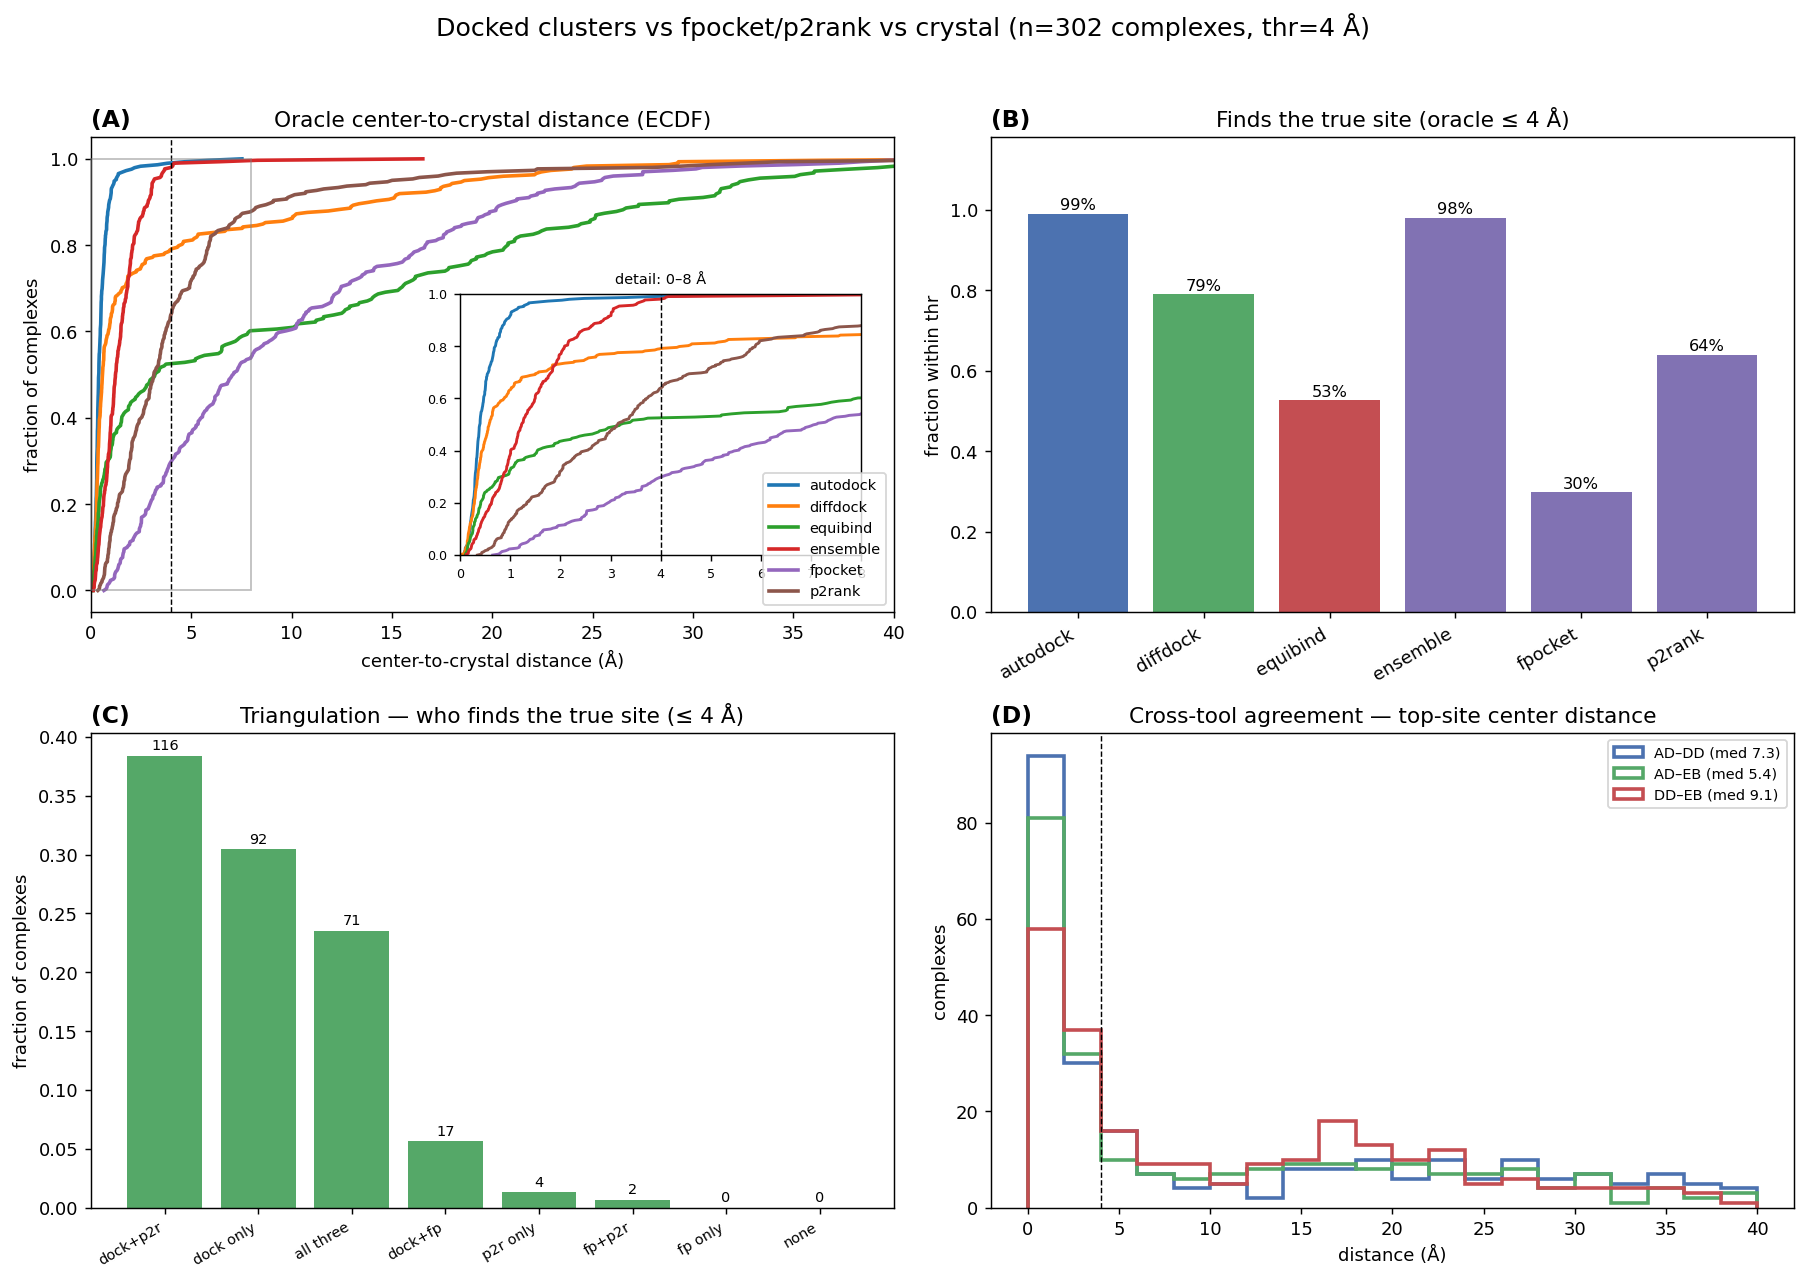

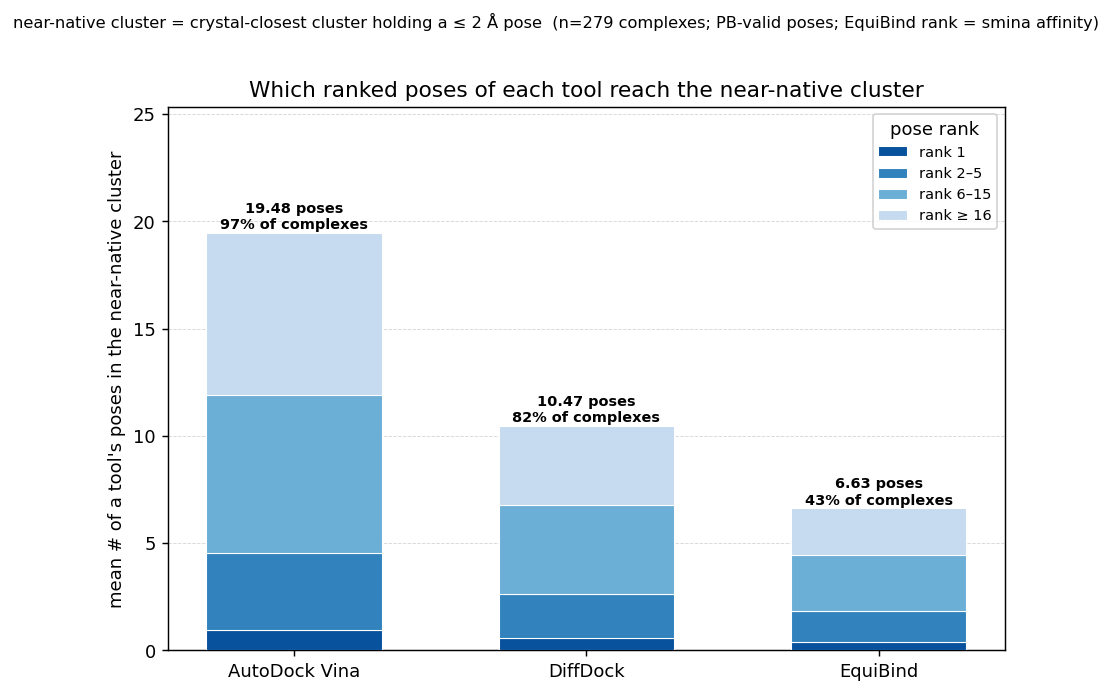

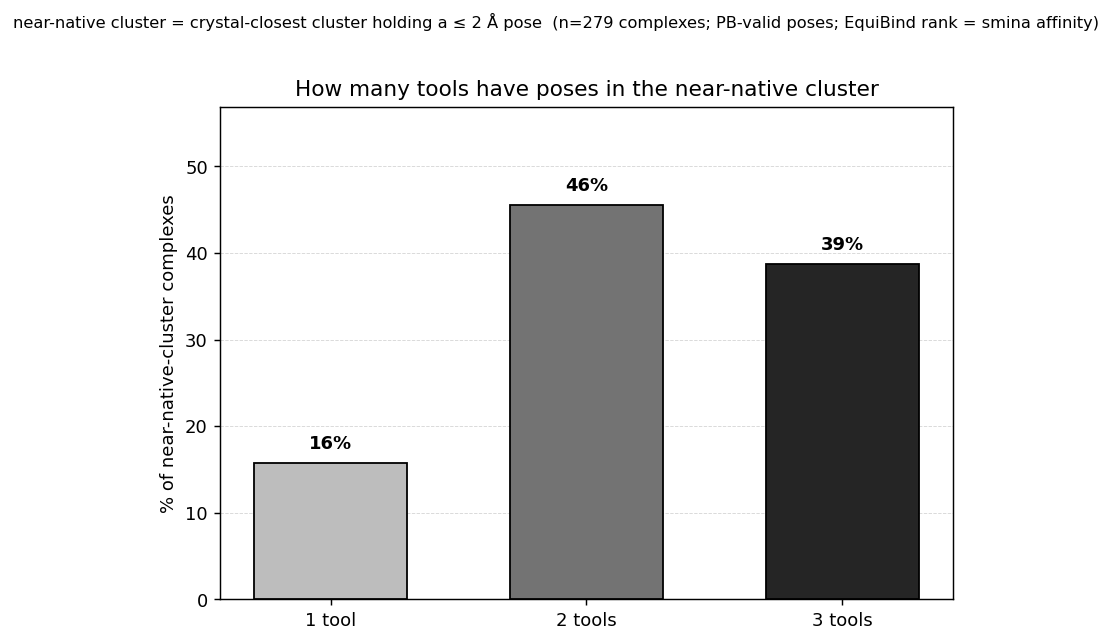

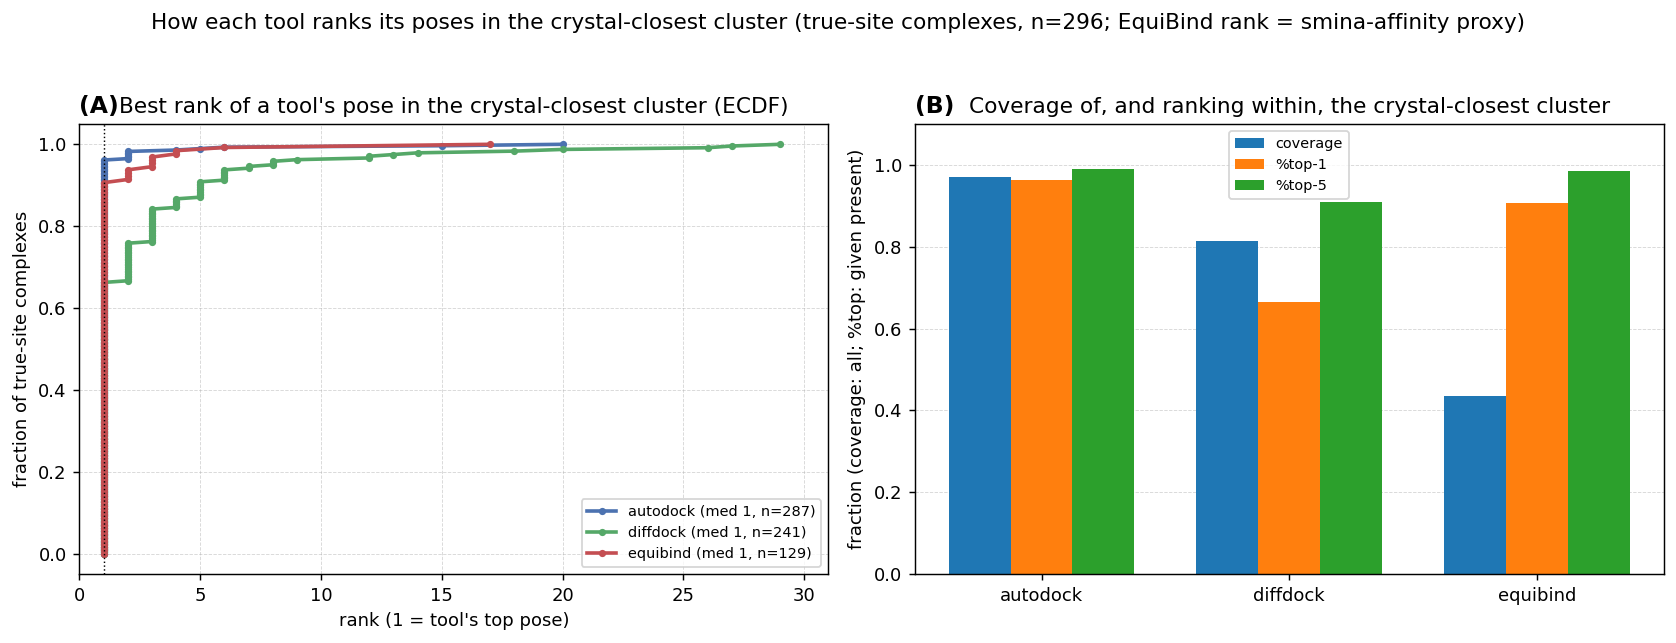

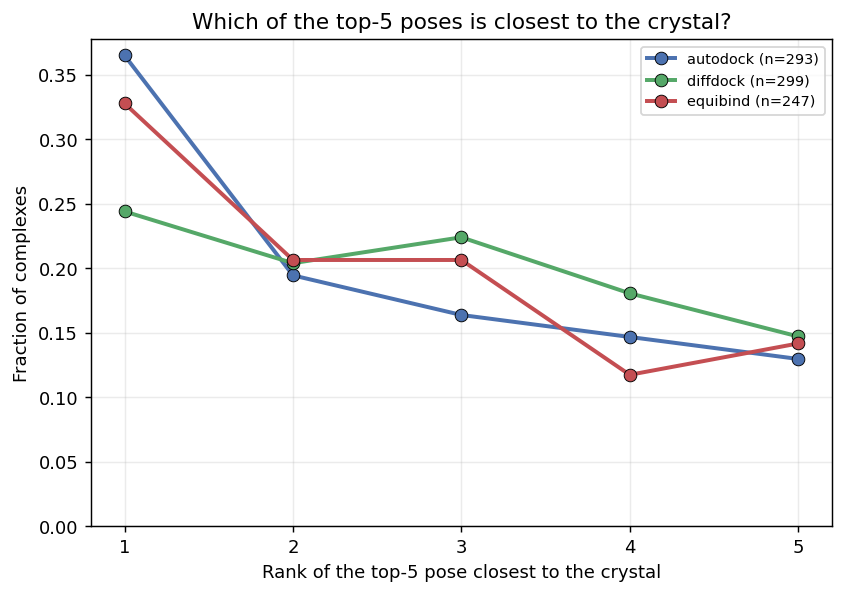

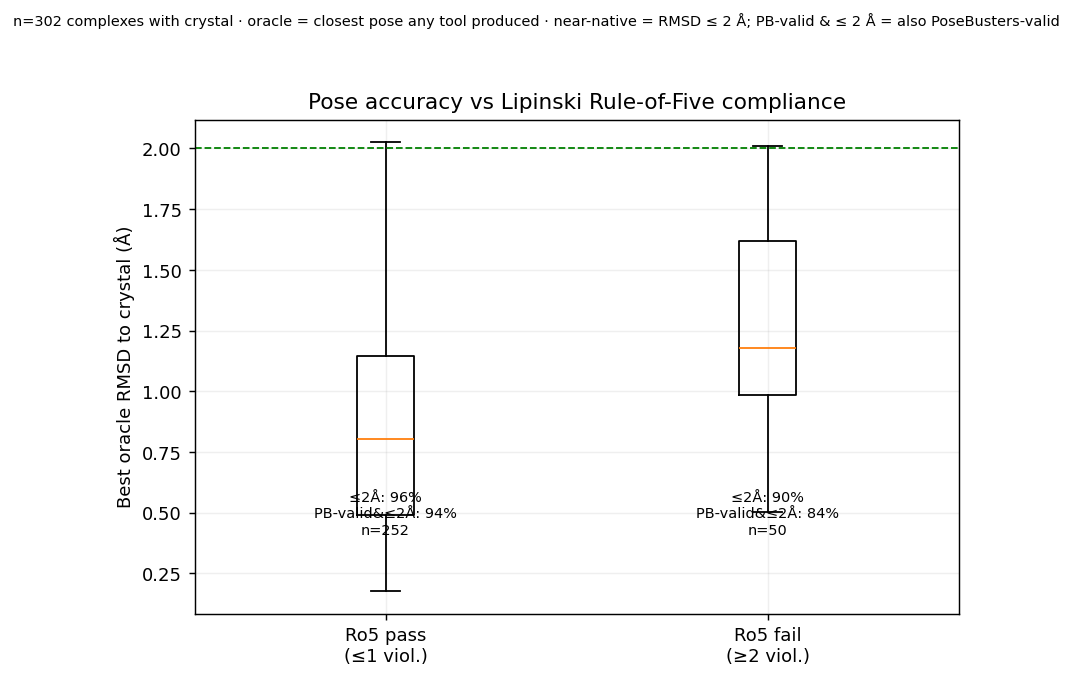

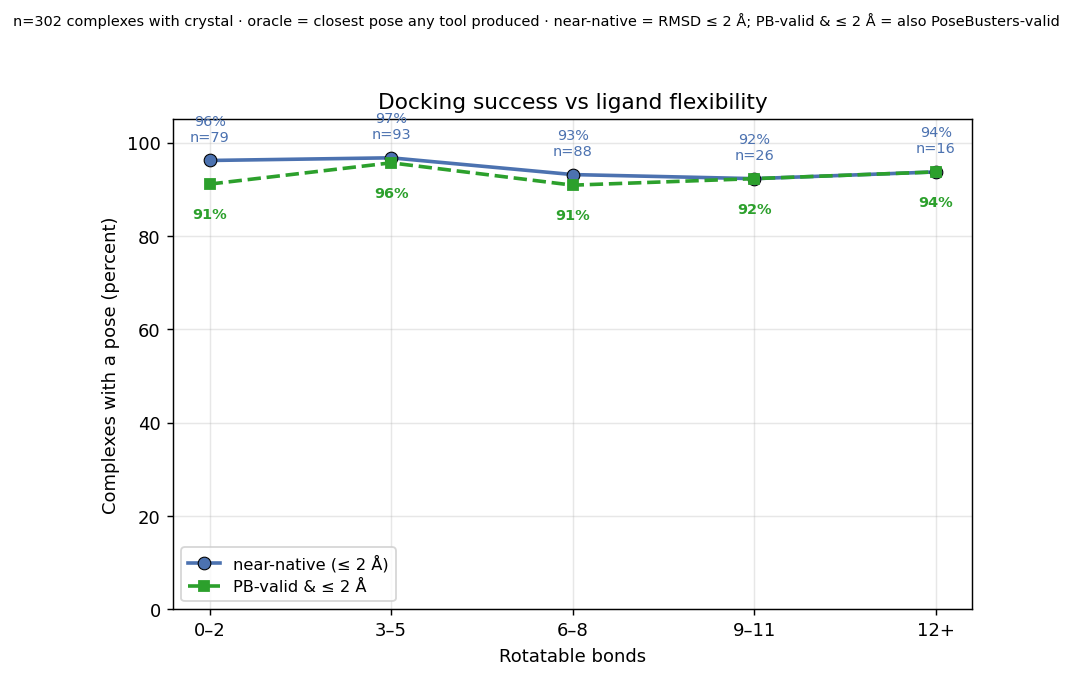

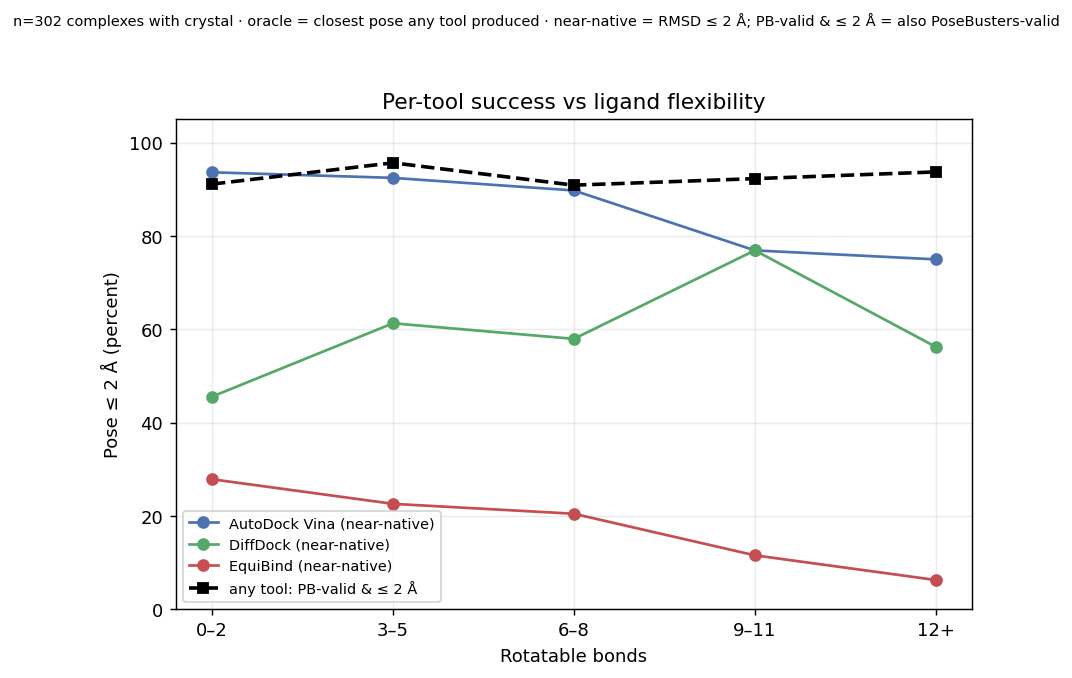

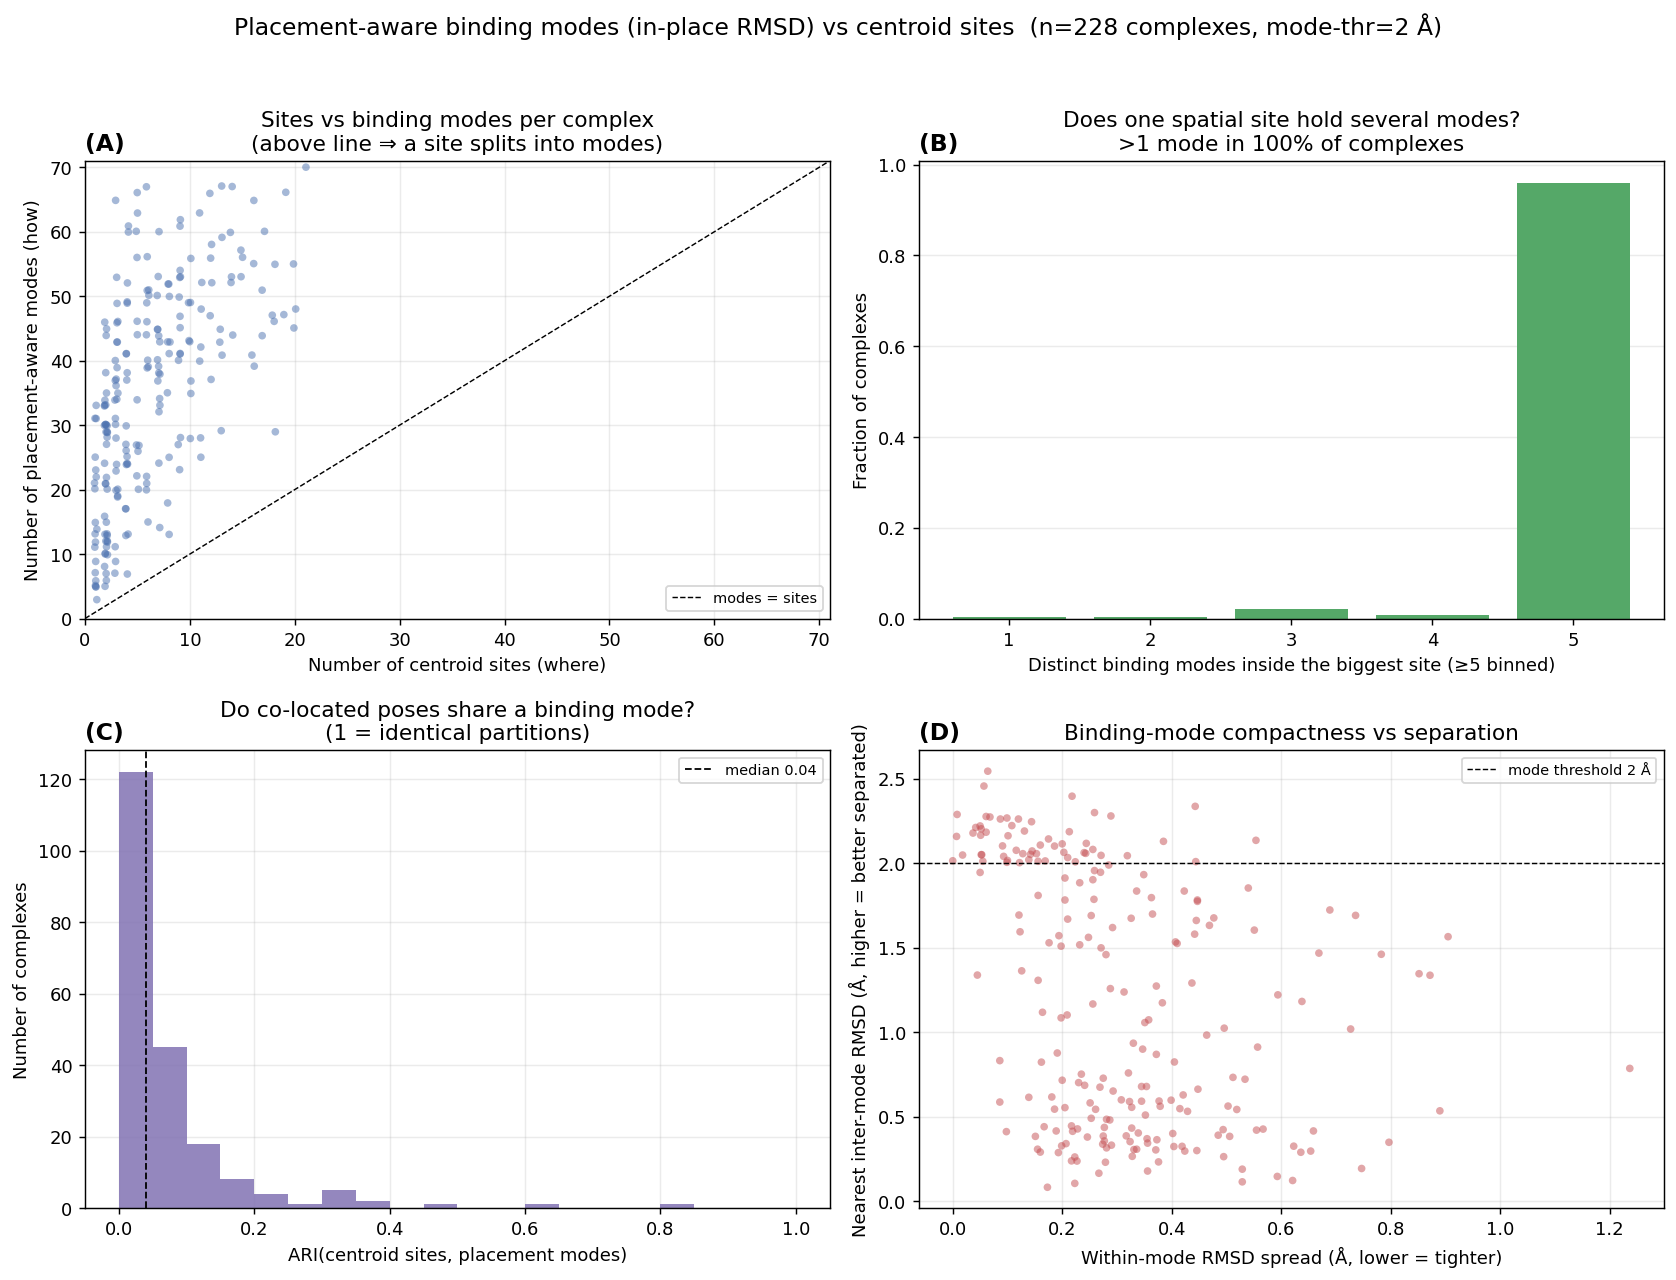

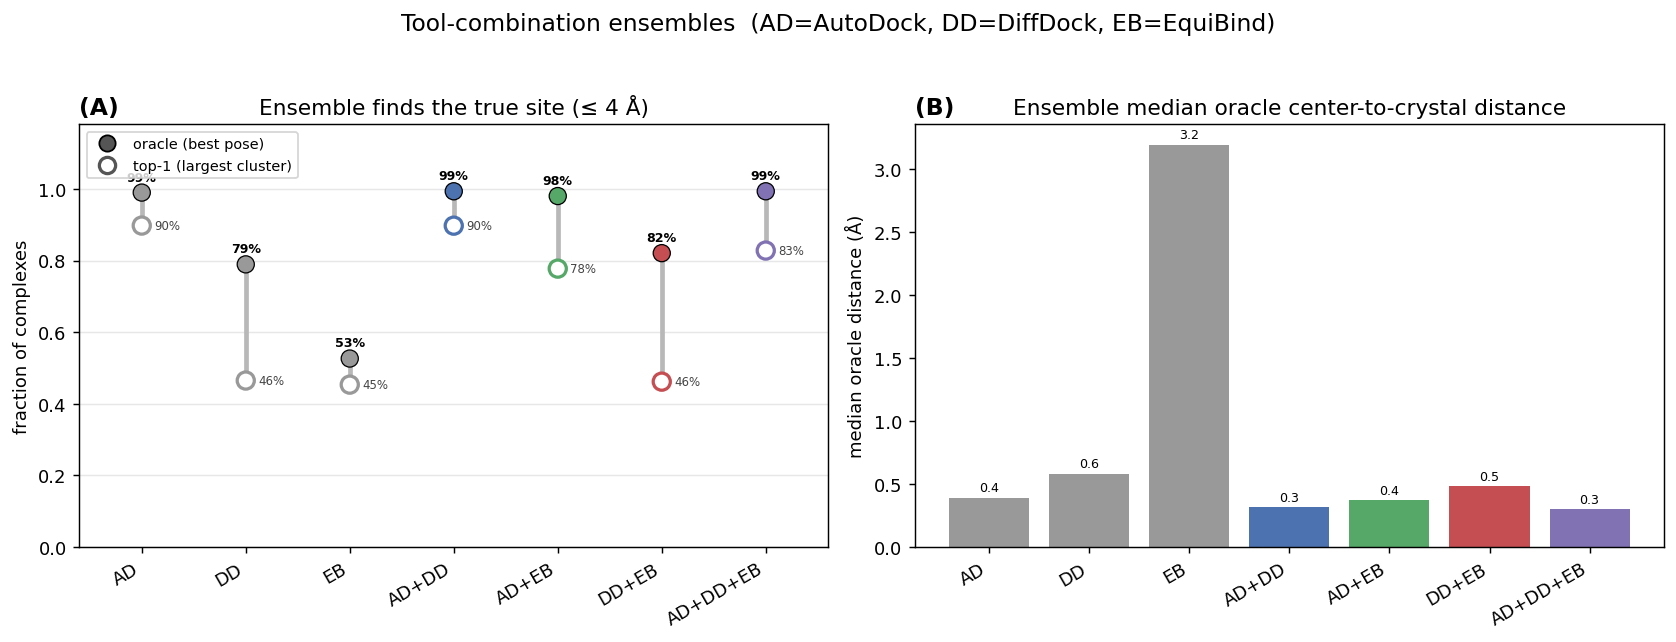

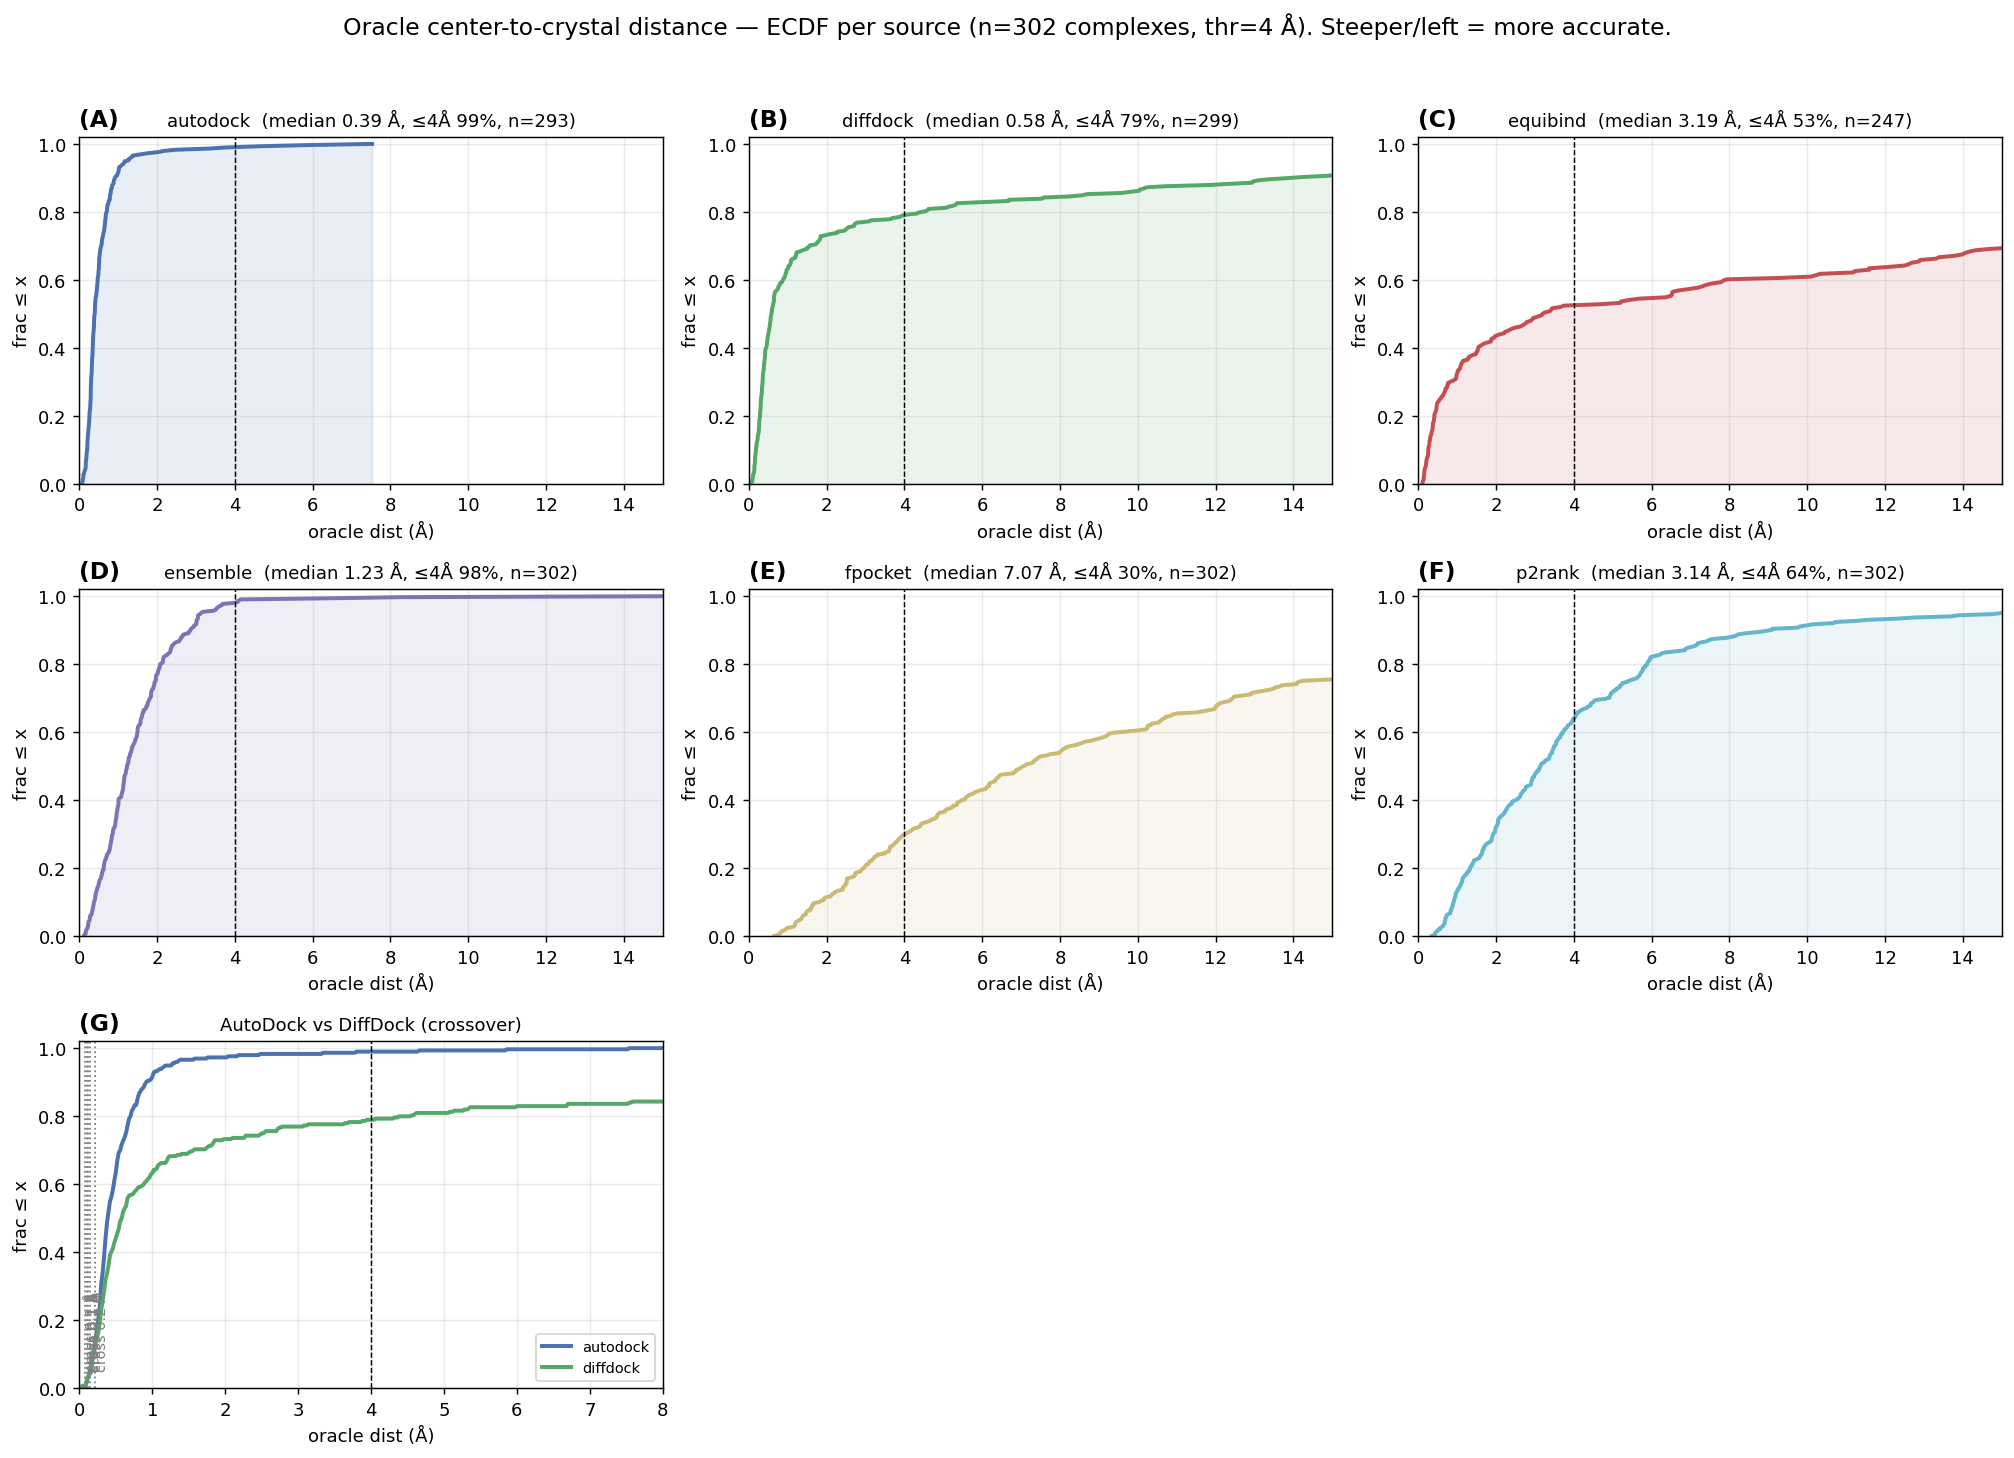

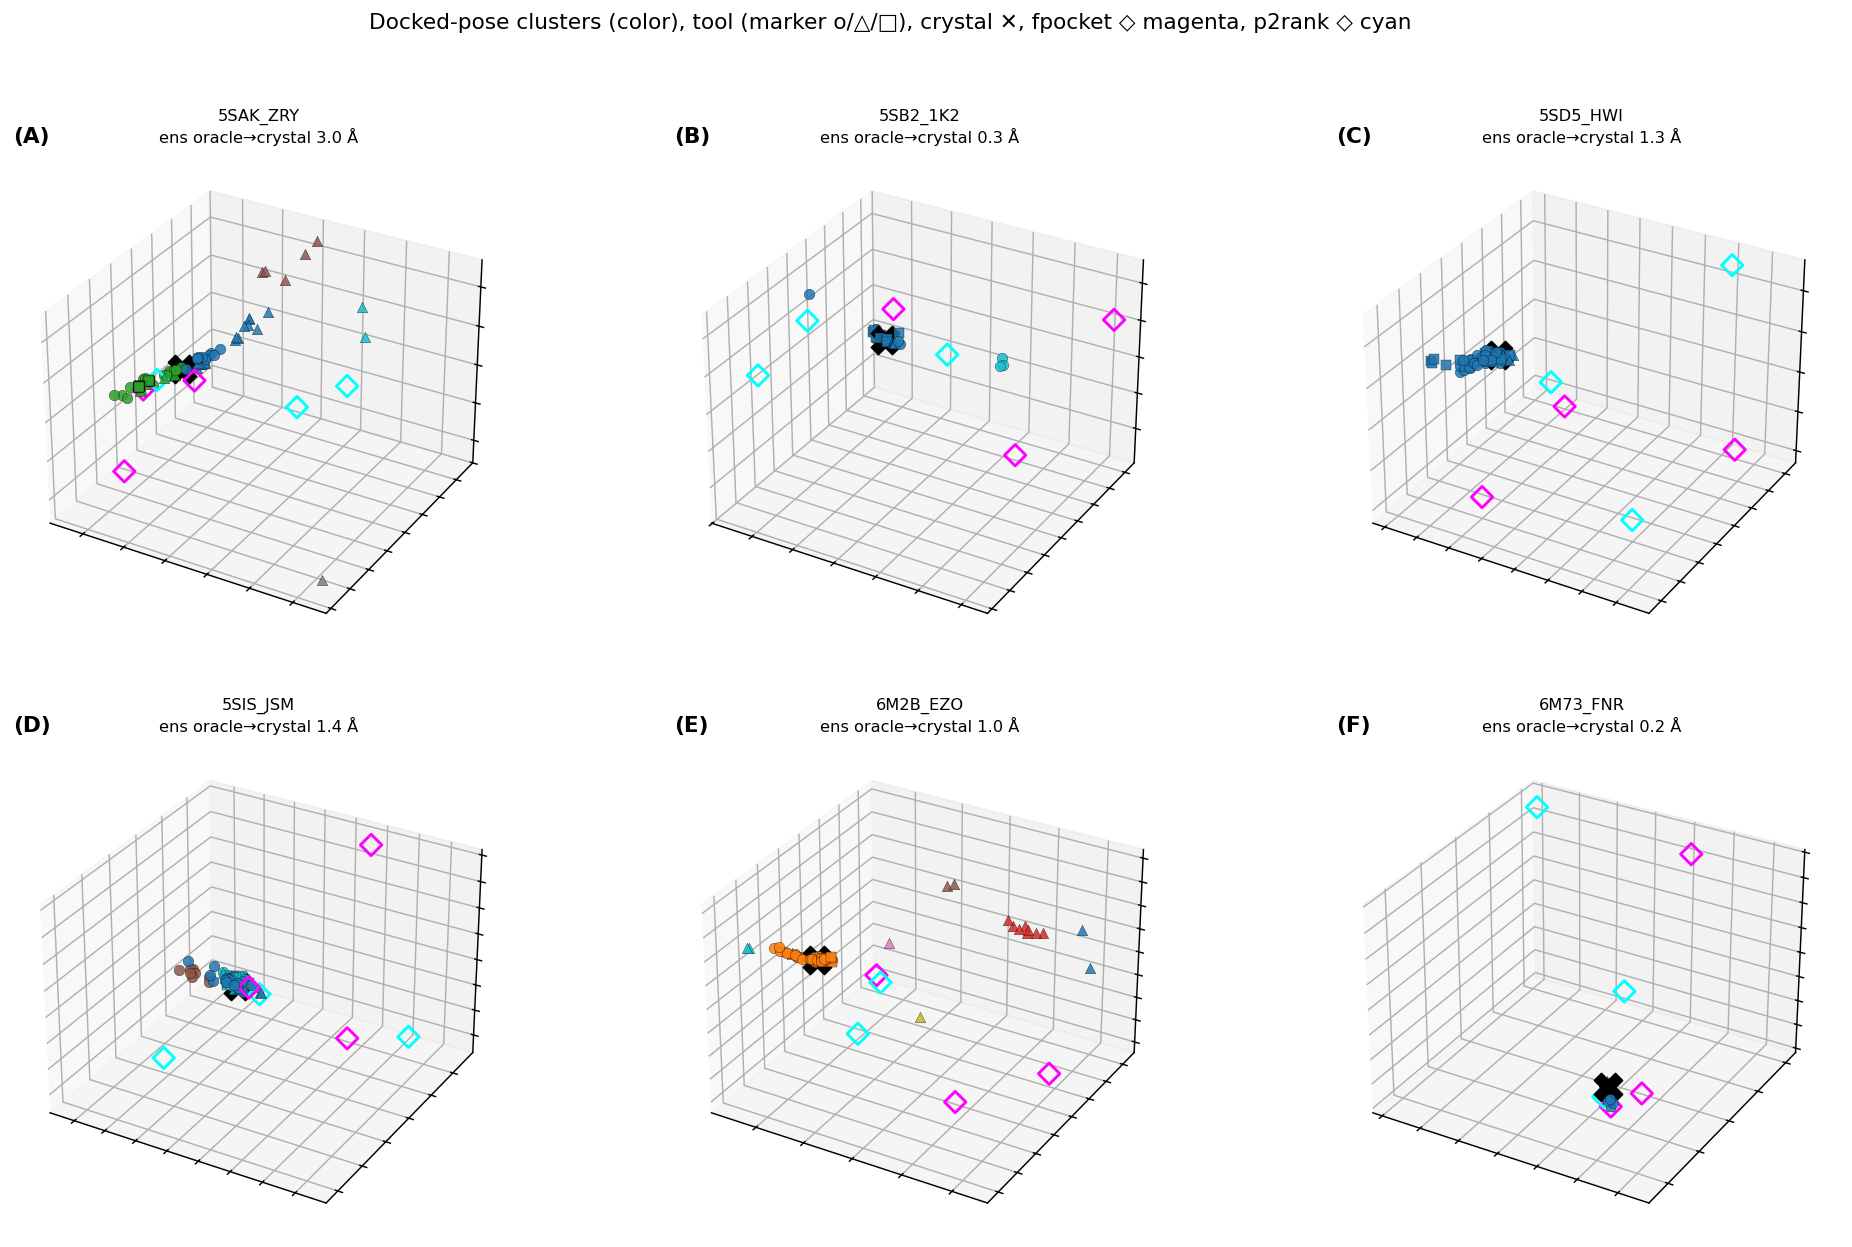

In [ ]:
import subprocess, json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

VINA_PY  = "/home/manndo/anaconda3/envs/vina/bin/python"   # scipy/sklearn/matplotlib live in the vina env
IDS_FILE = "Data/PoseBuster Benchmark Set/posebusters_pdb_ccd_ids.txt"  # 308 official benchmark receptors
# Per-pose metrics from the benchmark docking (AutoDock + DiffDock + EquiBind),
# produced by the PoseBusters pose-comparison step (posebusters_pose_comparison.py).
BENCH_POSES = "posebusters_results/benchmark/dock/pose_comparison_report/per_pose_metrics.csv"

# New execution (overhauled clustering): primary partition is a k=1-capable
# distance-threshold cut (a single blob is no longer force-split into >=2 sites),
# pockets are ranked by cross-tool CONSENSUS (not raw pose count), and each run
# emits new quality metrics: internal indices (CH / Davies-Bouldin / compactness /
# separation), bootstrap stability, crystal-closest-cluster purity, and a
# precision@1 ablation across ranking rules (-> ranking_ablation.csv). It also
# runs a PLACEMENT-AWARE binding-mode analysis (in-place RMSD: translation +
# orientation + conformation) ALONGSIDE the centroid sites, so "where" (site)
# and "how" (mode) are separate axes (-> placement_vs_centroid.png).
# Legacy behaviour: --site-cluster silhouette --rank-by size.

CLUSTER_OPTS = ["--site-cluster", "threshold", "--pocket-radius", "8.0",
                "--rank-by", "consensus", "--stability-boot", "25",
                "--workers", "30", "--pb-valid-only", "--stats",
                "--equibind-variant", "equibind_unguided_gnina"]
                # "--force"]  # force re-run even if the out-dir exists (otherwise skips)


if not Path(BENCH_POSES).exists():
    print(f"per-pose metrics not found: {BENCH_POSES}\n"
          "  Generate it first with the PoseBusters pose-comparison cell "
          "(posebusters_pose_comparison.py).")

# pose_cluster analyses ONE DiffDock variant per run (like the EquiBind variant
# selector), so cluster each smina/gnina-optimised variant separately from raw
# DiffDock - each writes its own report dir so the variants stay distinguishable.
# DIFFDOCK_VARIANTS = ["diffdock", "diffdock_smina", "diffdock_gnina"]
DIFFDOCK_VARIANTS = ["diffdock_gnina"]
rows = []
for dd in DIFFDOCK_VARIANTS:
    out_dir = f"posebusters_results/cluster_crystal_pocket/{dd}_pbvalid"
    cmd = ["Scripts/Analysis/pose_cluster_crystal_pocket_report.py",
           "--ids-file", IDS_FILE, "--per-pose-csv", BENCH_POSES,
           "--diffdock-variant", dd, "--out-dir", out_dir, *CLUSTER_OPTS]
    print(f"=== {Path(cmd[0]).name}  (diffdock-variant={dd}) ===")
    proc = subprocess.run([VINA_PY, *cmd])
    if proc.returncode != 0:
        print(f"WARN {cmd[0]} ({dd}) exited with code {proc.returncode} - continuing notebook.")
        continue
    sj = Path(out_dir) / "summary.json"
    if sj.exists():
        s = json.loads(sj.read_text())
        cl = s.get("clustering", {})
        abl = {a["rule"]: a["precision_at_1"] for a in s.get("ranking_ablation", [])}
        pur = s.get("crystal_closest_cluster_purity", {}) or {}
        pm = s.get("placement_modes", {}) or {}
        rows.append({
            "variant": dd,
            "mean_sites": cl.get("mean_n_clusters"),
            "single_site_frac": cl.get("frac_single_site"),
            "silhouette": cl.get("mean_silhouette"),
            "davies_bouldin": cl.get("mean_davies_bouldin"),
            "boot_stability": cl.get("mean_bootstrap_stability"),
            "p@1_size": abl.get("size"),
            "p@1_consensus": abl.get("ntools"),
            "p@1_oracle": abl.get("oracle"),
            "ranking_rho": s.get("ranking_enrichment_spearman"),
            "purity_centroid": pur.get("mean_purity_centroid"),
            "n_modes": pm.get("mean_n_modes"),
            "multimode_site_frac": pm.get("frac_top_site_multimode"),
            "ari_site_mode": pm.get("mean_ari_site_vs_mode"),
        })

# ── new-metrics comparison across the three DiffDock variants ─────────────
if rows:
    summary = pd.DataFrame(rows).set_index("variant")
    print("\nClustering quality + precision@1 across DiffDock variants "
          "(p@1 = rank-1 pocket within match-thr of crystal; consensus vs size ranking):")
    display(summary.round(3))

# ── ranking-rule ablation table + key figures for the primary (raw DiffDock) run ──
primary = Path("posebusters_results/cluster_crystal_pocket/diffdock_gnina_pbvalid")
abl_csv = primary / "ranking_ablation.csv"
if abl_csv.exists():
    print("\nRanking-rule ablation (gnina DiffDock) - does a better ranking recover the true site?")
    display(pd.read_csv(abl_csv))
for png in ("crystal_pocket_summary.png", "cluster_quality_metrics.png",
            "near_native_cluster_rank_composition.png", "near_native_cluster_consensus.png",
            "rank_in_correct_cluster.png", "top5_best_rank.png",
            "descriptor_accuracy_vs_ro5.png", "descriptor_success_vs_flexibility.png",
            "descriptor_per_tool_success_vs_flexibility.png",
            "placement_vs_centroid.png", "ensemble_exploration.png",
            "oracle_ecdf_split.png", "example_3d_clusters.png"):
    p = primary / png
    if p.exists():
        display(Image(filename=str(p)))

## Pandamaps

In [ ]:
# NOTE: --best-diffdock-only maps only the best DiffDock optimizer variant
# ('DiffDock*', like --best-equibind-only); drop it to keep all three.
# Pass the benchmark-set restriction (cell "Restrict subsequent analysis…")
# through to the script: when RESTRICT_TO_BENCHMARK_SET is on, add --ids-file so
# the script independently limits its pairs to the official list (works even if
# the PoseBusters CSV still holds extra pairs). Off / cell not run → no filter.
_ids_file = globals().get(
    "benchmark_ids_file",
    "Data/PoseBuster Benchmark Set/posebusters_benchmark_set_ids.txt")
_ids = f' --ids-file "{_ids_file}"' if globals().get("RESTRICT_TO_BENCHMARK_SET") else ""

get_ipython().run_line_magic(
    "run",
    "Scripts/Analysis/run_pandamap.py"
    " --config Scripts/Analysis/pandamap_config.yaml"
    " --best-equibind-only"
    " --diffdock-variant gnina"
    + _ids)


PandaMap interaction generator
  input   : PB CSV /home/manndo/master_dev/posebusters_results/benchmark/dock/posebusters_filtered_results.csv
  output  : /home/manndo/master_dev/pandamap_results/benchmark_best_equi
  top-N   : 5 per method×pair   pb_valid_only=True
  crystal : /home/manndo/master_dev/Data/PoseBuster Benchmark Set
Collected 41051 poses; methods: ['autodock', 'diffdock', 'diffdock_gnina', 'diffdock_smina', 'equibind_fpocket_gnina', 'equibind_fpocket_raw', 'equibind_fpocket_smina', 'equibind_p2rank_gnina', 'equibind_p2rank_raw', 'equibind_p2rank_smina', 'equibind_unguided_gnina', 'equibind_unguided_raw', 'equibind_unguided_smina']
best-equibind-only: keeping 'equibind_unguided_gnina' (top EquiBind by PB-Valid AND RMSD ≤ 2 Å); 41051 → 28106 poses. Run the report with --best-equibind-only to label it 'EquiBind*'.
best-diffdock-only: keeping 'diffdock_smina' (top DiffDock by PB-Valid AND RMSD ≤ 2 Å); 28106 → 18562 poses. Run the report with --best-diffdock-only to label it '

In [ ]:
import subprocess

VINA_PY = "/home/manndo/anaconda3/envs/vina/bin/python"  # pandamap lives only in the vina env

# Restrict to the official benchmark-set ids when the "Restrict subsequent
# analysis…" cell is active (RESTRICT_TO_BENCHMARK_SET); off / not run → no filter.
_ids_file = globals().get(
    "benchmark_ids_file",
    "Data/PoseBuster Benchmark Set/posebusters_benchmark_set_ids.txt")
_ids_arg = ["--ids-file", str(_ids_file)] if globals().get("RESTRICT_TO_BENCHMARK_SET") else []

# Config-driven: --in-dir is taken from the config's output_dir (benchmark_best_equi),
# and --best-equibind-only relabels the retained variant as "EquiBind*" in every chart.
try:
    proc = subprocess.run([
        VINA_PY, "Scripts/Analysis/pandamap_interaction_report.py",
        "--config", "Scripts/Analysis/pandamap_config.yaml",
        "--best-equibind-only",
        "--diffdock-variant", "gnina",
    ] + _ids_arg)
    if proc.returncode != 0:
        print(f"⚠ pandamap report exited with code {proc.returncode} — continuing notebook.")
except Exception as e:
    print(f"⚠ pandamap report could not run ({e}) — continuing notebook.")

best-equibind-only: 'equibind_unguided_gnina' is the top EquiBind variant by PB-Valid AND RMSD ≤ 2 Å — keeping only it (shown as 'EquiBind*').
best-diffdock-only: 'diffdock_smina' is the top DiffDock variant by PB-Valid AND RMSD ≤ 2 Å — keeping only it (shown as 'DiffDock*').
Loaded 4058 poses, 127447 interaction rows, 10971 crystal rows. Methods: ['autodock', 'diffdock_smina', 'equibind_unguided_gnina']

Native-interaction recovery (mean per method):
                         precision  recall     f1  jaccard_vs_crystal
method                                                               
autodock                     0.800   0.792  0.793               0.680
diffdock_smina               0.507   0.483  0.490               0.425
equibind_unguided_gnina      0.482   0.416  0.440               0.354
  RMSD-vs-recovery: joined 4057 poses (autodock=1430, diffdock_smina=1466, equibind_unguided_gnina=1161).

Report written to: /home/manndo/master_dev/pandamap_results/benchmark_best_equi/report


## Benchmark docking — computational effort comparison

Compares how expensive it is to dock the **PoseBusters benchmark set** (cognate
re-docking, ~303 receptor–ligand pairs) with the three docking methods —
**AutoDock Vina**, **DiffDock**, and **EquiBind (best configuration: unguided +
smina-refined)** — via `Scripts/Analysis/docking_effort_comparison.py`. It reuses
the timing each tool already wrote per complex plus the per-pose PoseBusters
verdicts; **nothing is re-docked**.

### Two cost metrics — and why we need both

**1. Wall-clock time (time-to-result).** How long you actually wait for a complex
to finish. It is the intuitive cost and is comparable across tools as *elapsed
time*, but it hides two things: (i) **parallelism** — a tool that spreads work over
32 CPU cores finishes sooner without doing less work; and (ii) **hardware** —
AutoDock runs on CPU while DiffDock/EquiBind run on a GPU, so equal wall-clock does
*not* mean equal cost.

**2. Resource-seconds (hardware work).** The actual compute consumed, with
parallelism removed, split by the hardware that did it:
- **CPU-core-seconds** — serial-equivalent CPU work (`wall × threads`, or the sum of
  per-pose CPU times). Eight cores busy for 10 s = 80 CPU-core-seconds.
- **GPU-seconds** — wall-time a GPU was occupied.

These are **different currencies** — a GPU-second is *not* interchangeable with a
CPU-core-second — so they are always shown **side by side and never summed**.

> *Why this matters here:* EquiBind has the **shortest wall-clock**, which makes it
> look cheap — but only because it fans its UFF/smina post-processing across many
> CPU cores. In resource terms it is actually the **heaviest CPU consumer**, and its
> GPU use is negligible. The wall-clock view hides that entirely; the resource view
> exposes it.

### Per-pose normalisation: generated vs. PoseBusters-valid

Total cost alone is unfair because the methods generate different numbers of poses
at very different quality, so both metrics are also divided by:
- **poses generated** — raw throughput cost; and
- **poses that survive the PoseBusters tests** (`pb_valid`) — cost per *usable*
  pose. This is the metric that matters: a tool that emits many physically invalid
  poses (clashes, broken geometry) is wasting effort, and dividing by the valid
  count exposes it. AutoDock's ~91 % validity vs DiffDock/EquiBind's ~23 % makes its
  cost-per-valid-pose far lower than its cost-per-generated-pose alone would suggest.

### EquiBind "best configuration"

The benchmark EquiBind run produced the full clamp × refine × pocket fan-out, but
only the **unguided + smina-refined** variant is competitive on PoseBusters
validity. So we count only that variant's poses, sum only those poses' per-pose
resource-seconds, and attribute EquiBind's wall-clock to it by the fraction of
per-pose compute time it represents (the full-run wall is kept in the CSV).

### Data sources & hardware

| Method | Per-complex timing source | Device |
|---|---|---|
| AutoDock Vina | `Dockings/Benchmark/<id>/meeko/docking_summary.json` → `total_time_seconds` | CPU, 32 threads |
| DiffDock | `Dockings/Benchmark_DiffDock/<id>/docking_summary.json` → `total_time_seconds` | single GPU |
| EquiBind | `Dockings/Benchmark_Equibind/<id>/pipeline_summary.json` → wall + per-pose `{prep,dock,post,refine}_time_s` | GPU (inference) + CPU (UFF/smina) |

CPU-core-seconds: AutoDock = `wall × 32`; EquiBind = Σ per-pose `(prep+post+refine)`.
GPU-seconds: DiffDock = wall; EquiBind = Σ per-pose `dock`. DiffDock is GPU-bound (its
CPU preprocessing is not separately recorded).

**Outputs** → `posebusters_results/benchmark/docking_effort/`: two figures
(`docking_effort_comparison.png` = wall-clock; `docking_resource_effort.png` =
CPU-core-seconds vs GPU-seconds) plus `effort_summary.csv` and `per_complex_effort.csv`.
Runs in the `vina` env (pandas + matplotlib).


DOCKING COMPUTATIONAL EFFORT — benchmark set (EquiBind best config: unguided+gnina)
Compared on the COMMON set of 239 complexes timed for all methods (dropped to reach it — autodock 54, diffdock 9, equibind 63).
WALL-CLOCK (time-to-result):
  method                         dev  cplx  total h      gen   valid  valid%   s/gen  s/valid
  AutoDock Vina                  CPU   239     0.66    5,821   5,269   90.5%    0.41     0.45
  DiffDock (gnina)               GPU   239    21.17    7,101   5,840   82.2%   10.73    13.05
  EquiBind (unguided+gnina)  GPU+CPU   239     1.71    7,170   4,015   56.0%    0.86     1.53

HARDWARE EFFORT (resource-seconds; CPU-core-s and GPU-s are different currencies):
  method                      CPU core-h    GPU-h  CPUs/valid  GPUs/valid
  AutoDock Vina                    21.13     0.00       14.43        0.00
  DiffDock (gnina)                  0.00    21.17        0.00       13.05
  EquiBind (unguided+gnina)         0.83    53.81        0.74       48.25

 

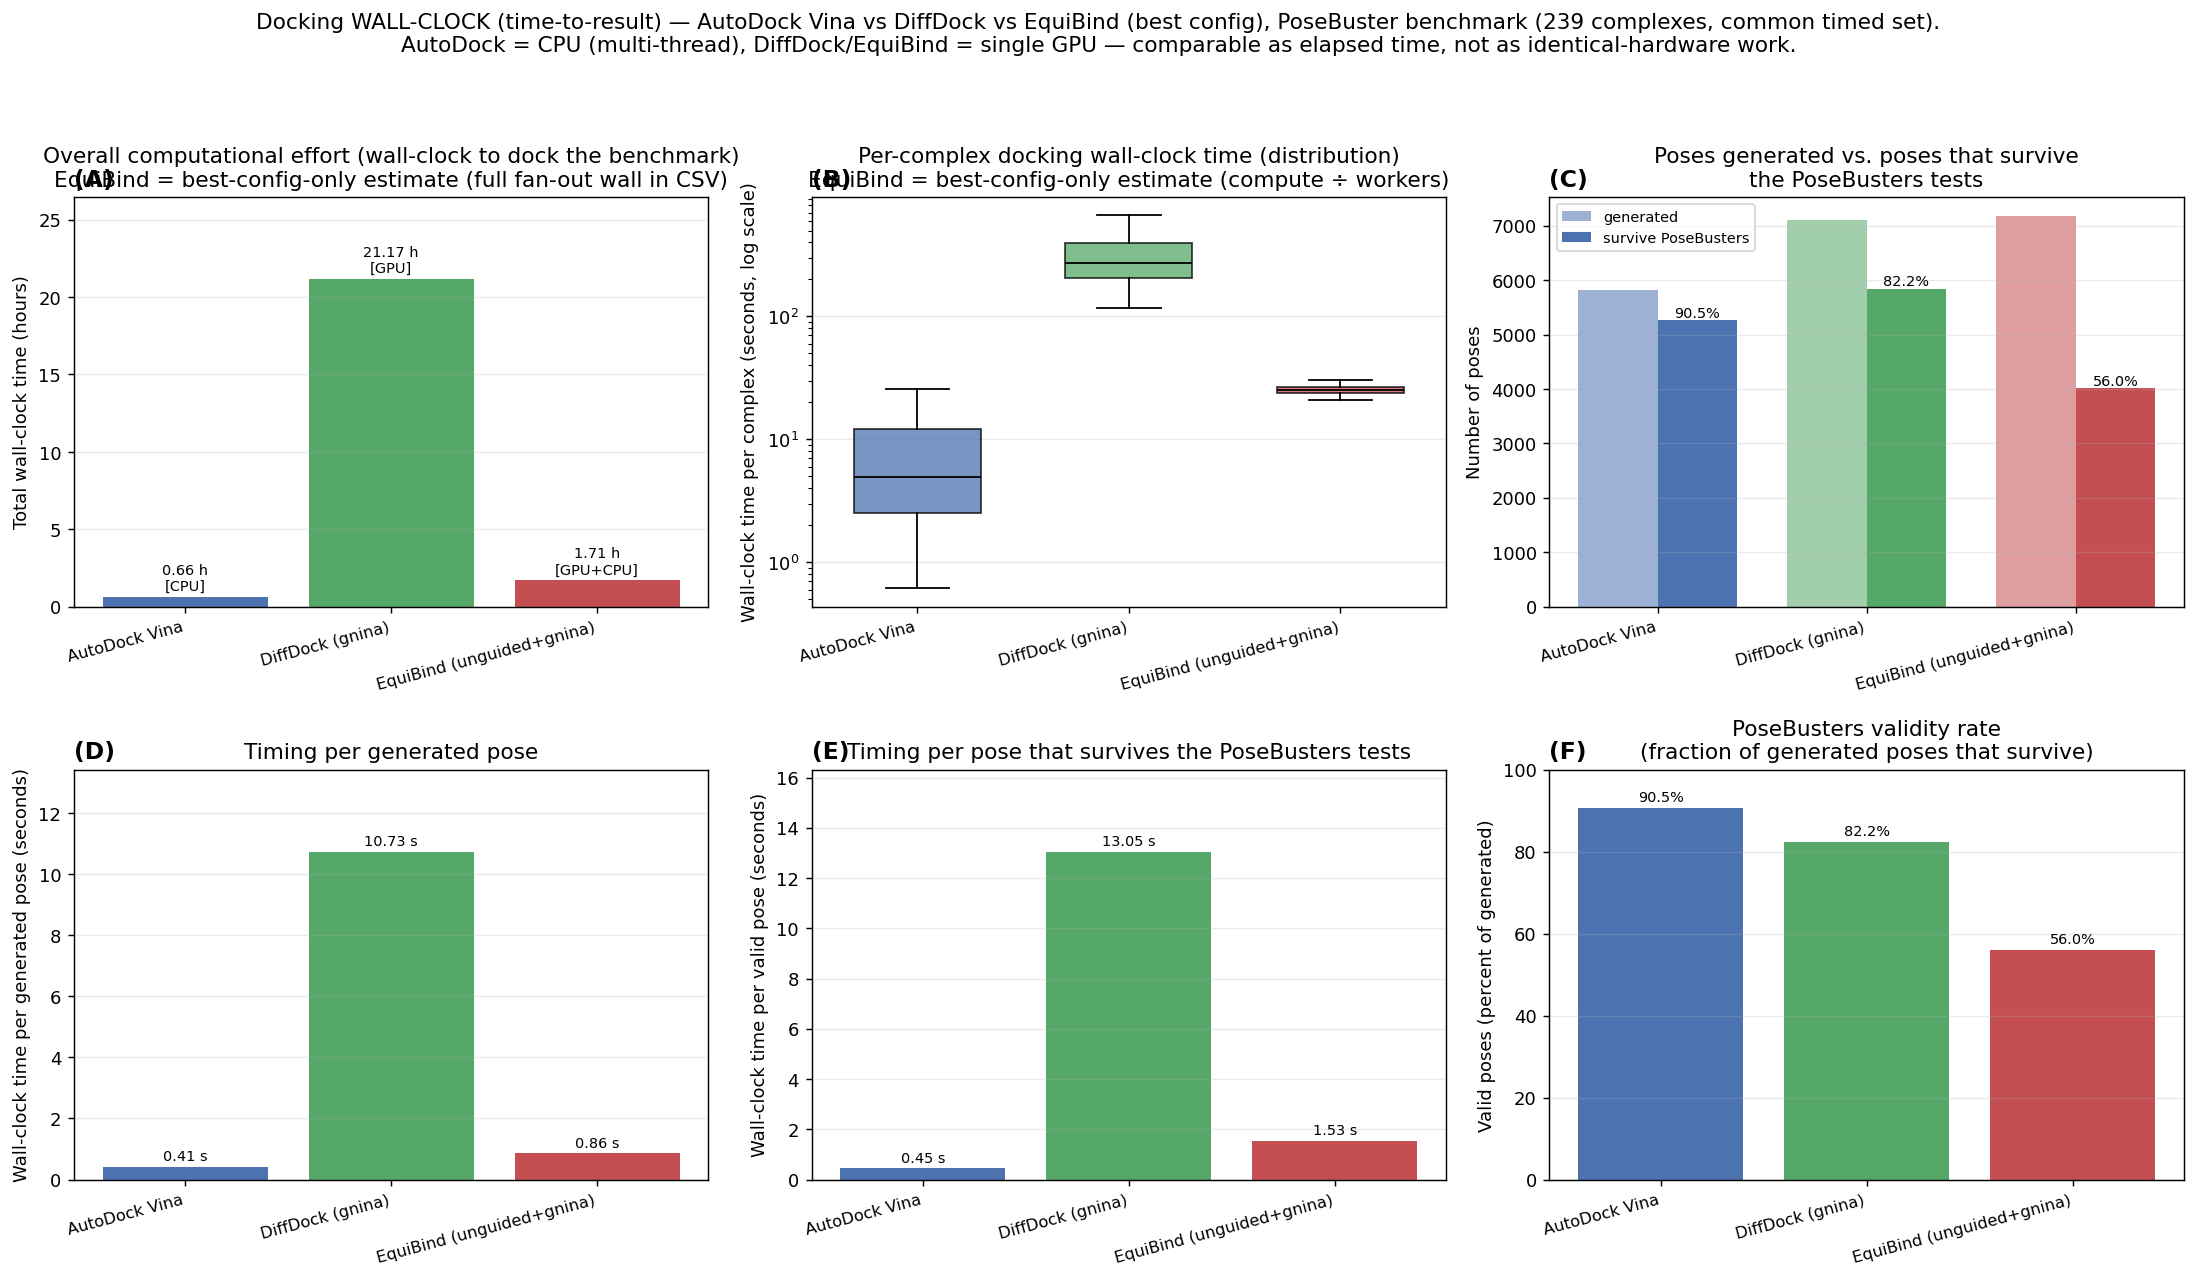

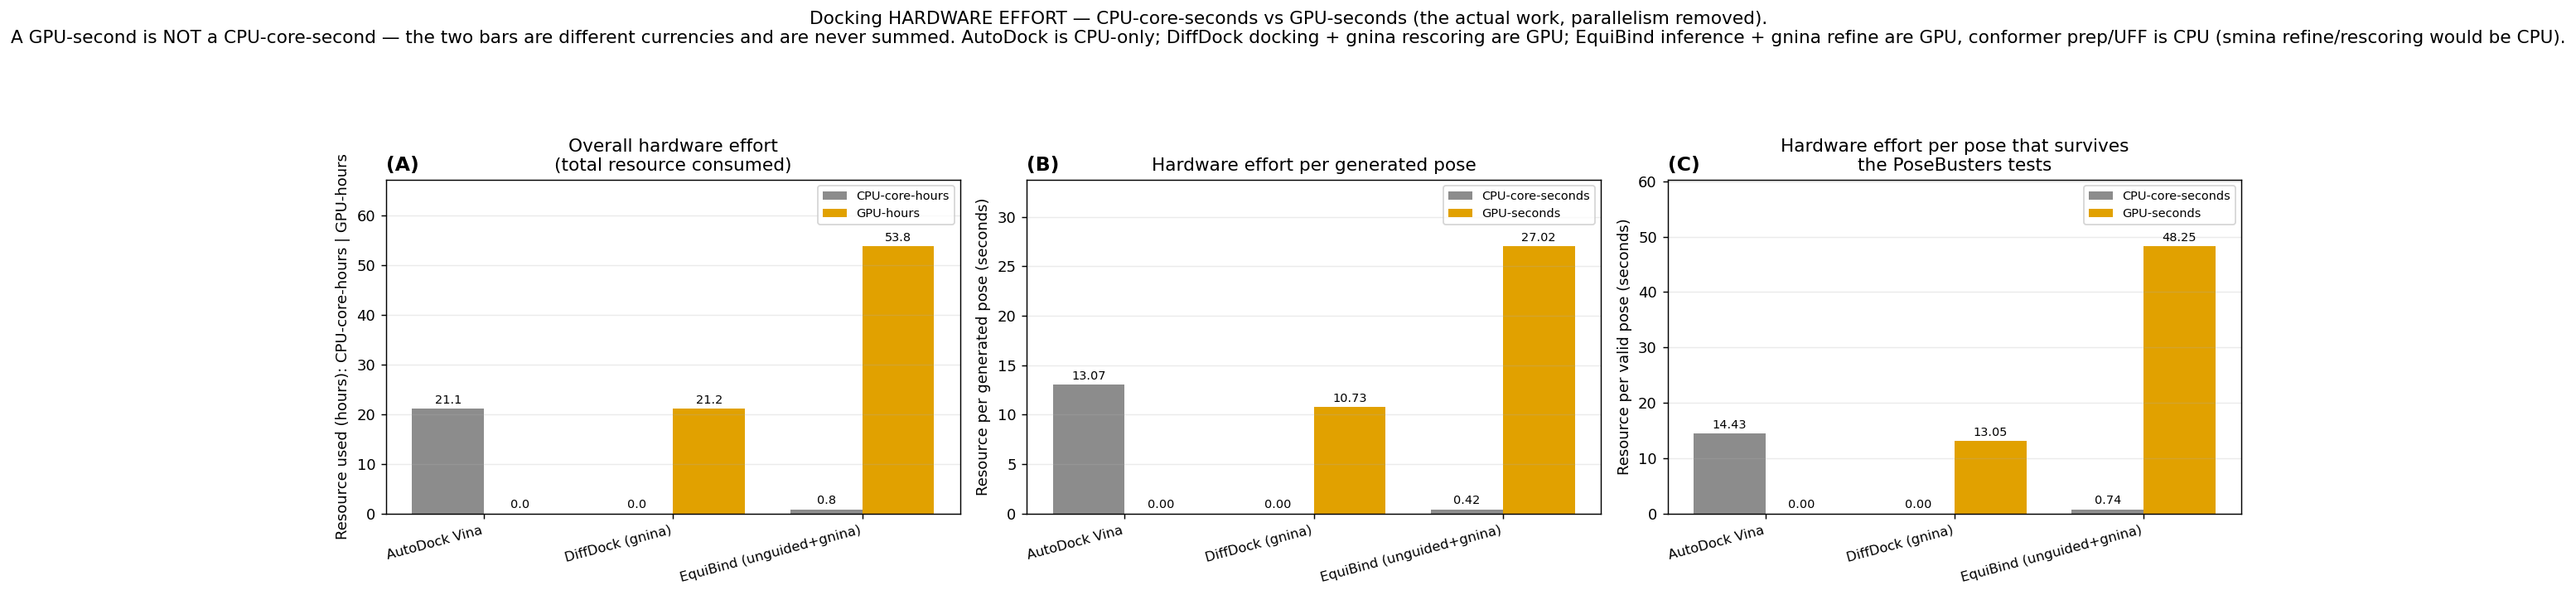

In [ ]:
import subprocess
from pathlib import Path
from IPython.display import Image, display

VINA_PY = "/home/manndo/anaconda3/envs/vina/bin/python"  # pandas/matplotlib live in the vina env

proc = subprocess.run([VINA_PY, "Scripts/Analysis/docking_effort_comparison.py"])
if proc.returncode != 0:
    print(f"\u26a0 docking_effort_comparison.py exited with code {proc.returncode}")

# Show both figures inline: wall-clock (time-to-result) and hardware effort (CPU vs GPU).
out = Path("posebusters_results/benchmark/docking_effort")
for png in ("docking_effort_comparison.png", "docking_resource_effort.png"):
    p = out / png
    if p.exists():
        display(Image(filename=str(p)))

## Benchmark vs Orai — receptor comparison

Quantifies **how atypical the Orai cross-docking target is** relative to the 308
PoseBusters benchmark receptors, via `Scripts/Analysis/receptor_comparison_report.py`.
The benchmark receptors are diverse, mostly-soluble *cognate* drug targets; Orai is
four MD snapshots of one hexameric Ca²⁺ channel that is *non-cognate* to every
benchmark ligand. Only axes comparable across unrelated proteins are used:

- **Size / composition** — heavy-atom count, oligomeric state (chains), residue count.
  *(Fold and sequence are not comparable and are not shown.)*
- **Pocket properties** — fpocket + p2rank pockets (already computed for both):
  pocket count, top/maximum volume, top/maximum druggability, best pocket scores.

**Two data subtleties handled in the script:**
1. The Orai PDBs encode the six subunits in the **segid** column (MONA–MONF), not the
   chain column (all `M`); the dataset notebook's `protein_features` keys residues on
   `(chain, resnum)` and so mis-counts Orai as 1 chain / 223 residues. The script
   counts subunits from chain-id **or** segid **or** residue-number resets → the
   correct **6 chains / 1338 residues**. Orai descriptors are taken from the originals
   in `Data/Receptors/Original`.
2. Benchmark PDBs carry **no hydrogens**, so total-atom counts are confounded — the
   size comparison uses **heavy atoms** only.

**Key findings** (see figures): Orai sits at the **large, oligomeric extreme** of the
benchmark (heavy atoms ~93rd, residues ~93rd, chains ~97th percentile). Its pocket
profile is the real outlier: the **top-ranked fpocket pocket is the huge central pore
(~22,000 Å³, 100th-percentile volume) with druggability 0.0**, even though a smaller
**druggable side pocket does exist** (best druggability ≈ 0.98). That mismatch — the
dominant cavity is an undruggable channel pore, not a classic ligand site — is a
structural explanation for why blind/guided cross-docking into Orai scatters and gives
low PoseBusters validity (the docking tools chase the pore, not a real binding site).

**Outputs** → `posebusters_results/benchmark/receptor_comparison/`:
`receptor_descriptor_comparison.png`, `receptor_pocket_comparison.png`, and CSVs
(`benchmark_receptor_properties.csv`, `orai_receptor_properties.csv`, `summary.json`).
Runs in the `vina` env (pandas + matplotlib).

Benchmark receptors: 308  | gathering pockets ...
Orai snapshots: 4

ORAI vs BENCHMARK RECEPTORS
  property                   Orai (median)    bench median   Orai pct
  prot_heavy_atoms                10392.00         3672.00        93%
  n_chains                            6.00            2.00        97%
  n_residues                       1338.00          471.50        93%
  n_fpocket                         467.00          180.00        93%
  top1_volume                     22061.14         1545.65       100%
  max_volume                      24146.67         1955.46       100%
  top1_druggability                   0.00            0.55         0%
  max_druggability                    0.98            0.90        77%
  top_p2rank_score                  137.82           28.45       100%

  Orai best-pocket druggability 0.98 (benchmark median 0.90); largest cavity 24147 Å³ at the 100th pct.

  CSVs written to: posebusters_results/benchmark/receptor_comparison/
  Figure: posebusters_resul

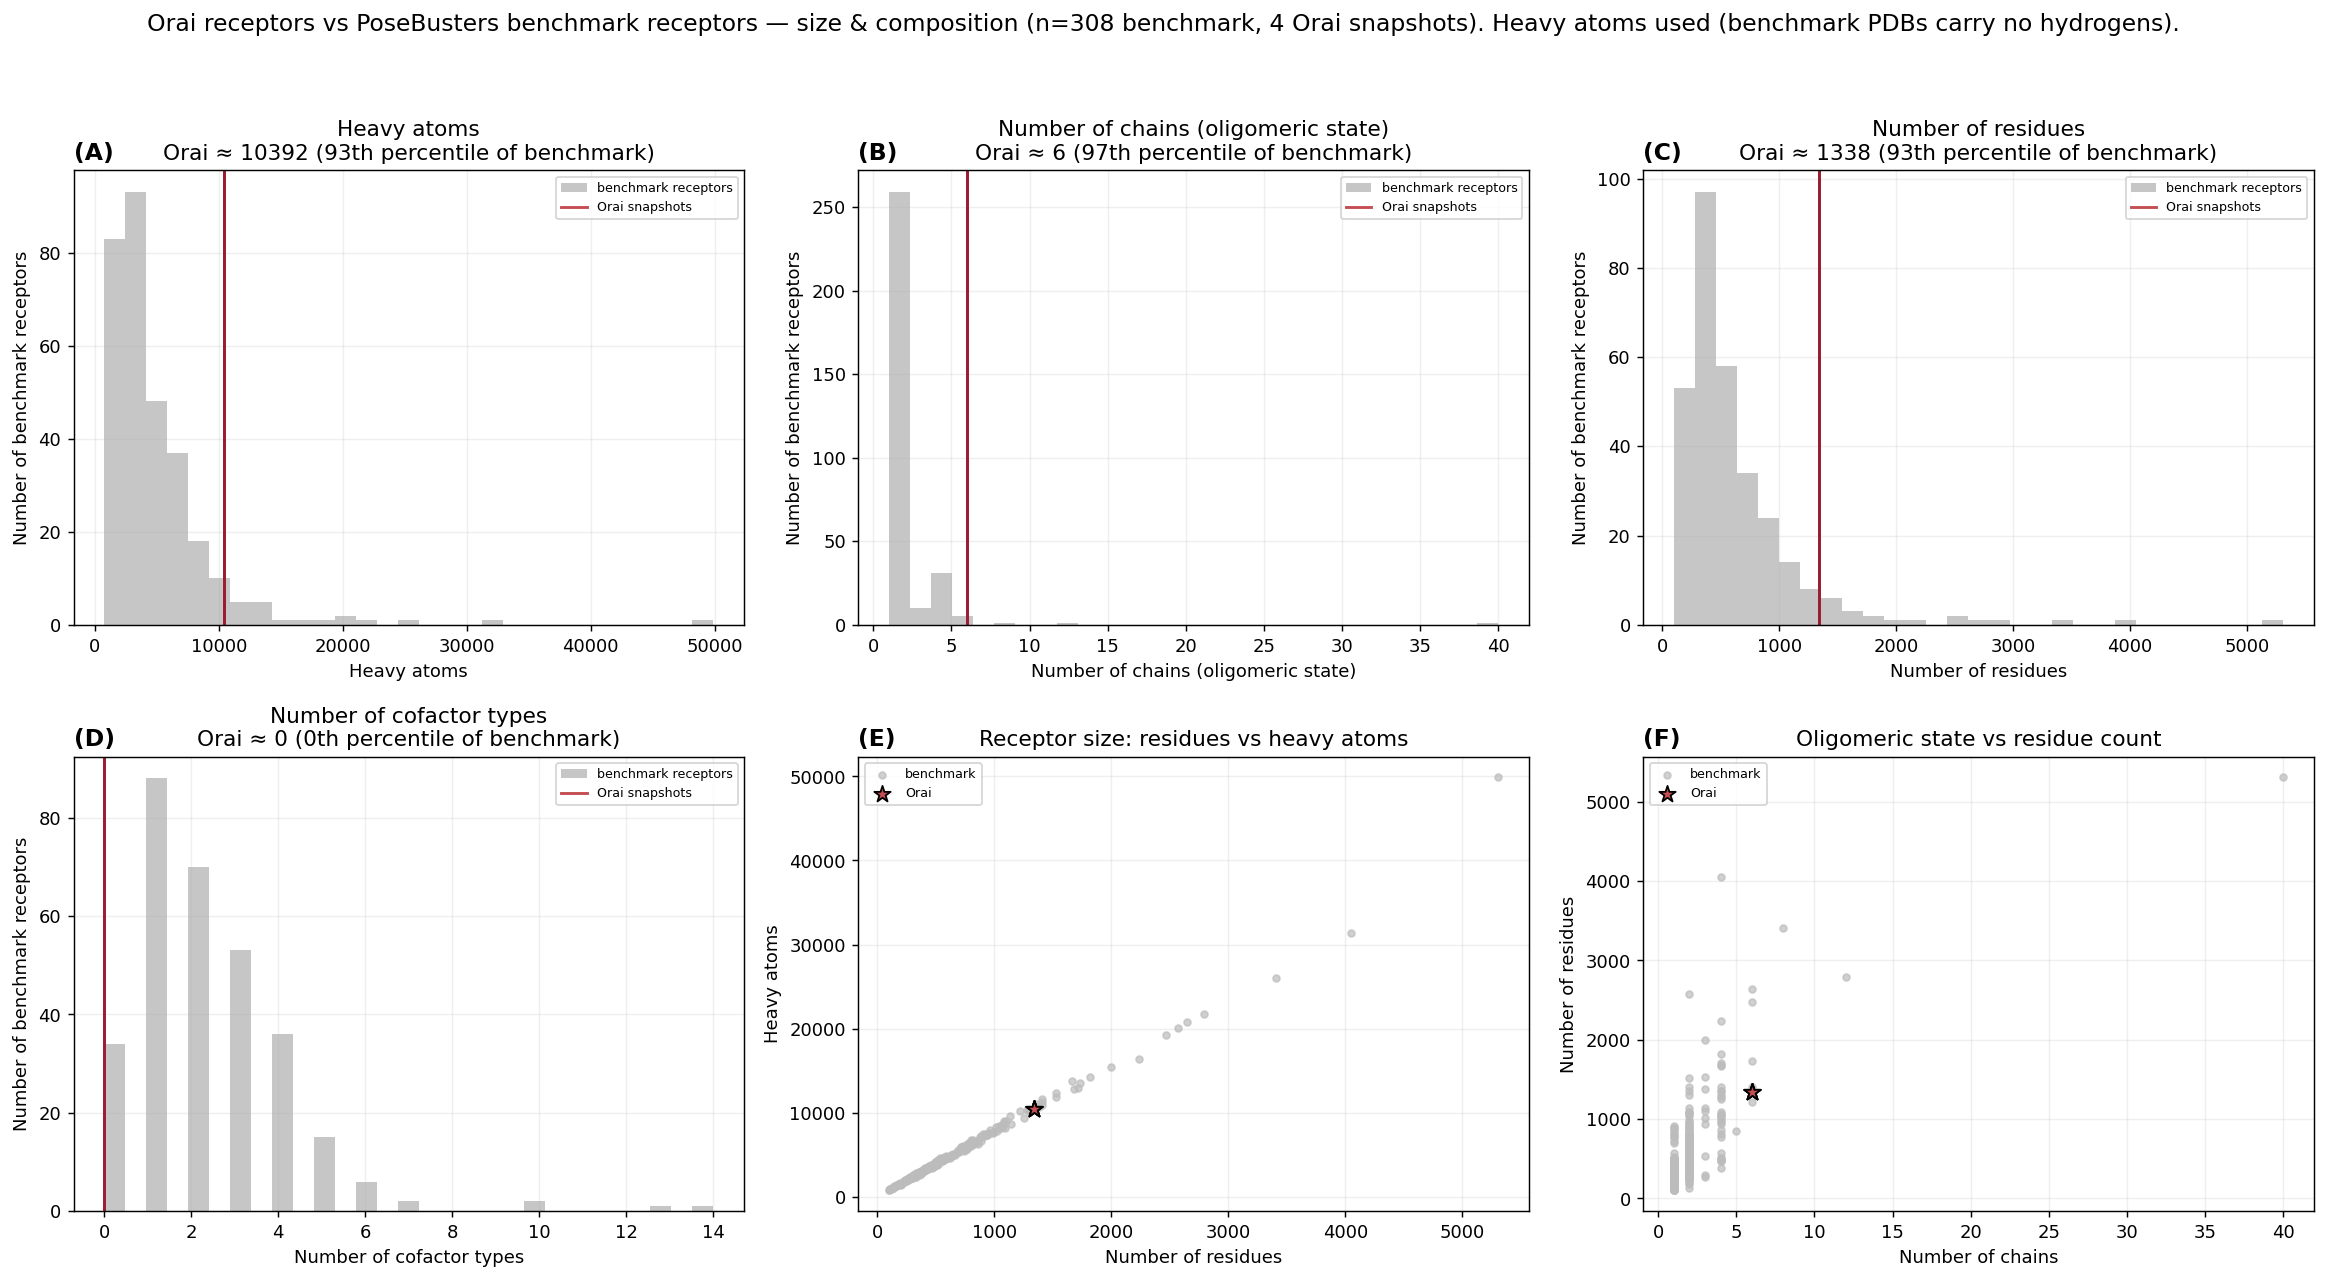

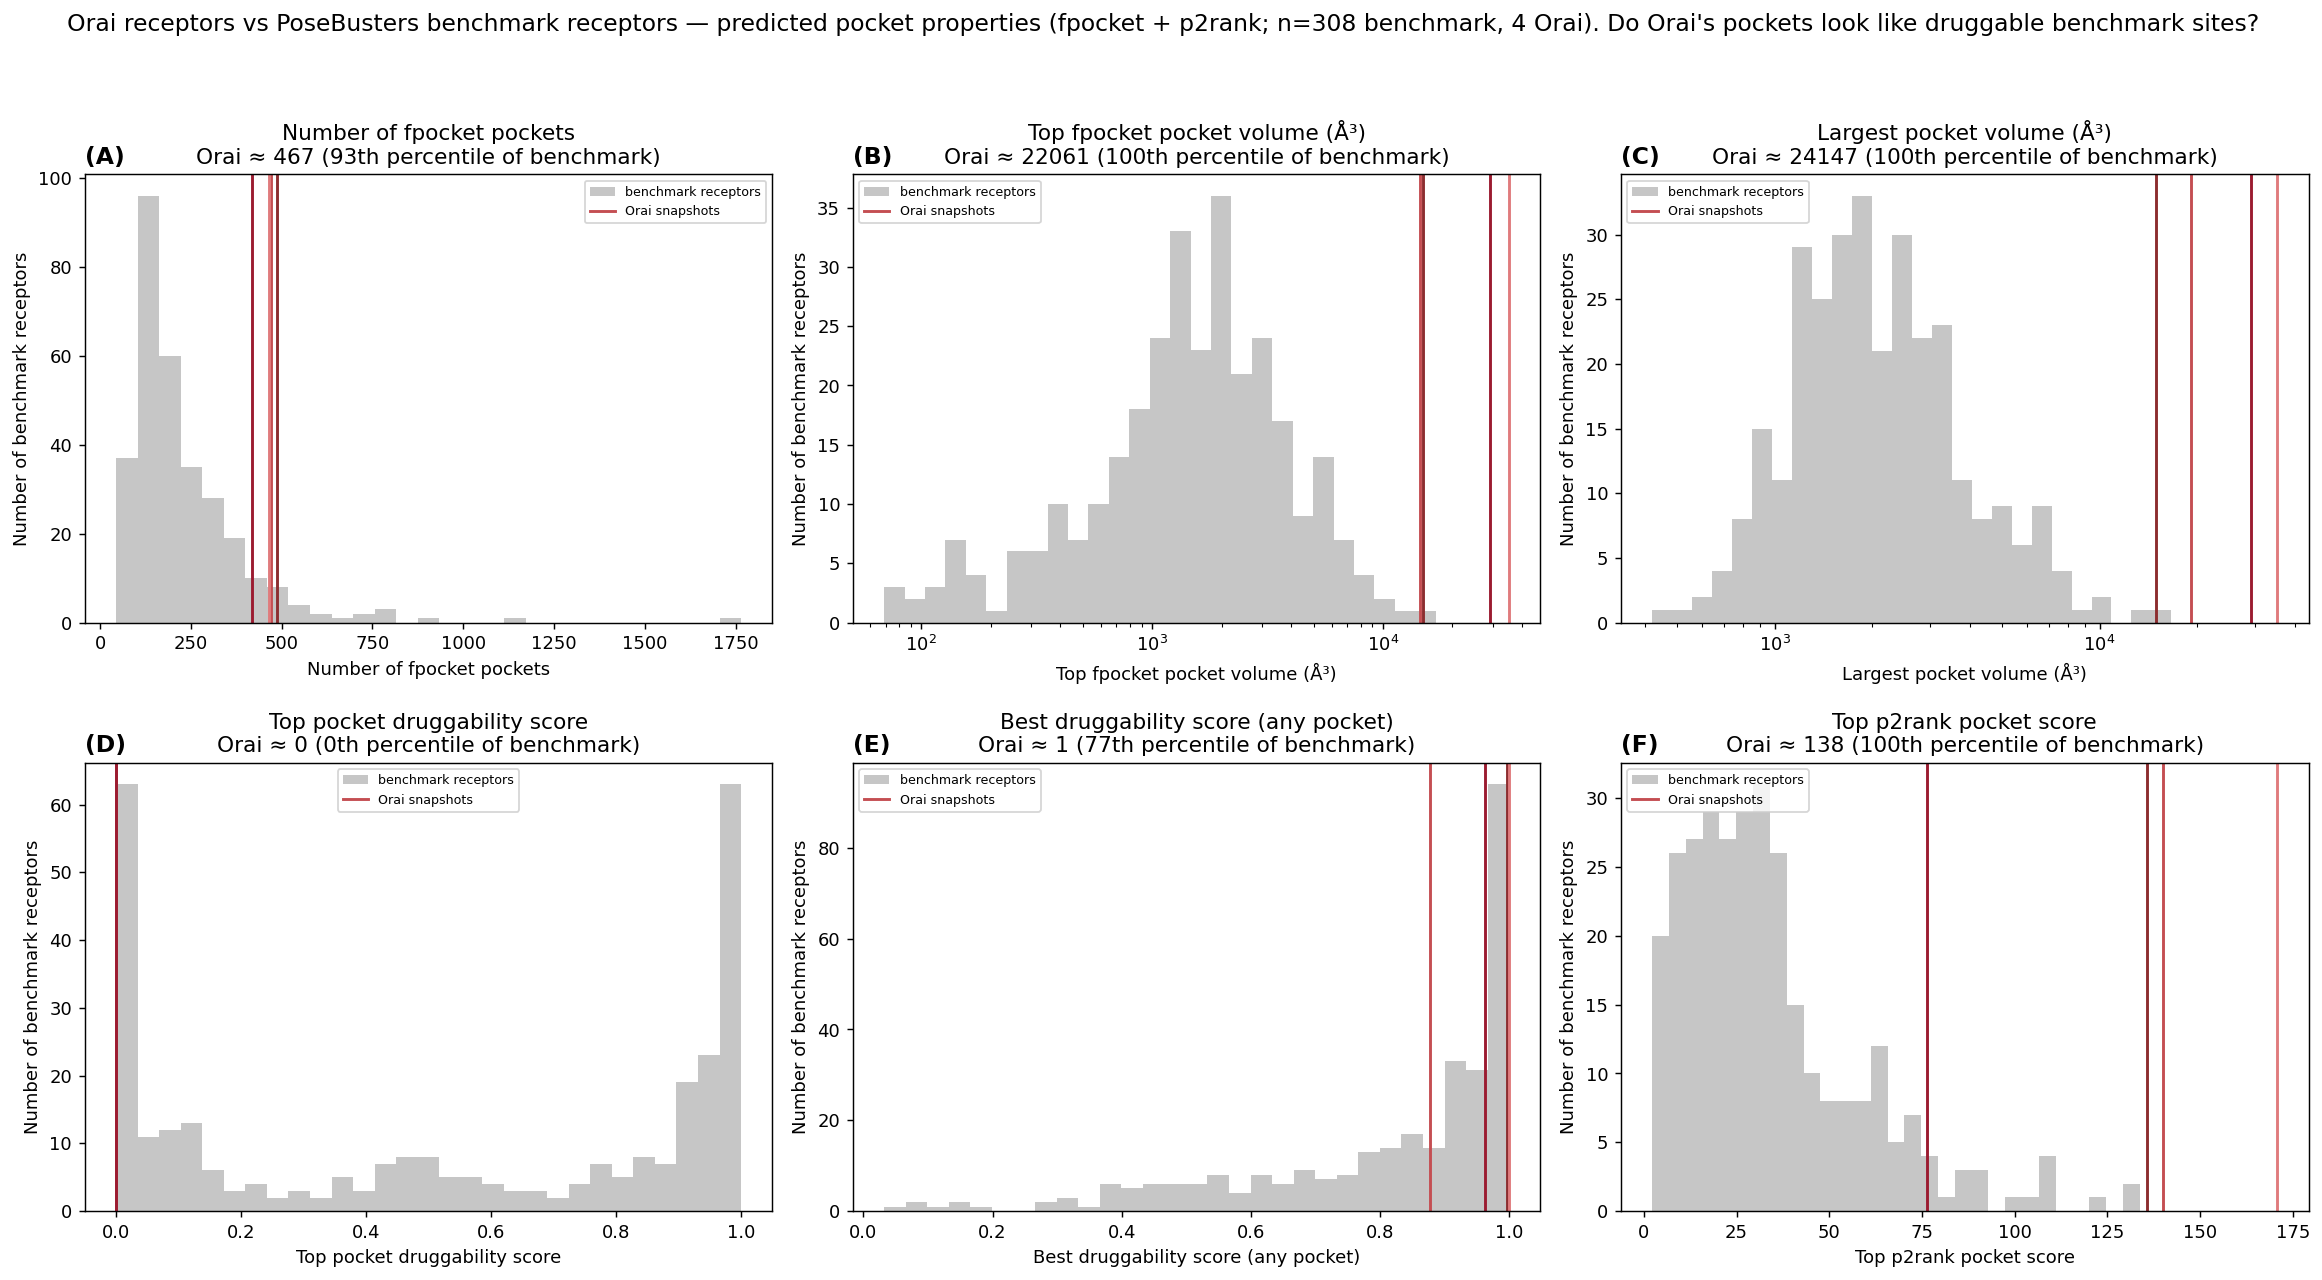

In [ ]:
import subprocess
from pathlib import Path
from IPython.display import Image, display

VINA_PY = "/home/manndo/anaconda3/envs/vina/bin/python"  # pandas/matplotlib live in the vina env

proc = subprocess.run([VINA_PY, "Scripts/Analysis/receptor_comparison_report.py"])
if proc.returncode != 0:
    print(f"\u26a0 receptor_comparison_report.py exited with code {proc.returncode}")

out = Path("posebusters_results/benchmark/receptor_comparison")
for png in ("receptor_descriptor_comparison.png", "receptor_pocket_comparison.png"):
    p = out / png
    if p.exists():
        display(Image(filename=str(p)))

# Orai Section

## Prepare and Create Orai Receptor Files (PDB)

In [ ]:
sys.path.insert(0, str(Path.cwd().parents[1])) 

# Batch clean directory
from Scripts.Utilities.prepare_receptor_pdb import batch_clean_pdbs
batch_clean_pdbs(f"{receptor_folder}/Original", pattern='*.pdb', output_dir=receptor_folder)


Cleaning 4 PDB files from Data/Receptors/Original
⏭ Skipping Orai1WT-MDSnap-Fr300.pdb: cleaned version already exists (Orai1WT-MDSnap-Fr300.pdb)
⏭ Skipping Orai1WT-MDSnap-Fr400.pdb: cleaned version already exists (Orai1WT-MDSnap-Fr400.pdb)
⏭ Skipping Orai1WT-START-Fr0.pdb: cleaned version already exists (Orai1WT-START-Fr0.pdb)
⏭ Skipping Orai1WT-MDSnap-Fr499.pdb: cleaned version already exists (Orai1WT-MDSnap-Fr499.pdb)

✓ Successfully cleaned 4/4 files (4 skipped, already existed)


['Data/Receptors/Orai1WT-MDSnap-Fr300.pdb',
 'Data/Receptors/Orai1WT-MDSnap-Fr400.pdb',
 'Data/Receptors/Orai1WT-START-Fr0.pdb',
 'Data/Receptors/Orai1WT-MDSnap-Fr499.pdb']

## Prepare Ligand Files (PDB)

In [ ]:
from Scripts.Utilities.prep_docking import run_workflow

ligand_outputs = run_workflow(
    input_dir=Path(ligand_folder),
    contains="ligands",
    ligand_formats=["pdb"],
    output_dir=Path(ligand_folder),
    process_postfixes=False,
)



ORAI1 PROTEIN-LIGAND DOCKING PREPARATION WORKFLOW

STEP 1: CONVERTING LIGAND FILES (XYZ → PDB/SDF/MOL2)
✓ OpenBabel is installed

PROCESSING 4 LIGAND(S)
⚡ Processing 4 ligand XYZ files with 4 parallel workers

Converting: /home/manndo/master_dev/Data/Ligands/JKU/2abp-nh2-OPT.xyz

Converting: /home/manndo/master_dev/Data/Ligands/JKU/Synta-66-OPT-Singlet.xyz

Converting: /home/manndo/master_dev/Data/Ligands/JKU/gsk7975a-deprot-OPT.xyz

Converting: /home/manndo/master_dev/Data/Ligands/JKU/gsk7975a-prot-OPT.xyz
✓ PDB  (    5200 bytes) → Data/Ligands/JKU/2abp-nh2-OPT.pdb
✓ PDB  (    6269 bytes) → Data/Ligands/JKU/gsk7975a-prot-OPT.pdb
✓ PDB  (    6728 bytes) → Data/Ligands/JKU/Synta-66-OPT-Singlet.pdb
✓ PDB  (    6119 bytes) → Data/Ligands/JKU/gsk7975a-deprot-OPT.pdb
• 4 ligand(s) already in SDF/MOL2/PDB format — using as-is


STEP 2: VALIDATING PROTEIN STRUCTURES
• No protein files supplied; skipping validation


STEP 3: PREPARING FOR MOLECULAR DOCKING


WORKFLOW COMPLETE

Next Steps:
1. 

## Autodock Vina Orai x JKU Ligands

### Autodock Config

In [ ]:
import yaml

config_path = Path("Scripts/Docking/autodock_vina_docking_config.yaml")

# Load current config
with open(config_path, "r") as f:
    docking_cfg = yaml.safe_load(f)

# ── Edit any values below, then run this cell to save ────────────────────────

# Input paths (synced with notebook variables by default)
docking_cfg["receptors_dir"]       = receptor_folder          # "Data/Receptors"
docking_cfg["ligand_dirs"]         = [ligand_folder]           # ["Data/Ligands/JKU"]

# Preparation tools
docking_cfg["prep_tool"]           = "both"         # "mgltools", "meeko", or "both"
docking_cfg["skip_pdb_validation"] = False          # True=skip, False=validate (default: False)
docking_cfg["process_postfixes"]   = False         # True=add _prepared/_pdbqt postfixes, False=keep original names (default: False)
docking_cfg["repair_terminals"]    = False         # True=repair, False=do not repair (default: False)

# Output
docking_cfg["output_dir"]          = "Dockings/vina_results"
docking_cfg["log_dir"]             = "Dockings/Logs/vina_logs"

# Vina executable
docking_cfg["vina_bin"]            = "/home/manndo/AutoDock-Vina/build/linux/release/vina"

# Scoring function
docking_cfg["scoring_function"]    = "vina"         # "vina", "vinardo", or "ad4"
docking_cfg["autogrid_bin"]        = "/usr/local/bin/autogrid4"

# Batch mode
docking_cfg["batch_mode"]          = None            # None=auto, True=force, False=disable
docking_cfg["batch_size"]          = 10
docking_cfg["batch_timeout"]       = 900

# Docking parameters
docking_cfg["exhaustiveness"]      = 32
docking_cfg["num_modes"]           = 10
docking_cfg["energy_range"]        = 3
docking_cfg["seed"]                = 42
docking_cfg["timeout_per_complex"] = 600

# Parallelism
docking_cfg["max_workers"]         = 1
docking_cfg["cpus_per_worker"]     = 32

# Overwrite settings
docking_cfg["overwrite_existing"]  = False
docking_cfg["overwrite_poses"]     = False
docking_cfg["overwrite_error_log"] = False

# ── Save updated config ─────────────────────────────────────────────────────
with open(config_path, "w") as f:
    yaml.dump(docking_cfg, f, default_flow_style=False, sort_keys=False)

print(f"✓ Config saved to {config_path}")
print(yaml.dump(docking_cfg, default_flow_style=False, sort_keys=False))


✓ Config saved to Scripts/Docking/autodock_vina_docking_config.yaml
receptors_dir: Data/Receptors
ligand_dirs:
- Data/Ligands/JKU
prep_tool: both
skip_pdb_validation: false
process_postfixes: false
repair_terminals: false
output_dir: Dockings/vina_results
log_dir: Dockings/Logs/vina_logs
vina_bin: /home/manndo/AutoDock-Vina/build/linux/release/vina
scoring_function: vina
autogrid_bin: /usr/local/bin/autogrid4
batch_mode: null
batch_size: 10
batch_timeout: 900
exhaustiveness: 32
num_modes: 10
energy_range: 3
seed: 42
timeout_per_complex: 600
max_workers: 1
cpus_per_worker: 32
overwrite_existing: false
overwrite_poses: false
overwrite_error_log: false
retain_hetatm_residues: true



In [ ]:
%run Scripts/Docking/run_autodock.py -c Scripts/Docking/autodock_vina_docking_config.yaml

AutoDock Vina Batch Docking Configuration
Vina executable:     /home/manndo/AutoDock-Vina/build/linux/release/vina
Scoring function:    vina
Prep tool(s):        both
Batch mode:          auto
Batch size:          10
Batch timeout:       900s
Exhaustiveness:      32
Num modes:           10
Energy range:        3 kcal/mol
Timeout per complex: 600s (10 min)
Workers:             1  (CPUs/worker: 32)
Retain HETATM:       YES  (104 residue types: 7DG, ACO, ADP, AG, AMP, ANP, ATP, AU, … (+96 more))
Overwrite docking:   False
Overwrite poses:     False
Output dir:          Dockings/vina_results
Log dir:             Dockings/Logs/vina_logs
Receptor dir:        Data/Receptors
Ligand dirs (1):
  • Data/Ligands/JKU

CPU: Intel(R) Core(TM) i9-14900HX

────────────────────────────────────────────────────────────────────────────────
Preparing proteins with: mgl_tools
────────────────────────────────────────────────────────────────────────────────

ORAI1 PROTEIN-LIGAND DOCKING PREPARATION WORKFLOW

S

## DiffDock Orai x JKU Ligands

### DiffDock Config

In [ ]:
import yaml

config_path = Path("Scripts/Docking/diffdock_docking_config.yaml")

# Load current config
with open(config_path, "r") as f:
    diffdock_cfg = yaml.safe_load(f)

# ── Edit any values below, then run this cell to save ────────────────────────

# Input paths (synced with notebook variables by default)
diffdock_cfg["receptors_dir"]   = receptor_folder      # "Data/Receptors"
diffdock_cfg["ligand_dirs"]     = [str(Path(ligand_folder) / "pdbqt")]  # SDFs are in pdbqt/ subdirectory

# DiffDock installation
diffdock_cfg["diffdock_dir"]    = "/home/manndo/docking_tools/DiffDock"
diffdock_cfg["diffdock_python"] = "/home/manndo/anaconda3/envs/diffdock/bin/python"
diffdock_cfg["diffdock_conda_env"] = "diffdock"

# Inference parameters
diffdock_cfg["num_samples"]       = 10   # poses per complex
diffdock_cfg["inference_steps"]   = 20   # denoising steps (fewer = faster)
diffdock_cfg["device"]            = "cuda:0"  # "cpu" or "cuda:0"

# Output
diffdock_cfg["output_dir"]        = "Dockings/diffdock_results"
diffdock_cfg["log_dir"]           = "Dockings/Logs/diffdock_logs"

# Post-pose optimization — benchmark-best variant
# The benchmark pose-comparison ranked the gnina-refined DiffDock poses best
# (oracle RMSD<=2A 58.1% vs smina 57.1% / raw 50.2%; gnina also leads pose
# PB-validity), so optimize each pose with gnina only instead of the full
# raw/smina/gnina fan-out. The two Benchmark DiffDock cells override
# optimization in-cell, so this YAML value only affects the Orai x JKU run.
diffdock_cfg["optimization"]      = "gnina"

# Batch mode
diffdock_cfg["batch_mode"]        = True   # True = CSV batch (fastest)
diffdock_cfg["batch_size"]        = 15     # complexes per subprocess; 0 = all
diffdock_cfg["group_by_receptor"]   = True  # True = one subprocess per unique receptor
diffdock_cfg["max_workers"]       = 1      # parallel workers (batch_mode=False only)

# Timeout
diffdock_cfg["timeout_per_complex"] = 600  # seconds; 0 = unlimited

# Overwrite settings
diffdock_cfg["overwrite_existing"]  = False  # re-dock already completed combinations
diffdock_cfg["overwrite_error_log"] = False  # retry previously failed ligands

# ── Save updated config ─────────────────────────────────────────────────────
with open(config_path, "w") as f:
    yaml.safe_dump(diffdock_cfg, f, default_flow_style=False, sort_keys=False)

print(f"✓ Config saved to {config_path}")
print(yaml.safe_dump(diffdock_cfg, default_flow_style=False, sort_keys=False))


✓ Config saved to Scripts/Docking/diffdock_docking_config.yaml
receptors_dir: Data/Receptors
ligand_dirs:
- Data/Ligands/JKU/pdbqt
diffdock_dir: /home/manndo/docking_tools/DiffDock
diffdock_python: /home/manndo/anaconda3/envs/diffdock/bin/python
diffdock_conda_env: diffdock
num_samples: 10
inference_steps: 20
device: cuda:0
timeout_per_complex: 600
output_dir: Dockings/diffdock_results
log_dir: Dockings/Logs/diffdock_logs
batch_mode: true
batch_size: 15
group_by_receptor: true
max_workers: 1
overwrite_existing: false
overwrite_error_log: false
optimization: gnina
optimize_search: minimize
optimize_autobox_add: 4.0
optimize_cpu: 1
optimize_seed: 0
optimize_timeout: 300
gnina_use_gpu: true
smina_executable: /home/manndo/anaconda3/envs/diffdock/bin/smina
gnina_executable: /home/manndo/docking_tools/gnina
gnina_lib_dirs: []



In [ ]:
%run Scripts/Docking/run_diffdock.py -c Scripts/Docking/diffdock_docking_config.yaml


DiffDock Batch Docking Configuration
DiffDock dir:        /home/manndo/docking_tools/DiffDock
DiffDock python:     /home/manndo/anaconda3/envs/diffdock/bin/python
Device:              cuda:0
Samples per complex: 10
Inference steps:     20
Pose optimization:   gnina
  search mode:       minimize
  autobox add:       4.0 Å
  gnina GPU:         on
Timeout per complex: 600s (10 min)
Batch mode:          ON
Batch size:          15
Group by receptor:   YES
Overwrite existing:  False
Overwrite error log: False
Output dir:          Dockings/diffdock_results
Log dir:             Dockings/Logs/diffdock_logs
Receptor dir:        Data/Receptors
Ligand dirs (1):
  • Data/Ligands/JKU/pdbqt

GPU: NVIDIA GeForce RTX 4070 Laptop GPU

Processing ligand directory: pdbqt
Output: Dockings/diffdock_results/pdbqt
Found 4 proteins and 8 ligands
DiffDock Docking
Mode: CSV batch (group-by-receptor)
Output directory: Dockings/diffdock_results/pdbqt
Proteins: 4  |  Ligands: 8  |  Total: 32
Previously failed (will

[22:53:56] ERROR: Counts line too short: 'SMALL' on line4
[22:53:56] ERROR: moving to the beginning of the next molecule
[22:53:56] ERROR: Counts line too short: 'SMALL' on line4
[22:53:56] ERROR: moving to the beginning of the next molecule
[22:53:56] ERROR: Counts line too short: 'SMALL' on line4
[22:53:56] ERROR: moving to the beginning of the next molecule
[22:53:56] ERROR: Counts line too short: 'SMALL' on line4
[22:53:56] ERROR: moving to the beginning of the next molecule


  ⏱ 0m15s | ✓ 12 done | ⏳ 1 pending | GPU: 0, 8, 8188 | [0/4 combos] batch 1/4
    Docking: Orai1WT-MDSnap-Fr300+gsk7975a-prot-OPT
    DiffDock: Processing 1 of 1 batches (18 sequences)
  ⏱ 0m31s | ✓ 12 done | ⏳ 1 pending | GPU: 0, 7931, 8188 | [0/4 combos] batch 1/4
    Docking: Orai1WT-MDSnap-Fr300+gsk7975a-prot-OPT
    DiffDock: Processing 1 of 1 batches (18 sequences)
  ⏱ 0m46s | ✓ 12 done | ⏳ 1 pending | GPU: 100, 7927, 8188 | [0/4 combos] batch 1/4
    Docking: Orai1WT-MDSnap-Fr300+gsk7975a-prot-OPT
    DiffDock: Processing 1 of 1 batches (18 sequences)
  ⏱ 1m01s | ✓ 12 done | ⏳ 1 pending | GPU: 100, 7927, 8188 | [0/4 combos] batch 1/4
    Docking: Orai1WT-MDSnap-Fr300+gsk7975a-prot-OPT
    DiffDock: Processing 1 of 1 batches (18 sequences)
  ⏱ 1m16s | ✓ 12 done | ⏳ 1 pending | GPU: 100, 7927, 8188 | [0/4 combos] batch 1/4
    Docking: Orai1WT-MDSnap-Fr300+gsk7975a-prot-OPT
    DiffDock: Processing 1 of 1 batches (18 sequences)
  ⏱ 1m31s | ✓ 12 done | ⏳ 1 pending | GPU: 100, 7927

## Equibind Orai x JKU Ligands

### Equibind Config

In [ ]:
import yaml

config_path = Path("Scripts/Docking/equibind_docking_config.yaml")

# Load current config
with open(config_path, "r") as f:
    equibind_cfg = yaml.safe_load(f)

# ── Edit any values below, then run this cell to save ────────────────────────

# Input paths (synced with notebook variables by default)
equibind_cfg["receptors_dir"]        = receptor_folder      # "Data/Receptors"
equibind_cfg["ligand_dirs"]          = [str(Path(ligand_folder) / "pdbqt")]  # SDFs are in pdbqt/ subdirectory
equibind_cfg["receptor_name_filter"] = ""                   # "" = use every *.pdb
equibind_cfg["ligand_extensions"]    = [".pdb"]    # accepted ligand file types (case-insensitive)

# Pocket detection results (used for pocket-guided docking)
equibind_cfg["fpocket_results_dir"]  = "pocket_results/fpocket_results"
equibind_cfg["p2rank_results_dir"]   = "pocket_results/p2rank_results"

# EquiBind installation
equibind_cfg["equibind_dir"]         = "/home/manndo/tools/EquiBind"
equibind_cfg["equibind_python"]      = "/home/manndo/anaconda3/envs/equibind/bin/python"
equibind_cfg["device"]               = "cuda"               # "cpu" or "cuda"

# Output
equibind_cfg["output_dir"]           = "Dockings/equibind_results"
equibind_cfg["log_dir"]              = "Dockings/Logs/equibind_logs"

# Pose generation
equibind_cfg["n_top_pockets"]          = 3      # top-ranked pockets per method (fpocket + p2rank)
equibind_cfg["poses_per_pocket"]       = 3      # poses per pocket (uses different conformers)
equibind_cfg["n_unguided_poses"]       = 30      # natural EquiBind poses per protein-ligand pair
equibind_cfg["pocket_match_threshold"] = 8.0    # Å — distance to consider a pose "inside" a pocket

# Pocket enforcement
equibind_cfg["force_pocket"]         = True     # reject/clamp poses whose centroid drifts outside pocket
equibind_cfg["clamp_pose_to_pocket"] = True     # clamp drifted poses (instead of rejecting)
# Centroid-clamp mode (EQ_CLAMP_MODE). "on" honours force_pocket + clamp_pose_to_pocket;
# "off" keeps the raw EquiBind centroid; "both" emits __clampON / __clampOFF variants.
equibind_cfg["clamp_mode"]           = "off"   # "both" → emit __clampON / __clampOFF (all clamp variants)

# Post-pose re-search (smina / gnina) — moves the ligand as a body out of deep protein
# clashes that UFF alone cannot relieve (see EquiBind PoseBusters failure note).
#   "off"  → no re-search (default, back-compatible)
#   "on"   → replace each pose with its smina-refined pose
#   "both" → emit both __refRAW and __refSMINA variants (measures the gain)
equibind_cfg["refine_mode"]          = "both"        # "both" → emit __refRAW / __refSMINA (raw + smina variants)
equibind_cfg["refine_tool"]          = "gnina"       # "smina" | "gnina" (physics + CNN) | "both"
equibind_cfg["smina_search"]         = "local_only"  # "local_only" | "minimize"
equibind_cfg["smina_autobox_add"]    = 4.0           # Å padding around the pose for the search box
equibind_cfg["smina_cpu"]            = 1
equibind_cfg["smina_seed"]           = 0
equibind_cfg["smina_timeout_s"]      = 300           # per-pose smina timeout (s)
equibind_cfg["smina_receptor_ext"]   = ".pdb"        # ".pdb" or ".pdbqt" receptor for smina
equibind_cfg["smina_executable"]     = ""            # "" = autodetect on PATH (or set via EQ_SMINA)
equibind_cfg["gnina_executable"]     = ""            # "" = autodetect on PATH (or set via EQ_GNINA)
equibind_cfg["gnina_use_gpu"]        = False         # run gnina's CNN on the GPU (off → --no_gpu)

# Protein cropping (constrains EquiBind search space)
equibind_cfg["use_protein_cropping"] = True
equibind_cfg["pocket_crop_radius"]   = 8.0
equibind_cfg["pocket_crop_buffer"]   = 3.0

# RDKit conformer generation
equibind_cfg["rdkit_seeds"]           = [42, 123, 456, 789, 1001, 2022, 3141, 5926, 8675, 9999, 7, 13, 17, 271, 314, 628, 1234, 1618, 2718, 4040, 4242, 5050, 6060, 7070, 8080, 9090, 11111, 22222, 31415, 65536]
equibind_cfg["conformers_per_seed"]   = 1

# UFF post-docking minimization
equibind_cfg["uff_minimize"]              = True
equibind_cfg["uff_max_iters"]             = 200
equibind_cfg["uff_energy_tol"]            = 1.0e-4
equibind_cfg["uff_force_tol"]             = 1.0e-3
equibind_cfg["uff_proximity_radius"]      = 6.0
equibind_cfg["uff_add_hydrogens"]         = True
equibind_cfg["uff_strip_nonstandard"]     = True
# vdW cutoff for UFF: pairs farther than uff_vdw_thresh × (sum of vdW radii) are
# dropped. The old 0.1 excluded essentially all vdW interactions (even active
# clashes), so the minimizer could not feel — or relieve — protein overlaps.
# 10.0 is RDKit's default and includes the clash range. DO NOT lower back to 0.1.
equibind_cfg["uff_vdw_thresh"]            = 10.0

# Performance
equibind_cfg["gpu_batch_size"]         = 8     # ligands per GPU batch
equibind_cfg["n_parallel_workers"]     = 0     # 0 = auto (min(cpu_count, 26))
equibind_cfg["parallel_conformer_gen"] = True

# Skip / overwrite
equibind_cfg["skip_existing"]          = True   # re-use existing pose SDFs / cached results

# Drop legacy keys the current pipeline no longer reads (no-op if already absent).
# Keeps the saved YAML in sync with equibind_pipeline/config.py.
# for _legacy in ("smina_min_rmsd", "rdkit_prune_rms_thresh", "uff_protein_constraint_wt", "parallel_uff",
#                 "overwrite_existing", "overwrite_error_log", "monitor_level"):
for _legacy in ("smina_min_rmsd", "rdkit_prune_rms_thresh", "uff_protein_constraint_wt", "parallel_uff",
                "monitor_level"):
    equibind_cfg.pop(_legacy, None)

# ── Save updated config ─────────────────────────────────────────────────────
with open(config_path, "w") as f:
    yaml.safe_dump(equibind_cfg, f, default_flow_style=False, sort_keys=False)

print(f"✓ Config saved to {config_path}")
print(yaml.safe_dump(equibind_cfg, default_flow_style=False, sort_keys=False))


✓ Config saved to Scripts/Docking/equibind_docking_config.yaml
receptors_dir: Data/Receptors
ligand_dirs:
- Data/Ligands/JKU/pdbqt
receptor_name_filter: ''
ligand_extensions:
- .pdb
fpocket_results_dir: pocket_results/fpocket_results
p2rank_results_dir: pocket_results/p2rank_results
equibind_dir: /home/manndo/tools/EquiBind
equibind_python: /home/manndo/anaconda3/envs/equibind/bin/python
device: cuda
output_dir: Dockings/equibind_results
log_dir: Dockings/Logs/equibind_logs
n_top_pockets: 3
poses_per_pocket: 3
n_unguided_poses: 30
pocket_match_threshold: 8.0
force_pocket: true
clamp_pose_to_pocket: true
clamp_mode: 'off'
refine_mode: both
refine_tool: gnina
smina_search: local_only
smina_autobox_add: 4.0
smina_cpu: 1
smina_seed: 0
smina_timeout_s: 300
smina_receptor_ext: .pdb
smina_executable: ''
gnina_executable: ''
gnina_use_gpu: false
use_protein_cropping: true
pocket_crop_radius: 8.0
pocket_crop_buffer: 3.0
rdkit_seeds:
- 42
- 123
- 456
- 789
- 1001
- 2022
- 3141
- 5926
- 8675
- 99

In [ ]:
import os, sys, subprocess, yaml
from pathlib import Path

config_path   = Path("Scripts/Docking/equibind_docking_config.yaml")
runner_script = Path("Scripts/Docking/run_equibind.py")

with open(config_path) as f:
    eb_cfg = yaml.safe_load(f)

equibind_dir    = os.path.expanduser(eb_cfg.get("equibind_dir", "~/tools/EquiBind"))
equibind_python = Path(eb_cfg.get("equibind_python", "/home/manndo/anaconda3/envs/equibind/bin/python"))
if not equibind_python.exists():
    raise FileNotFoundError(f"EquiBind python not found: {equibind_python}")

output_root = Path(eb_cfg["output_dir"])
log_root    = Path(eb_cfg["log_dir"])
output_root.mkdir(parents=True, exist_ok=True)
log_root.mkdir(parents=True, exist_ok=True)

# Optional explicit smina binary (only needed when refine_mode != "off").
smina_exe = str(eb_cfg.get("smina_executable", "")).strip()
gnina_exe = str(eb_cfg.get("gnina_executable", "")).strip()

# One EquiBind invocation per ligand directory (mirrors DiffDock pattern)
for lig_dir in eb_cfg.get("ligand_dirs", []):
    lig_path = Path(lig_dir)
    tag      = lig_path.name
    out_dir  = output_root / tag
    log_file = log_root / f"{tag}.log"
    out_dir.mkdir(parents=True, exist_ok=True)

    env = os.environ.copy()
    env.update({
        "EQ_RECEPTORS_DIR":          str(Path(eb_cfg["receptors_dir"]).resolve()),
        "EQ_DRUGS_DIR":              str(lig_path.resolve()),
        "EQ_OUTPUT_DIR":             str(out_dir.resolve()),
        "EQ_RECEPTOR_FILTER":        eb_cfg.get("receptor_name_filter", ""),
        "EQ_LIGAND_EXTENSIONS":      ",".join(eb_cfg.get("ligand_extensions", [".sdf", ".pdb"])),
        "EQ_EQUIBIND_DIR":           equibind_dir,
        "EQ_DEVICE":                 eb_cfg.get("device", "cuda"),
        "EQ_GPU_BATCH_SIZE":         str(eb_cfg.get("gpu_batch_size", 8)),
        "EQ_FPOCKET_DIR":            str(Path(eb_cfg.get("fpocket_results_dir", "pocket_results/fpocket_results")).resolve()),
        "EQ_P2RANK_DIR":             str(Path(eb_cfg.get("p2rank_results_dir",  "pocket_results/p2rank_results")).resolve()),
        "EQ_N_TOP_POCKETS":          str(eb_cfg.get("n_top_pockets", 3)),
        "EQ_POSES_PER_POCKET":       str(eb_cfg.get("poses_per_pocket", 3)),
        "EQ_N_UNGUIDED_POSES":       str(eb_cfg.get("n_unguided_poses", 5)),
        "EQ_POCKET_MATCH_THRESHOLD": str(eb_cfg.get("pocket_match_threshold", 8.0)),
        "EQ_FORCE_POCKET":           str(eb_cfg.get("force_pocket", True)),
        "EQ_CLAMP_POSE":             str(eb_cfg.get("clamp_pose_to_pocket", True)),
        # ── Clash-study knobs (June-2026 pipeline) ───────────────────────────
        "EQ_CLAMP_MODE":             str(eb_cfg.get("clamp_mode", "on")),
        "EQ_REFINE_MODE":            str(eb_cfg.get("refine_mode", "off")),
        "EQ_REFINE_TOOL":            str(eb_cfg.get("refine_tool", "smina")),
        "EQ_SMINA_SEARCH":           str(eb_cfg.get("smina_search", "local_only")),
        "EQ_SMINA_AUTOBOX_ADD":      str(eb_cfg.get("smina_autobox_add", 4.0)),
        "EQ_SMINA_CPU":              str(eb_cfg.get("smina_cpu", 1)),
        "EQ_SMINA_SEED":             str(eb_cfg.get("smina_seed", 0)),
        "EQ_SMINA_TIMEOUT":          str(eb_cfg.get("smina_timeout_s", 300)),
        "EQ_SMINA_RECEPTOR_EXT":     str(eb_cfg.get("smina_receptor_ext", ".pdb")),
        "EQ_GNINA_USE_GPU":          str(eb_cfg.get("gnina_use_gpu", False)),
        # ─────────────────────────────────────────────────────────────────────
        "EQ_USE_CROPPING":           str(eb_cfg.get("use_protein_cropping", True)),
        "EQ_CROP_RADIUS":            str(eb_cfg.get("pocket_crop_radius", 8.0)),
        "EQ_CROP_BUFFER":            str(eb_cfg.get("pocket_crop_buffer", 3.0)),
        "EQ_CONFORMERS_PER_SEED":    str(eb_cfg.get("conformers_per_seed", 1)),
        "EQ_RDKIT_SEEDS":            ",".join(str(s) for s in eb_cfg.get("rdkit_seeds", [])),
        "EQ_UFF_MINIMIZE":           str(eb_cfg.get("uff_minimize", True)),
        "EQ_UFF_MAX_ITERS":          str(eb_cfg.get("uff_max_iters", 200)),
        "EQ_UFF_ENERGY_TOL":         str(eb_cfg.get("uff_energy_tol", 1e-4)),
        "EQ_UFF_FORCE_TOL":          str(eb_cfg.get("uff_force_tol", 1e-3)),
        "EQ_UFF_PROXIMITY_RADIUS":   str(eb_cfg.get("uff_proximity_radius", 6.0)),
        "EQ_UFF_ADD_H":              str(eb_cfg.get("uff_add_hydrogens", True)),
        # vdW cutoff: 10.0 (RDKit default) so UFF can feel/relieve clashes.
        # NOTE: 0.1 silently disables clash relief — do not pass it.
        "EQ_UFF_VDW_THRESH":         str(eb_cfg.get("uff_vdw_thresh", 10.0)),
        "EQ_UFF_STRIP_NONSTANDARD":  str(eb_cfg.get("uff_strip_nonstandard", True)),
        "EQ_WORKERS":                str(eb_cfg.get("n_parallel_workers", 0) or os.cpu_count() or 8),
        "EQ_PARALLEL_CONFORMER_GEN": str(eb_cfg.get("parallel_conformer_gen", True)),
        "EQ_SKIP_EXISTING":          str(eb_cfg.get("skip_existing", True)),
    })
    # Pin an explicit smina binary only if one is configured; otherwise the
    # pipeline autodetects it on PATH (refine_mode="off" needs no smina at all).
    if smina_exe:
        env["EQ_SMINA"] = smina_exe
    if gnina_exe:
        env["EQ_GNINA"] = gnina_exe

    # ── Restrict the Orai x JKU run to the benchmark-best EquiBind variant ──
    # The per-variant PoseBusters analysis of the benchmark poses found
    # unguided + gnina-refined to be the single best variant (oracle RMSD<=2A
    # 17.4% and pose PB-validity 24.2%, both ahead of smina and raw). The
    # shared equibind_docking_config.yaml must keep the full fan-out because
    # the Benchmark EquiBind cell reads n_top_pockets / clamp_mode from it, so
    # we pin the best variant here at run time instead of in the YAML.
    env["EQ_N_TOP_POCKETS"] = "0"        # unguided only (guided fpocket/p2rank OFF)
    env["EQ_CLAMP_MODE"]    = "off"      # no-op for unguided poses
    env["EQ_REFINE_MODE"]   = "on"       # single refined variant
    env["EQ_REFINE_TOOL"]   = "gnina"    # benchmark-best refiner (physics + CNN rescore)
    env["EQ_GNINA"]         = "/home/manndo/docking_tools/gnina"  # wrapper (equibind env has no gnina on PATH)

    print(f"\n{'=' * 78}")
    print(f"EquiBind: receptors={eb_cfg['receptors_dir']}  ligands={lig_path}")
    print(f"  clamp_mode={env['EQ_CLAMP_MODE']}  refine_mode={env['EQ_REFINE_MODE']}  uff_vdw_thresh={env['EQ_UFF_VDW_THRESH']}")
    print(f"  output → {out_dir}")
    print(f"  log    → {log_file}")
    print(f"{'=' * 78}\n")

    with open(log_file, "w") as lf:
        proc = subprocess.run(
            [str(equibind_python), str(runner_script.resolve())],
            env=env, cwd=str(Path.cwd()), stdout=lf, stderr=subprocess.STDOUT,
        )

    status = "✓" if proc.returncode == 0 else "✗"
    print(f"{status} EquiBind finished (rc={proc.returncode}) — log: {log_file}")



EquiBind: receptors=Data/Receptors  ligands=Data/Ligands/JKU/pdbqt
  clamp_mode=off  refine_mode=on  uff_vdw_thresh=10.0
  output → Dockings/equibind_results/pdbqt
  log    → Dockings/Logs/equibind_logs/pdbqt.log

✓ EquiBind finished (rc=0) — log: Dockings/Logs/equibind_logs/pdbqt.log


## Orai × JKU Ligands || PoseBusters

PoseBusters validation and PandaMap interaction analysis for the **Orai × JKU**
dataset (4 Orai1WT receptors × the JKU ligands).

- **AutoDock** poses come from `Dockings/vina_results/JKU_meeko/docking/` and are
  staged with the `_meeko` converter tag stripped so `<receptor>__<ligand>` matches
  the staged receptor stem.
- **EquiBind** poses are consumed straight from `Dockings/equibind_results/pdbqt/`
  (`<ligand>__<receptor>/` dirs) — pinned to the benchmark-best **unguided,
  gnina-refined** family only (no guided fpocket/p2rank pockets, no clamp axis).
- **DiffDock** poses come from `Dockings/diffdock_results/pdbqt/`
  (`<ligand>__<receptor>/` dirs with `rank*.sdf`), read directly.

There is **no crystal reference** for Orai, so pose-comparison and native-interaction
recovery can't be computed, and the crystal-only knobs from the benchmark cells (the
RMSD-to-crystal sweep, `--max-rmsd`, and the `--ids-file` benchmark-set restriction)
don't apply.

Otherwise both steps mirror the benchmark analysis: they keep **every** variant in the
CSV tables and printed summary while collapsing the comparison **figures** to a single
variant per tool, labelled **DiffDock\*** / **EquiBind\***. The ranking is borrowed
from the benchmark `oracle_summary.csv` (best on PB-Valid AND RMSD ≤ 2 Å), since Orai
has no oracle of its own:

- **DiffDock** — its optimizer labels (`original`/`smina`/`gnina`) match the benchmark,
  so it auto-collapses to the oracle best, currently **`diffdock_smina`**
  (`--collapse-plots-only` in the validity report; `--best-diffdock-only` in PandaMap).
- **EquiBind** — the Orai run emits a single family, `equibind_unguided_gnina`
  (unguided, gnina-refined; no clamp axis), which **matches** the benchmark oracle's
  top EquiBind variant. The validity report pins it explicitly to `unguided_gnina` via
  `--equibind-variant` (auto-pick would now select the same row); in PandaMap,
  `--best-equibind-only` collapses it to **EquiBind\*** (`equibind_unguided_gnina`).

In [ ]:
import os, re, sys, shutil, subprocess
from pathlib import Path

# ── Paths ────────────────────────────────────────────────────────────────────
receptors_src    = Path("Data/Receptors")
jku_ligand_sdfs  = Path("Data/Ligands/JKU/pdbqt")                    # per-ligand .sdf templates
autodock_src     = Path("Dockings/vina_results/JKU_meeko/docking")   # <rec>_meeko__<lig>_vina_vina_out.pdbqt
diffdock_src     = Path("Dockings/diffdock_results/pdbqt")           # <lig>__<rec>/rank*.sdf (read directly by the config)
equibind_src     = Path("Dockings/equibind_results/pdbqt")           # <lig>__<rec>/*.sdf (read directly by the config)

pb_runner_script = Path("Scripts/Docking/Posebusters/run_posebusters.py")
# PoseBusters must run in the vina env — only its posebusters carries the
# energy_ratio crash-fix; the notebook kernel's package may be unpatched.
VINA_PY = "/home/manndo/anaconda3/envs/vina/bin/python"
pb_config_path   = Path("Scripts/Docking/Posebusters/posebusters_orai_jku_config.yaml")

staging_root     = Path("posebusters_results/_orai_jku_staging")
rec_staging      = staging_root / "receptors"
ad_staging       = staging_root / "autodock"
tpl_staging      = staging_root / "ligand_templates"
for d in (rec_staging, ad_staging, tpl_staging):
    d.mkdir(parents=True, exist_ok=True)

ORAI_RECEPTORS = ["Orai1WT-START-Fr0", "Orai1WT-MDSnap-Fr300",
                  "Orai1WT-MDSnap-Fr400", "Orai1WT-MDSnap-Fr499"]


def _link(src: Path, dst: Path) -> bool:
    if not src.exists():
        return False
    if dst.is_symlink() or dst.exists():
        try:
            if dst.resolve() == src.resolve():
                return True
        except OSError:
            pass
        dst.unlink()
    try:
        dst.symlink_to(src.resolve())
    except OSError:
        shutil.copy2(src, dst)
    return True


# 1. Stage the 4 Orai receptors
n_rec = sum(_link(receptors_src / f"{name}.pdb", rec_staging / f"{name}.pdb")
            for name in ORAI_RECEPTORS)

# 2. Stage AutoDock poses, stripping the "_meeko" converter tag — INCLUDING retry
#    variants (_meeko__, _meeko_retry1__, …) — so "<receptor>__<ligand>..." matches
#    the staged receptor stem (same convention the collectors expect for the
#    Orai_Benchmark set). Without it, Fr0's meeko-retry poses were staged as a
#    phantom protein "Orai1WT-START-Fr0_meeko_retry1" and never matched the
#    Orai1WT-START-Fr0 receptor, so PoseBusters dropped Fr0 AutoDock.
n_ad = 0
if autodock_src.is_dir():
    # drop stale mis-staged links from older runs (staged name still carries _meeko)
    for stale in ad_staging.glob("*_meeko*__*_vina_out.pdbqt"):
        stale.unlink()
    for pdbqt in sorted(autodock_src.glob("*_vina_out.pdbqt")):
        staged_name = re.sub(r"_meeko(?:_retry\d+)?__", "__", pdbqt.name)
        if _link(pdbqt, ad_staging / staged_name):
            n_ad += 1

# 3. Stage per-ligand SDF templates under the AutoDock ligand label
#    (label after parsing = "<ligand>_vina", e.g. "2abp-nh2-OPT_vina").
n_tpl = 0
if jku_ligand_sdfs.is_dir():
    for sdf in sorted(jku_ligand_sdfs.glob("*.sdf")):
        _link(sdf, tpl_staging / f"{sdf.stem}_vina.sdf")   # AutoDock label alias
        _link(sdf, tpl_staging / f"{sdf.stem}.sdf")        # bare alias
        n_tpl += 1

# DiffDock + EquiBind poses are read straight from their source dirs by the
# config (dirs already named "<ligand>__<receptor>"); counted here for sanity.
n_dd = sum(1 for d in diffdock_src.iterdir()
           if d.is_dir() and "__" in d.name and any(d.glob("rank*.sdf"))) if diffdock_src.is_dir() else 0
n_eb = sum(1 for d in equibind_src.iterdir()
           if d.is_dir() and "__" in d.name
           and any(f for f in d.glob("**/*.sdf") if "prep" not in f.parts)) if equibind_src.is_dir() else 0

print("Staging summary (Orai × JKU)")
print("─" * 60)
print(f"  receptors staged:          {n_rec:>5}  → {rec_staging}")
print(f"  AutoDock poses staged:     {n_ad:>5}  → {ad_staging}")
print(f"  ligand templates staged:   {n_tpl:>5}  → {tpl_staging}")
print(f"  DiffDock pose dirs (src):  {n_dd:>5}  ({diffdock_src})")
print(f"  EquiBind pose dirs (src):  {n_eb:>5}  ({equibind_src})")

if not pb_config_path.exists():
    raise FileNotFoundError(pb_config_path)

print(f"\n{'═' * 60}")
print("PoseBusters validation — Orai × JKU")
print(f"  config: {pb_config_path}")
print(f"{'═' * 60}\n")

# ── Runtime knobs → run_posebusters.py CLI flags (each overrides the YAML
#    config; tune here without editing the config file) ──────────────────
PB_QUIET        = True    # silence RDKit/pandas warning flood + per-file listings
PB_MONITOR      = True    # live core/RAM/swap monitor + bottleneck flags
PB_MONITOR_INT  = 30      # seconds between monitor snapshots
PB_WORKERS      = None    # parallel workers; None = all CPUs. Lower (e.g. 12) if the
                          # run OOM-stalls or the monitor prints "SWAP GROWING".
PB_POSE_TIMEOUT = None    # per-pose wall-clock cap (s); None = config default (600)
PB_MAXTASKS     = None    # recycle each worker every N poses; None = config (200)
PB_OVERWRITE    = True   # True → --overwrite: delete the CSV and re-validate from
                          # scratch. run_posebusters RESUMES BY COMPLEX (protein+ligand),
                          # so after poses are REGENERATED IN PLACE (same 12 complexes,
                          # new gnina SDFs) a plain re-run skips all 36 and reuses the
                          # stale CSV. Flip True once to pick up regenerated poses.
# stall_timeout / max_restarts (dead-worker auto-restart) live in the YAML config.

pb_cmd = [VINA_PY, str(pb_runner_script.resolve()),
          "--config", str(pb_config_path.resolve())]
if PB_QUIET:                    pb_cmd.append("--quiet")
if PB_MONITOR:                  pb_cmd.append("--monitor")
if PB_MONITOR_INT is not None:  pb_cmd += ["--monitor-interval", str(PB_MONITOR_INT)]
if PB_WORKERS is not None:      pb_cmd += ["--workers", str(PB_WORKERS)]
if PB_POSE_TIMEOUT is not None: pb_cmd += ["--pose-timeout", str(PB_POSE_TIMEOUT)]
if PB_MAXTASKS is not None:     pb_cmd += ["--max-tasks-per-child", str(PB_MAXTASKS)]
if PB_OVERWRITE:                pb_cmd.append("--overwrite")
print(f"  flags:   {' '.join(pb_cmd[4:]) or '(none — using config defaults)'}")

env = os.environ.copy()
env["PYTHONUNBUFFERED"] = "1"

proc = subprocess.run(pb_cmd, cwd=str(Path.cwd()), env=env)
print(f"\nPoseBusters Orai × JKU COMPLETE  (return code: {proc.returncode})")
print(f"  Results: posebusters_results/orai_jku/dock/")

Staging summary (Orai × JKU)
────────────────────────────────────────────────────────────
  receptors staged:              4  → posebusters_results/_orai_jku_staging/receptors
  AutoDock poses staged:        16  → posebusters_results/_orai_jku_staging/autodock
  ligand templates staged:       4  → posebusters_results/_orai_jku_staging/ligand_templates
  DiffDock pose dirs (src):     16  (Dockings/diffdock_results/pdbqt)
  EquiBind pose dirs (src):     16  (Dockings/equibind_results/pdbqt)

════════════════════════════════════════════════════════════
PoseBusters validation — Orai × JKU
  config: Scripts/Docking/Posebusters/posebusters_orai_jku_config.yaml
════════════════════════════════════════════════════════════

  flags:   --quiet --monitor --monitor-interval 30 --overwrite

Total: 4 PDB files found in /home/manndo/master_dev/posebusters_results/_orai_jku_staging/receptors
DOCKING POSES OVERVIEW


  autodock: 16 protein-ligand combinations
  diffdock: 16 protein-ligand combinations


[07:43:48] WARNING: Accepted unusual valence(s): C(3); C(2)

[07:43:48] WARNING:  Problems/mismatches: Mobile-H( Mobile-H groups: Attachment points, Number)

[07:43:48] WARNING: Accepted unusual valence(s): C(3); C(2)

[07:43:48] WARNING: Accepted unusual valence(s): C(3); C(2)

[07:43:48] WARNING: Accepted unusual valence(s): C(3); C(2)

[07:43:48] WARNING: Accepted unusual valence(s): C(3); C(2)

[07:43:48] WARNING: Accepted unusual valence(s): C(3); C(2)

[07:43:48] WARNING:  Problems/mismatches: Mobile-H( Mobile-H groups: Attachment points, Number)

[07:43:48] WARNING:  Problems/mismatches: Mobile-H( Mobile-H groups: Attachment points, Number)

[07:43:48] WARNING:  Problems/mismatches: Mobile-H( Mobile-H groups: Attachment points, Number)

[07:43:48] WARNING:  Problems/mismatches: Mobile-H( Mobile-H groups: Attachment points, Number)

[07:43:48] WARNING:  Problems/mismatches: Mobile-H( Mobile-H groups: Attachment points, Number)

[07:43:48] WARNING: Accepted unusual valence(s): C(3

  Processed 1/976  (overall 1/976)
  Processed 10/976  (overall 10/976)


[07:43:52] WARNING: Accepted unusual valence(s): C(3); C(2)

[07:43:52] WARNING:  Problems/mismatches: Mobile-H( Mobile-H groups: Attachment points, Number)

[07:43:52] WARNING: Accepted unusual valence(s): C(3); C(2)

[07:43:52] WARNING:  Problems/mismatches: Mobile-H( Mobile-H groups: Attachment points, Number)

[07:43:52] WARNING: Accepted unusual valence(s): C(3); C(2)

[07:43:52] WARNING:  Problems/mismatches: Mobile-H( Mobile-H groups: Attachment points, Number)

[07:43:52] WARNING: Accepted unusual valence(s): C(3); C(2)

[07:43:52] WARNING:  Problems/mismatches: Mobile-H( Mobile-H groups: Attachment points, Number)

[07:43:53] WARNING: Accepted unusual valence(s): C(3); C(2)

[07:43:53] WARNING:  Problems/mismatches: Mobile-H( Mobile-H groups: Attachment points, Number)

[07:43:53] WARNING: Accepted unusual valence(s): C(3); C(2)

[07:43:53] WARNING:  Problems/mismatches: Mobile-H( Mobile-H groups: Attachment points, Number)

[07:43:53] WARNING: Accepted unusual valence(s): C(3

  Processed 20/976  (overall 20/976)


...

  Processed 800/976  (overall 800/976)
    [CHECKPOINT] 800/976 new  |  total rows: 800  →  posebusters_filtered_results.csv


[07:46:13] WARNING: Ambiguous stereo: center(s)



  Processed 810/976  (overall 810/976)


[07:46:15] WARNING: Ambiguous stereo: center(s)



  Processed 820/976  (overall 820/976)
  Processed 830/976  (overall 830/976)
  [MON t+145s] cores~32.0/32 (sys-CPU 100%)  load 29.9/32  RAM 29% (9.0G/31.2G)  swap 0.0G
             procs 65  threads 98  RSS 7.5G  main-CPU 8%  |  poses 836 (+163, 5.4/s)
  Processed 840/976  (overall 840/976)
  Processed 850/976  (overall 850/976)
  Processed 860/976  (overall 860/976)
  Processed 870/976  (overall 870/976)
  Processed 880/976  (overall 880/976)
  Processed 890/976  (overall 890/976)
  Processed 900/976  (overall 900/976)
  Processed 910/976  (overall 910/976)
  Processed 920/976  (overall 920/976)
  Processed 930/976  (overall 930/976)
  Processed 940/976  (overall 940/976)
  Processed 950/976  (overall 950/976)
  Processed 960/976  (overall 960/976)
  Processed 970/976  (overall 970/976)
  [MON] monitor off — peak load 30/32 | slowest 5.4 poses/s
    [FINAL] 973/976 new  |  total rows: 973  →  posebusters_filtered_results.csv

  Done:  new=973  prev=0  total=973  errors=3  timeouts=0


## Orai × JKU Ligands || TRANSMEMBRANE PORE EXCLUSION

▶ /home/manndo/anaconda3/envs/vina/bin/python Scripts/Analysis/orai_transmembrane_exclusion.py --dataset orai_jku --workers 8 --diffdock-variant gnina --equibind-variant gnina --ligands 2abp-nh2-OPT gsk7975a-prot Synta-66-OPT

=== orai_jku ===
reading posebusters_results/orai_jku/dock/posebusters_filtered_results.csv
  --ligands: keeping 730 of 973 poses across 3 ligand(s): ['2abp-nh2-OPT', 'Synta-66-OPT-Singlet', 'gsk7975a-prot-OPT']
  Orai1WT-MDSnap-Fr300: R91 z-end [0.72, 4.56, 3.4]  E106 z-end [0.69, 4.15, -19.16]  L=22.6  r_pore=7.7  r_outer=36.0  axis|PCA=2.94deg
  Orai1WT-MDSnap-Fr400: R91 z-end [0.81, 4.72, 3.38]  E106 z-end [0.36, 4.8, -19.4]  L=22.8  r_pore=7.6  r_outer=36.0  axis|PCA=2.86deg
  Orai1WT-MDSnap-Fr499: R91 z-end [0.53, 4.34, 3.22]  E106 z-end [0.41, 3.99, -19.51]  L=22.7  r_pore=7.6  r_outer=36.3  axis|PCA=3.79deg
  Orai1WT-START-Fr0: R91 z-end [0.01, -0.0, 3.21]  E106 z-end [-0.07, -0.03, -19.19]  L=22.4  r_pore=7.0  r_outer=32.4  axis|PCA=0.19deg
  classifying

,toolchain,ligand,generated,pb_valid,pb_valid_pct_of_generated,pb_valid_outside_tm,pb_valid_outside_tm_pct_of_generated
0,AutoDock Vina,2abp-nh2-OPT,40,40,100.0,28,70.0
1,AutoDock Vina,Synta-66-OPT-Singlet,40,40,100.0,24,60.0
2,AutoDock Vina,gsk7975a-prot-OPT,40,40,100.0,30,75.0
3,DiffDock*,2abp-nh2-OPT,38,37,97.4,20,52.6
4,DiffDock*,Synta-66-OPT-Singlet,40,33,82.5,30,75.0
5,DiffDock*,gsk7975a-prot-OPT,40,34,85.0,29,72.5
6,EquiBind*,2abp-nh2-OPT,120,23,19.2,2,1.7
7,EquiBind*,Synta-66-OPT-Singlet,120,12,10.0,0,0.0
8,EquiBind*,gsk7975a-prot-OPT,120,13,10.8,0,0.0


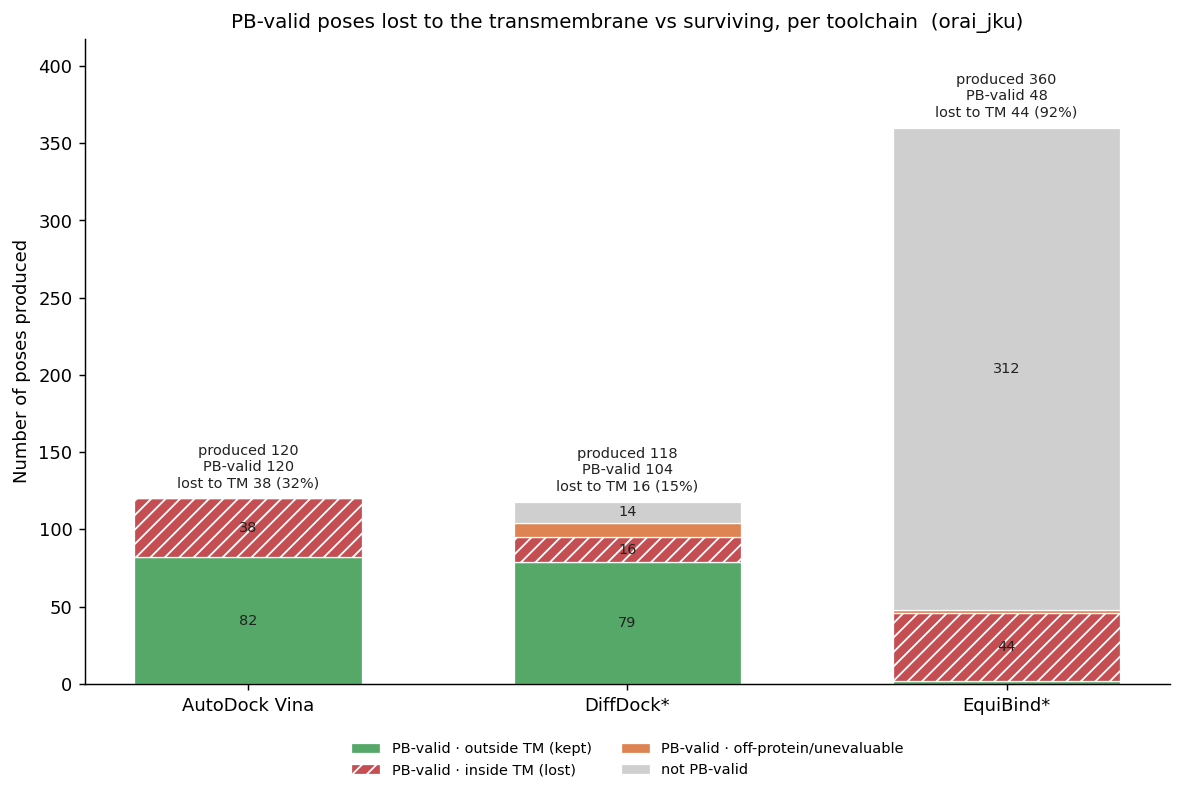

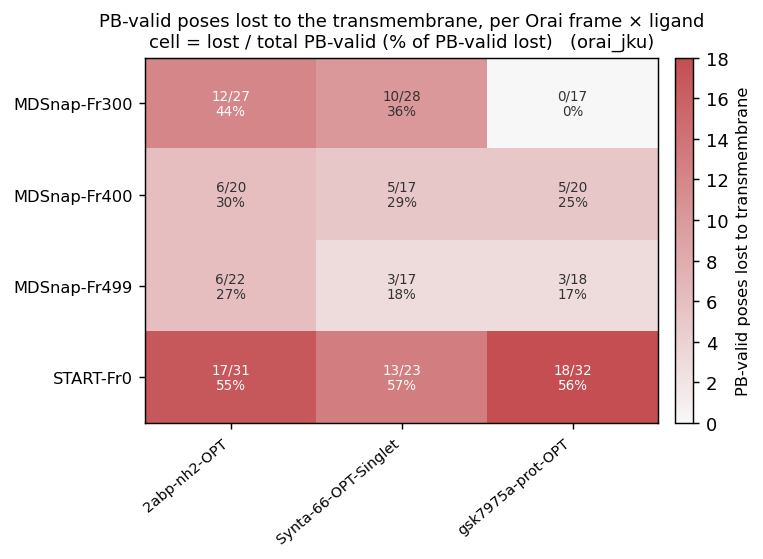

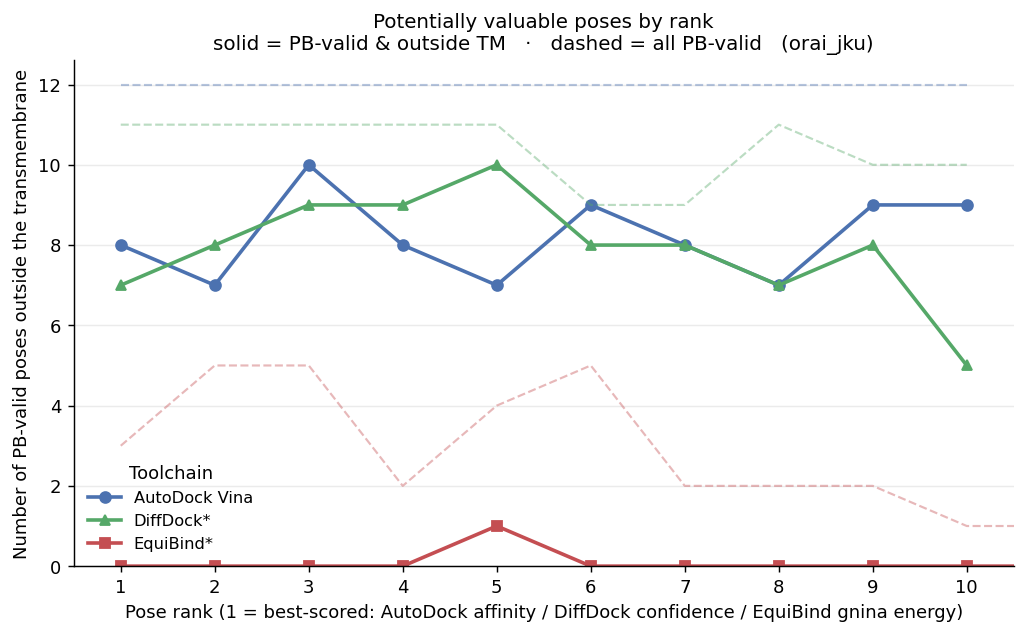

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# Orai1 TRANSMEMBRANE PORE EXCLUSION   (TM1 conduction pore: Arg91 ↔ Glu106)
# ═══════════════════════════════════════════════════════════════════════════
# The R91→E106 span of TM1 lines the membrane-embedded ion-conduction pore of
# the Orai1 hexamer — it is NOT a druggable surface pocket. Poses whose ligand
# centroid lands in that axial slab are the channel's transmembrane region and
# are removed here so the downstream validity / PandaMap / pose-cluster analyses
# run on non-transmembrane poses only.
#
# Scripts/Analysis/orai_transmembrane_exclusion.py builds a per-frame R91↔E106
# slab (Cα rings of all 6 subunits), classifies every pose, and writes three
# PB-valid figures. TOOLCHAINS: it reports the gnina-optimised variant of each
# tool (DiffDock*, EquiBind* — asterisk marks gnina; EquiBind, which has no native
# score, is ranked by its gnina energy). This cell then writes
# posebusters_filtered_results.no_tm.csv — the TM-excluded pose set the validity
# (cell below), PandaMap (its config) and pose-cluster cells read — and shows the
# toolchain × ligand PoseBusters-validity / transmembrane-survival table + the figures.
#
# ORDER: reads the PoseBusters output produced by the "PoseBusters validation —
# Orai × JKU" cell below, so run that cell at least once BEFORE this one.
import subprocess
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

VINA_PY   = "/home/manndo/anaconda3/envs/vina/bin/python"   # rdkit/pandas/matplotlib here
DATASET   = "orai_jku"
LIGANDS   = ["2abp-nh2-OPT", "gsk7975a-prot", "Synta-66-OPT"]      # e.g. ["gsk7975a", "Synta-66"] to restrict the whole analysis
                      # to those ligands (case-insensitive substrings); None = all.
DD_VARIANT = "gnina"  # DiffDock optimizer variant reported (gnina → DiffDock*)
EB_VARIANT = "gnina"  # EquiBind refine variant reported (gnina → EquiBind*)
TM_DIR    = Path(f"posebusters_results/{DATASET}/transmembrane_filter")
PB_CSV    = Path(f"posebusters_results/{DATASET}/dock/posebusters_filtered_results.csv")
NO_TM_CSV = PB_CSV.with_name("posebusters_filtered_results.no_tm.csv")

assert PB_CSV.exists(), f"{PB_CSV} not found — run the PoseBusters (Orai × JKU) cell below first."

# 1) classify every pose against the per-frame R91↔E106 TM slab. Writes
#    tm_pose_classification.csv (all variants, tagged with variant/toolchain),
#    tm_{excluded,kept,invalid}_poses.csv, per-frame zone files, summary.json,
#    and the 3 figures for the gnina toolchains.
cmd = [VINA_PY, "Scripts/Analysis/orai_transmembrane_exclusion.py",
       "--dataset", DATASET, "--workers", "8",
       "--diffdock-variant", DD_VARIANT, "--equibind-variant", EB_VARIANT]
if LIGANDS:
    cmd += ["--ligands", *LIGANDS]
print("▶", " ".join(cmd))
if subprocess.run(cmd).returncode != 0:
    raise RuntimeError("transmembrane exclusion failed")

# 2) TM-excluded pose CSV the downstream analysis reads. Keep only 'kept' poses
#    = placed on the protein AND outside the TM slab (ALL variants — the downstream
#    cells 55/56 do their own variant selection). Transmembrane poses AND
#    invalid-placement (off-pocket / exploded) poses are both dropped.
cls  = pd.read_csv(TM_DIR / "tm_pose_classification.csv", low_memory=False)
keep = set(cls.loc[cls["analysis_status"] == "kept", "pose_file"])
pb   = pd.read_csv(PB_CSV, low_memory=False)
pb[pb["pose_file"].isin(keep)].to_csv(NO_TM_CSV, index=False)

counts = cls["analysis_status"].value_counts().to_dict()
print("\nTransmembrane exclusion (Orai × JKU)")
print("─" * 60)
for k in ("kept", "transmembrane", "invalid_placement", "unevaluable"):
    print(f"  {k:20s} {counts.get(k, 0):>5}")
print(f"  {'→ kept for analysis':20s} {len(keep):>5}  / {len(pb)} poses  →  {NO_TM_CSV.name}")

# 3) Toolchain × JKU ligand (Orai frames pooled): PoseBusters validity and how many
#    valid poses survive OUTSIDE the transmembrane. Reports the selected gnina
#    toolchains (DiffDock*, EquiBind*) + AutoDock; the Orai-frame dimension is
#    pooled. Value columns, in order:
#      generated                              overall poses the toolchain produced (any placement)
#      pb_valid                               PoseBusters-valid poses
#      pb_valid_pct_of_generated              their share of generated (%)
#      pb_valid_outside_tm                    PB-valid AND kept (on protein, outside the
#                                             R91↔E106 slab) — the survivors feeding no_tm
#      pb_valid_outside_tm_pct_of_generated   their share of generated (%)
TM_TABLE = TM_DIR / "toolchain_ligand_tm_validity_table.csv"
report = cls[cls["variant"].isin(["none", "gnina"])].copy()   # autodock + gnina toolchains
report["_pbv"] = report["pb_valid"] == True                              # noqa: E712
report["_pbv_out"] = report["_pbv"] & (report["analysis_status"] == "kept")
tbl = (report.groupby(["toolchain", "ligand"])
       .agg(generated=("pose_file", "size"),
            pb_valid=("_pbv", "sum"),
            pb_valid_outside_tm=("_pbv_out", "sum"))
       .reset_index())
tbl["pb_valid"] = tbl["pb_valid"].astype(int)
tbl["pb_valid_outside_tm"] = tbl["pb_valid_outside_tm"].astype(int)
_den = tbl["generated"].clip(lower=1)
tbl["pb_valid_pct_of_generated"] = (100 * tbl["pb_valid"] / _den).round(1)
tbl["pb_valid_outside_tm_pct_of_generated"] = (100 * tbl["pb_valid_outside_tm"] / _den).round(1)
tbl = (tbl[["toolchain", "ligand", "generated", "pb_valid", "pb_valid_pct_of_generated",
            "pb_valid_outside_tm", "pb_valid_outside_tm_pct_of_generated"]]
       .sort_values(["toolchain", "ligand"]).reset_index(drop=True))
tbl.to_csv(TM_TABLE, index=False)
print(f"\nToolchain × JKU-ligand PoseBusters-validity / transmembrane-survival table "
      f"({len(tbl)} rows) → {TM_TABLE}")
display(tbl)

# 4) PB-valid analysis figures (gnina toolchains)
for fig in ("fig_tool_tm_loss.png", "fig_pbvalid_lost_matrix.png", "fig_rank_survival.png"):
    p = TM_DIR / fig
    if p.exists():
        display(Image(filename=str(p)))


## Orai × JKU Ligands || Validity Report

In [ ]:
# NOTE: reads the TRANSMEMBRANE-EXCLUDED pose set (…no_tm.csv) built by the TM-exclusion cell above.
# ── posebusters_validity_report.py knobs — flip these, then run ───────────────────
# Mirrors the benchmark "Pose Validity Report" cell, adapted for crystal-free Orai.
# --collapse-plots-only: keep EVERY variant in the CSV tables + printed summary, but
#   show only ONE variant per tool in the main comparison figures (01-05), labelled
#   'DiffDock*' / 'EquiBind*'. Per-tool variant-comparison figures (06 EquiBind,
#   07 DiffDock) and a per-variant PB-check failure-rate TABLE are written on every run.
COLLAPSE_PLOTS_ONLY = True        # True → tables all-variants, plots collapsed

# Which variant the plots collapse to. Orai has NO crystal, so the oracle "PB-Valid AND
# RMSD ≤ 2 Å" ranking is borrowed from the benchmark oracle_summary_all_variants.csv
# (the default --oracle-summary). DiffDock's optimizer labels (original/smina/gnina)
# match the benchmark, so leaving DIFFDOCK_VARIANT=None lets --collapse-plots-only
# auto-pick the oracle best (currently diffdock_smina) — same as the benchmark cell.
# EquiBind's Orai run emits a single family, equibind_unguided_gnina (unguided,
# gnina-refined; no clamp axis), which matches the benchmark oracle's top EquiBind
# variant. It is pinned explicitly to unguided_gnina via the crystal-free
# --equibind-variant selector (once present, None would auto-pick the same row).
#
# NOTE: those gnina rows enter the CSV only after the Orai × JKU PoseBusters
# validation cell above is re-run; until then the CSV holds the old unguided+smina
# fan-out, so "unguided_gnina" warns and falls back to keeping all EquiBind variants.
DIFFDOCK_VARIANT = "gnina"                        # raw|original|smina|gnina | None → oracle auto-pick (diffdock_smina)
EQUIBIND_VARIANT = "unguided_gnina"   # tokens matched on pocket/refine/clamp | None → auto-pick (now matches benchmark oracle: equibind_unguided_gnina)

# Crystal-only knobs from the benchmark cell — the RMSD-to-crystal sweep (fig 08),
# --max-rmsd filter and the --ids-file benchmark-set restriction — do NOT apply here:
# Orai has no crystal and the JKU ligands aren't in the benchmark id list. Omitted.
_collapse = " --collapse-plots-only" if COLLAPSE_PLOTS_ONLY else ""
_ddv = f" --diffdock-variant {DIFFDOCK_VARIANT}" if DIFFDOCK_VARIANT else ""
_eqv = f' --equibind-variant "{EQUIBIND_VARIANT}"' if EQUIBIND_VARIANT else ""

get_ipython().run_line_magic(
    "run",
    "Scripts/Analysis/posebusters_validity_report.py"
    " --csv posebusters_results/orai_jku/dock/posebusters_filtered_results.no_tm.csv"
    " --out-dir posebusters_results/orai_jku/dock/validity_report"
    + _collapse
    + _ddv
    + _eqv)

diffdock-variant: keeping only 'diffdock_gnina' (shown as 'DiffDock*').
equibind-variant: keeping only 'equibind_unguided_gnina' (shown as 'EquiBind*').


  [rmsd≤2] no pose within 2 Å of the crystal — omitting rmsd2_* summary columns.
failure waterfall: top variant per tool = autodock, diffdock_gnina, equibind_unguided_gnina
Total poses scored        : 296
Total PB-valid poses      : 171 (57.77%)
Receptor-ligand pairs     : 12
Methods / variants found  : 4 (autodock, diffdock, diffdock_gnina, equibind_unguided_gnina)
Plots collapsed to        : autodock, diffdock_gnina, equibind_unguided_gnina

── Per-method summary (all variants) ─────────────
                         total_poses  valid_poses  valid_fraction
docking_method                                                   
autodock                          82           82           1.000
diffdock                         101            8           0.079
diffdock_gnina                    92           79           0.859
equibind_unguided_gnina           21            2           0.095

── PB check failure rate (%) per variant (n_poses, survival %, then worst checks) ──
                   

## Orai × JKU Ligands || PandaMap analysis

In [ ]:
import subprocess

VINA_PY = "/home/manndo/anaconda3/envs/vina/bin/python"  # pandamap lives only in the vina env
CFG = "Scripts/Analysis/pandamap_orai_jku_config.yaml"

# run_pandamap builds the interaction fingerprints; the report draws the charts.
# Keep only the gnina-refined variant of each ML tool (DiffDock + EquiBind); AutoDock
# Vina stays as the classical baseline. Uses the same --diffdock-variant /
# --equibind-variant pins as the validity / transmembrane / pose-cluster cells (DD_VARIANT
# / EB_VARIANT = "gnina" there), so every stage collapses to the SAME gnina toolchains.
#   --diffdock-variant gnina → pins DiffDock to 'diffdock_gnina', relabelled 'DiffDock*'.
#       Unlike --best-diffdock-only, this ignores the benchmark oracle (which picks
#       diffdock_smina) and forces gnina.
#   --equibind-variant gnina → pins EquiBind to its gnina-refined variant (here
#       equibind_unguided_gnina, the only EquiBind family in this run), relabelled 'EquiBind*'.
#       Unlike --best-equibind-only, no oracle summary is consulted.
DD_VARIANT = "gnina"  # DiffDock optimizer variant kept (gnina → DiffDock*)
EB_VARIANT = "gnina"  # EquiBind refine variant kept (gnina → EquiBind*)
FLAGS = ["--diffdock-variant", DD_VARIANT, "--equibind-variant", EB_VARIANT]
for script in ("run_pandamap.py", "pandamap_interaction_report.py"):
    # --overwrite only for the generator: run_pandamap writes its summary CSVs in
    # resume/append mode, so without it a reused results dir accumulates stale poses
    # (old variants / pairs) across runs. The report has no --overwrite flag.
    extra = ["--overwrite"] if script == "run_pandamap.py" else []
    print(f"\n▶ {script}")
    proc = subprocess.run([VINA_PY, f"Scripts/Analysis/{script}", "--config", CFG, *FLAGS, *extra])
    if proc.returncode != 0:
        print(f"⚠ {script} exited with code {proc.returncode} — continuing notebook.")



▶ run_pandamap.py
PandaMap interaction generator
  input   : PB CSV /home/manndo/master_dev/posebusters_results/orai_jku/dock/posebusters_filtered_results.no_tm.csv
  output  : /home/manndo/master_dev/pandamap_results/orai_jku
  top-N   : 3 per method×pair   pb_valid_only=True
  crystal : (none)
Collected 171 poses; methods: ['autodock', 'diffdock', 'diffdock_gnina', 'equibind_unguided_gnina']
equibind-variant=gnina: keeping 'equibind_unguided_gnina'; 171 → 171 poses. Run the report with the same --equibind-variant to label it 'EquiBind*'.
diffdock-variant=gnina: keeping 'diffdock_gnina'; 171 → 163 poses. Run the report with the same --diffdock-variant to label it 'DiffDock*'.
Selected 71 poses across 12 pairs (3 methods)
Resume: 71 already done, 0 to do

DONE  ok=0  errors=0
  /home/manndo/master_dev/pandamap_results/orai_jku/pandamap_pose_summary.csv  (395 poses)
  /home/manndo/master_dev/pandamap_results/orai_jku/pandamap_interactions.csv  (5496 residue-level interaction rows)

Mea

[07:46:49] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[07:46:49] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[07:46:49] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[07:46:49] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[07:46:49] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[07:46:49] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.



Report written to: /home/manndo/master_dev/pandamap_results/orai_jku/report
  01_interaction_profile.png
  02_type_heatmap.png
  02b_total_boxplot.png
  03_residue_hotspots.png
  06_interaction_vs_chemotype.png
  06b_descriptor_corr.png
  07_residue_class.png
  08_ligand_element.png


## Orai × JKU Ligands || Pose-cluster & cross-tool analysis

Same no-crystal pose-cluster dissection (`Scripts/Analysis/orai_pose_cluster_report.py`)
for the Orai × JKU ligands: clustering, cross-tool agreement, PoseBusters
survivors vs failures, per-frame distribution, outliers and pore-axis position.
Reads the Orai×JKU PoseBusters per-pose CSV with **no ID restriction** (JKU ligands
are not in the benchmark list). Note this set is small (3 JKU ligands × 3 Orai
frames), so the aggregate statistics are a limited view and the ligand-descriptor
panel is skipped (too few ligands / not in the benchmark feature cache).

**Consensus (updated).** With no crystal, each pair's consensus site is now the
**geometric median of the per-tool sites** (one point per tool), so a high-throughput
tool can no longer drag the reference to wherever it sampled most; single-tool pairs
fall back to the largest cluster and are flagged (`consensus_source`). The
“valid poses nearer consensus” comparison is restricted to multi-tool pairs, and
clustering uses the same k=1-capable distance-threshold cut as the benchmark.
Outputs → `posebusters_results/orai_jku/pose_clusters/`. Runs in the `vina` env.

=== orai_pose_cluster_report.py (Orai × JKU) ===
Loading poses from posebusters_results/orai_jku/dock/posebusters_filtered_results.no_tm.csv ...
  296 poses | tools: ['autodock', 'diffdock', 'equibind'] | frames: 4 | ligands: 3
Computing pose centroids ...
Analysing 12 (frame, ligand) pairs ...

ORAI POSE-CLUSTER REPORT  (n=12 pairs, thr=5 Å)
  Tools analysed: autodock, diffdock, equibind
  Cross-tool agreement (all tools' consensus within 5 Å): 0% of 12 multi-tool pairs
  Median inter-tool consensus distance: 33.3 Å
  Mean clusters/pair: 10.17 | mean dominant-cluster fraction: 22%
  PoseBusters (multi-tool pairs): valid poses sit 24.3 Å from consensus vs 25.9 Å for invalid (median) → valid are tighter

  Per Orai MD frame:
  frame                    pairs  clusters  dom.frac  agree%  pb-valid%
  Orai1WT-MDSnap-Fr300         3     11.67       24%     0%        60%
  Orai1WT-MDSnap-Fr400         3     10.67       23%     0%        55%
  Orai1WT-MDSnap-Fr499         3      9.33       20%

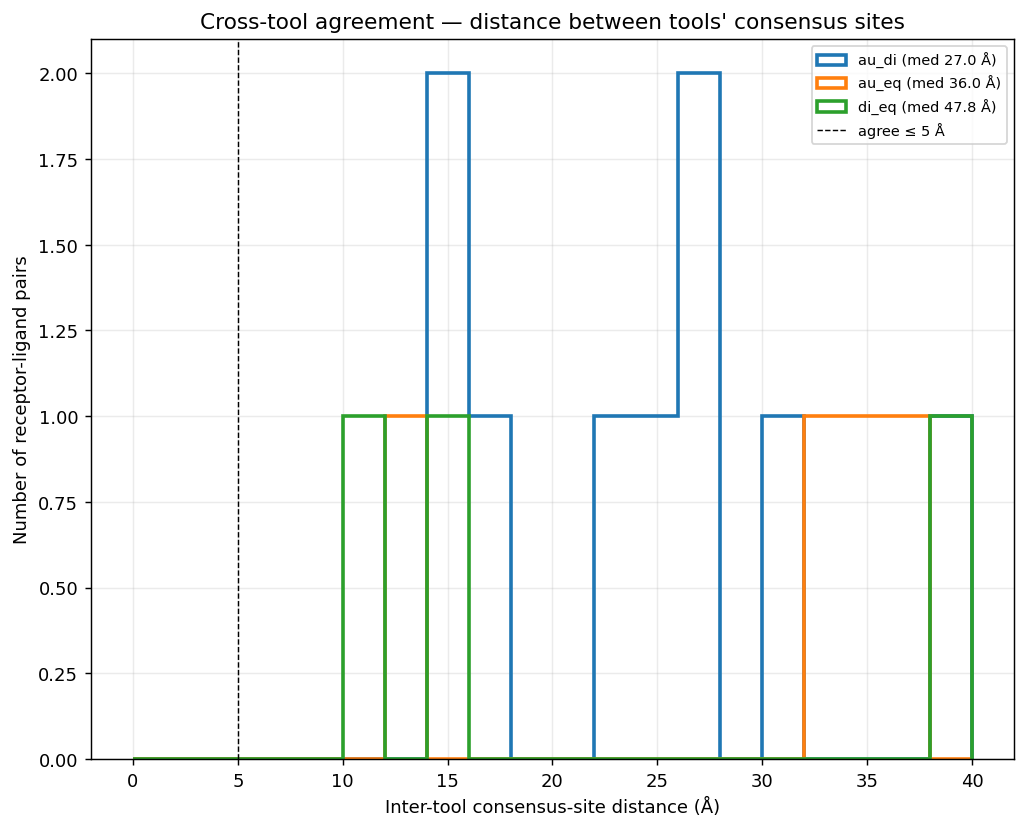

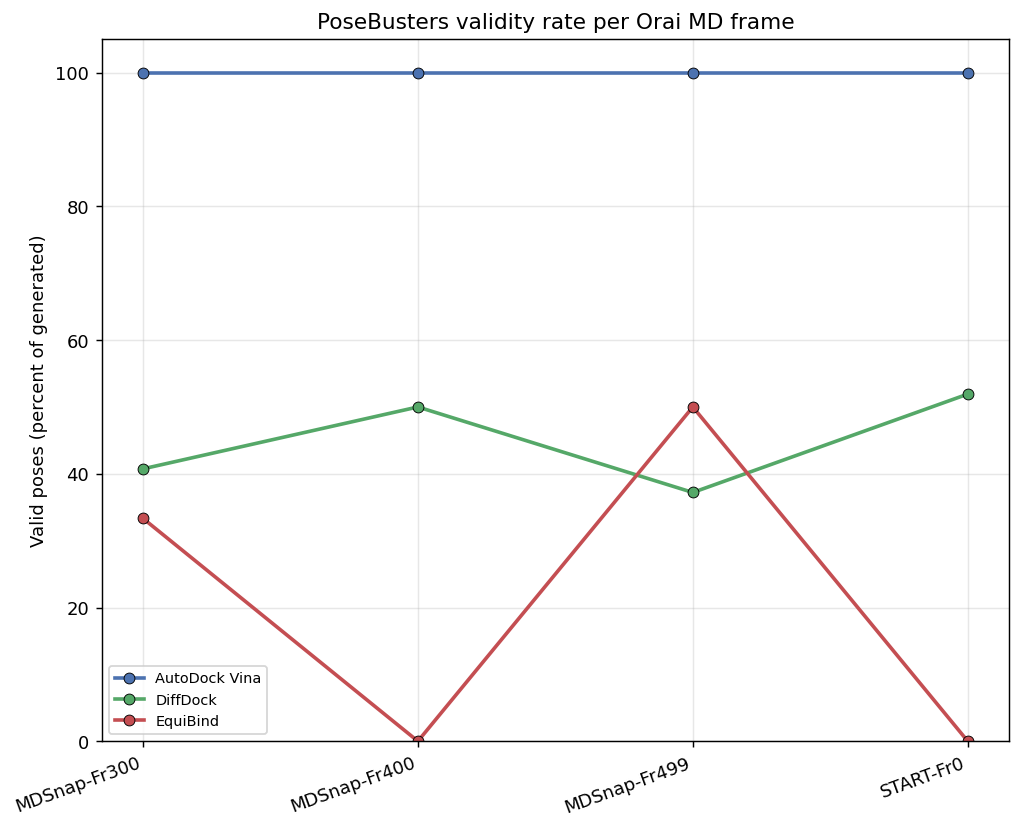

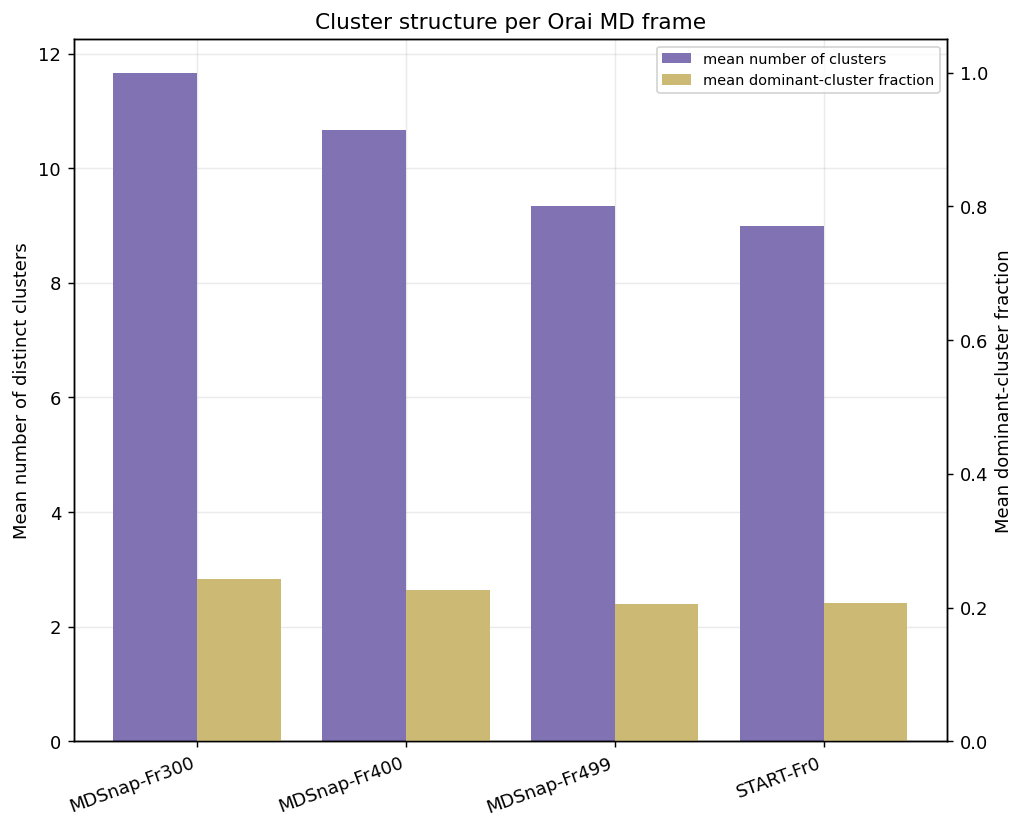

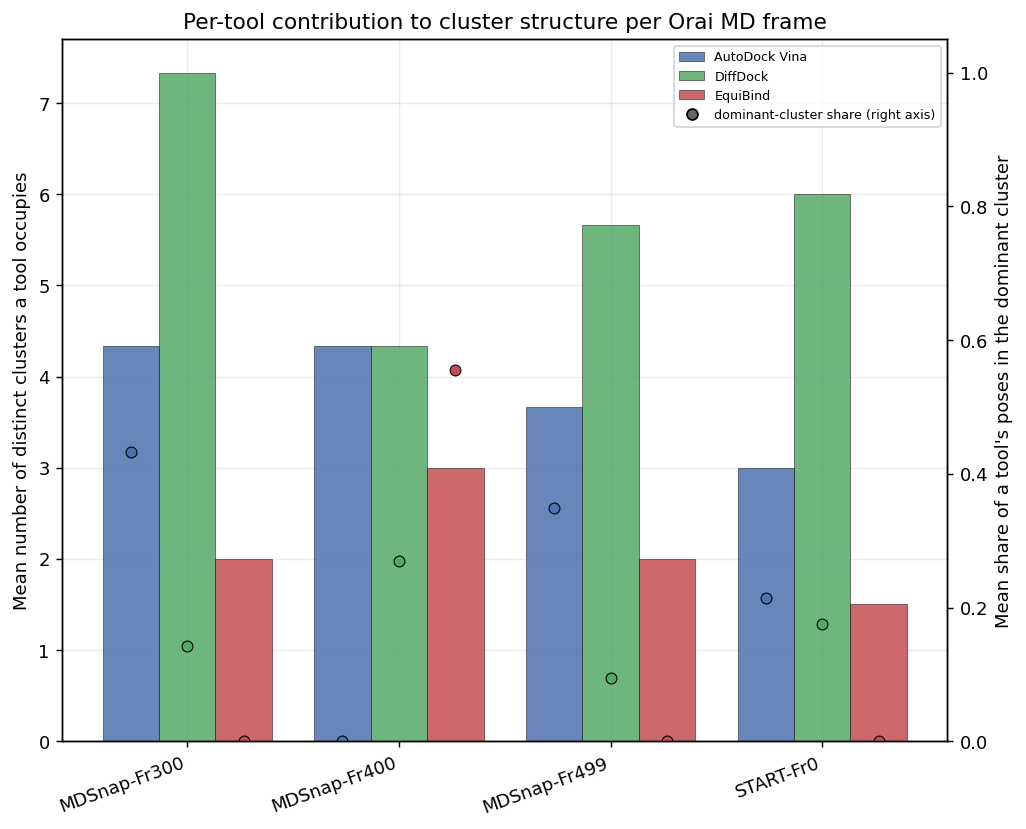

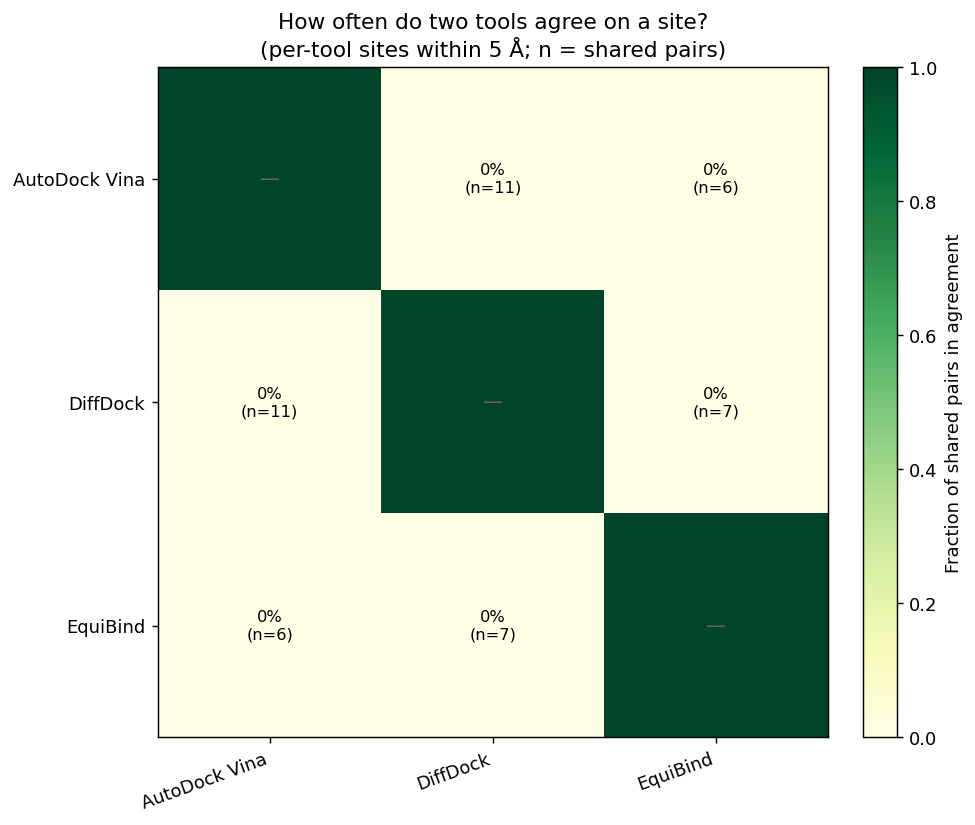

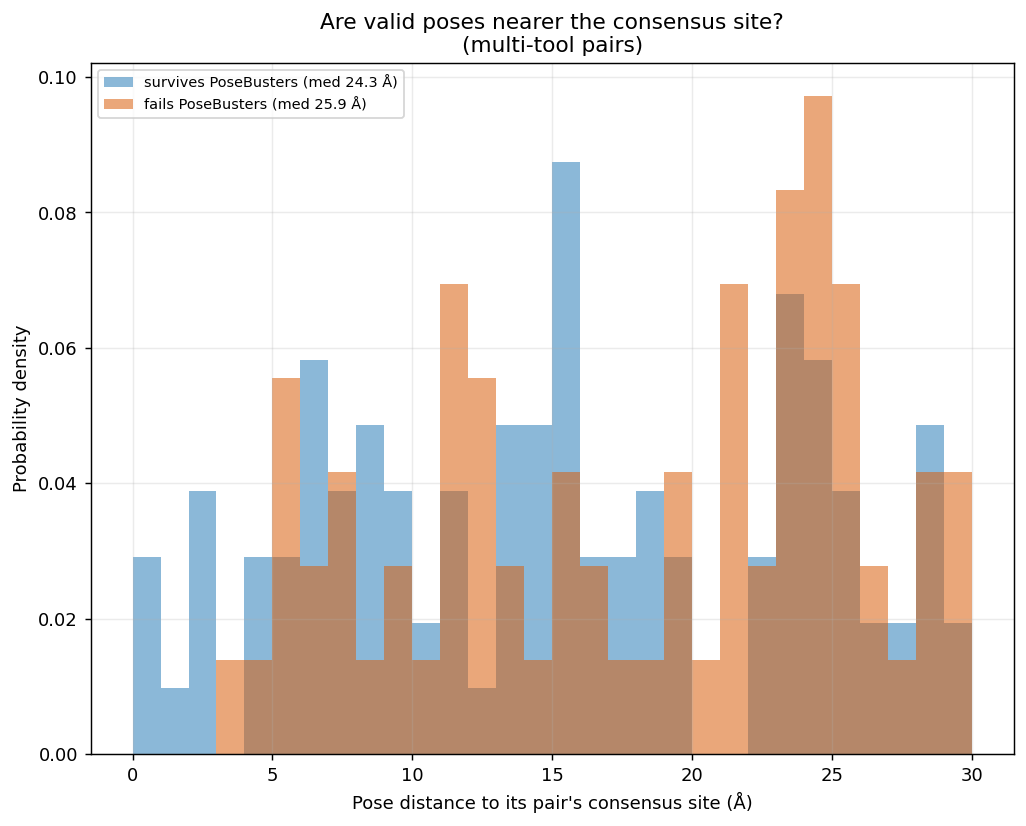

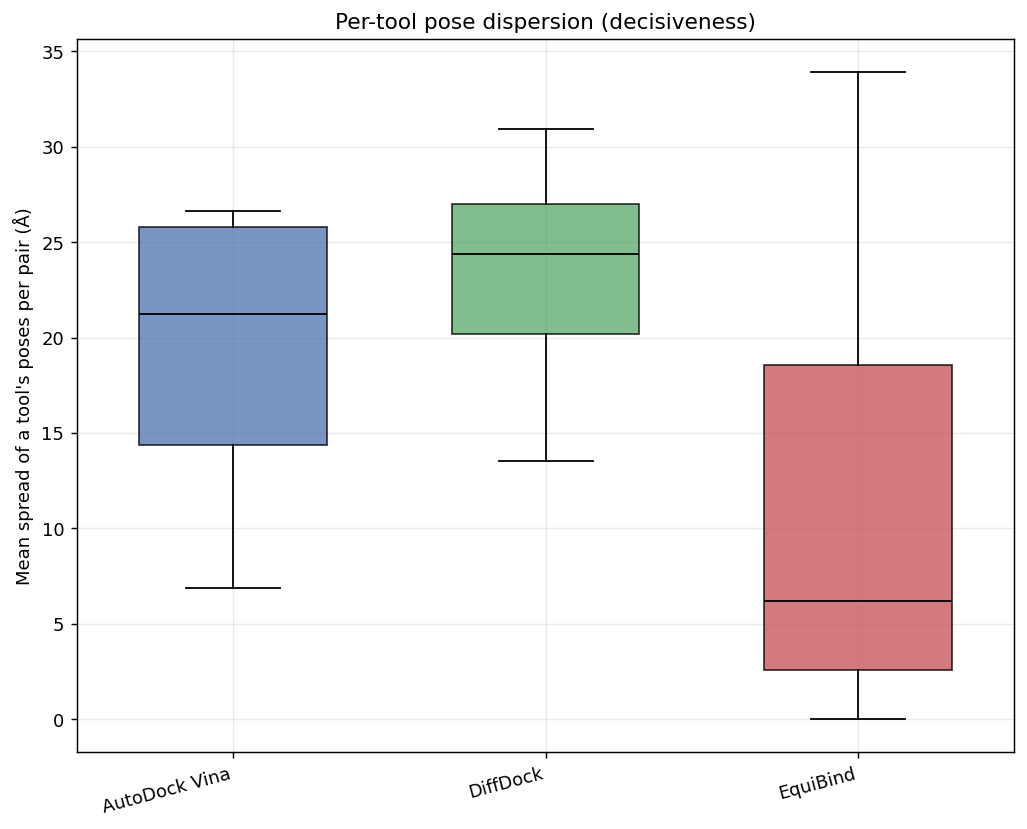

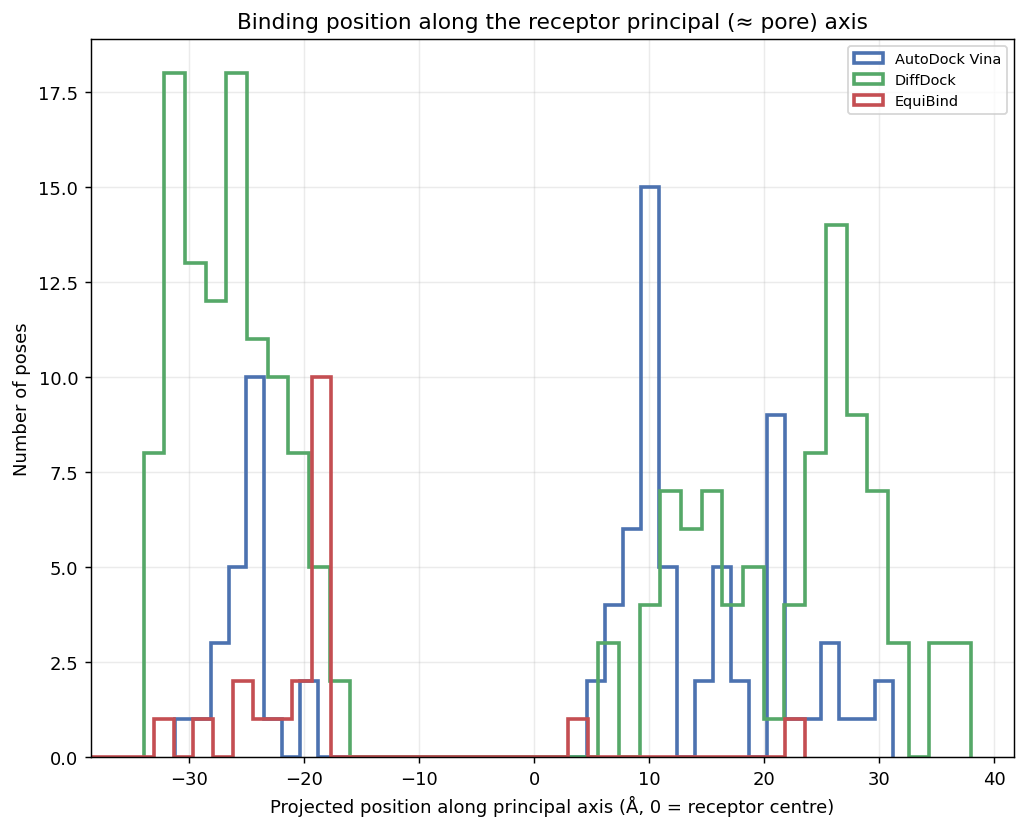

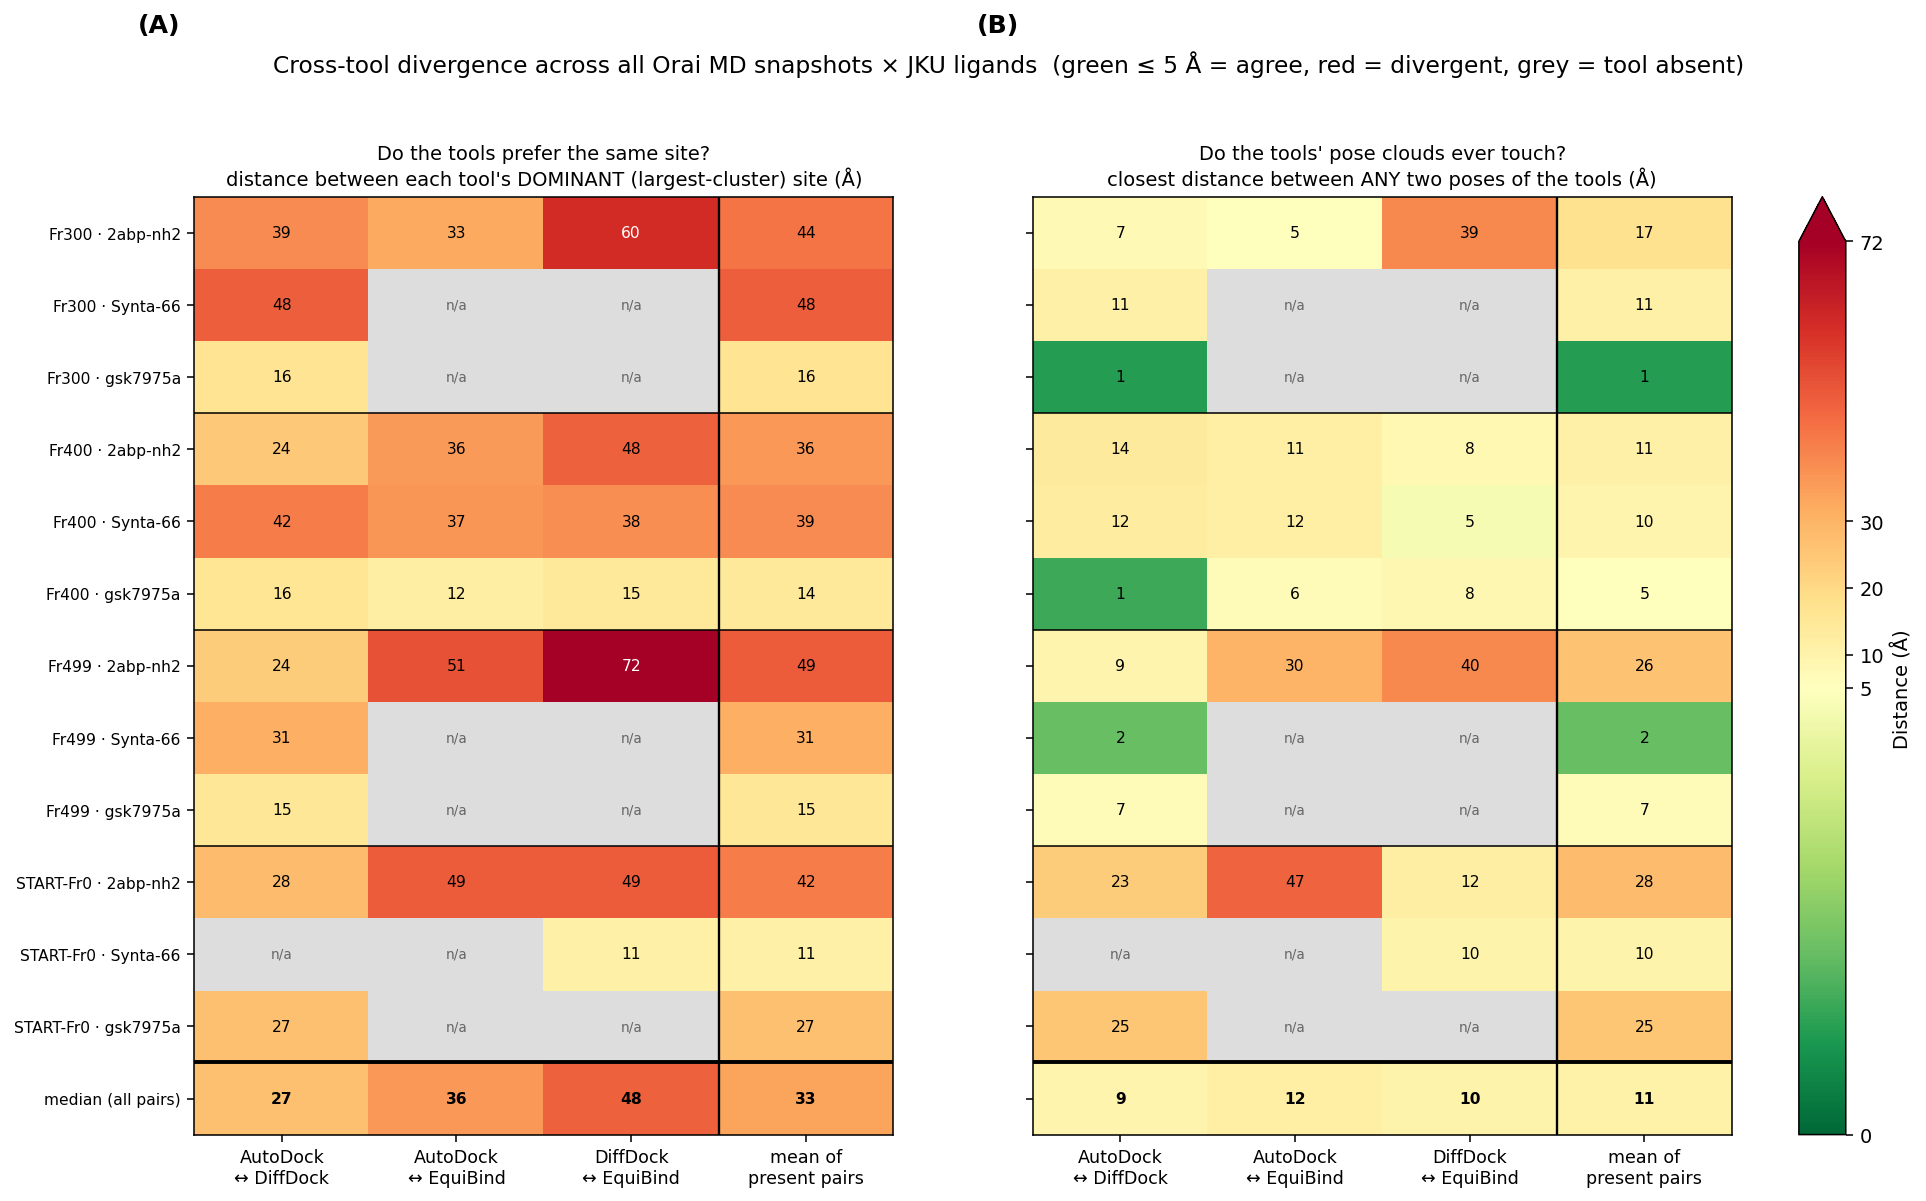

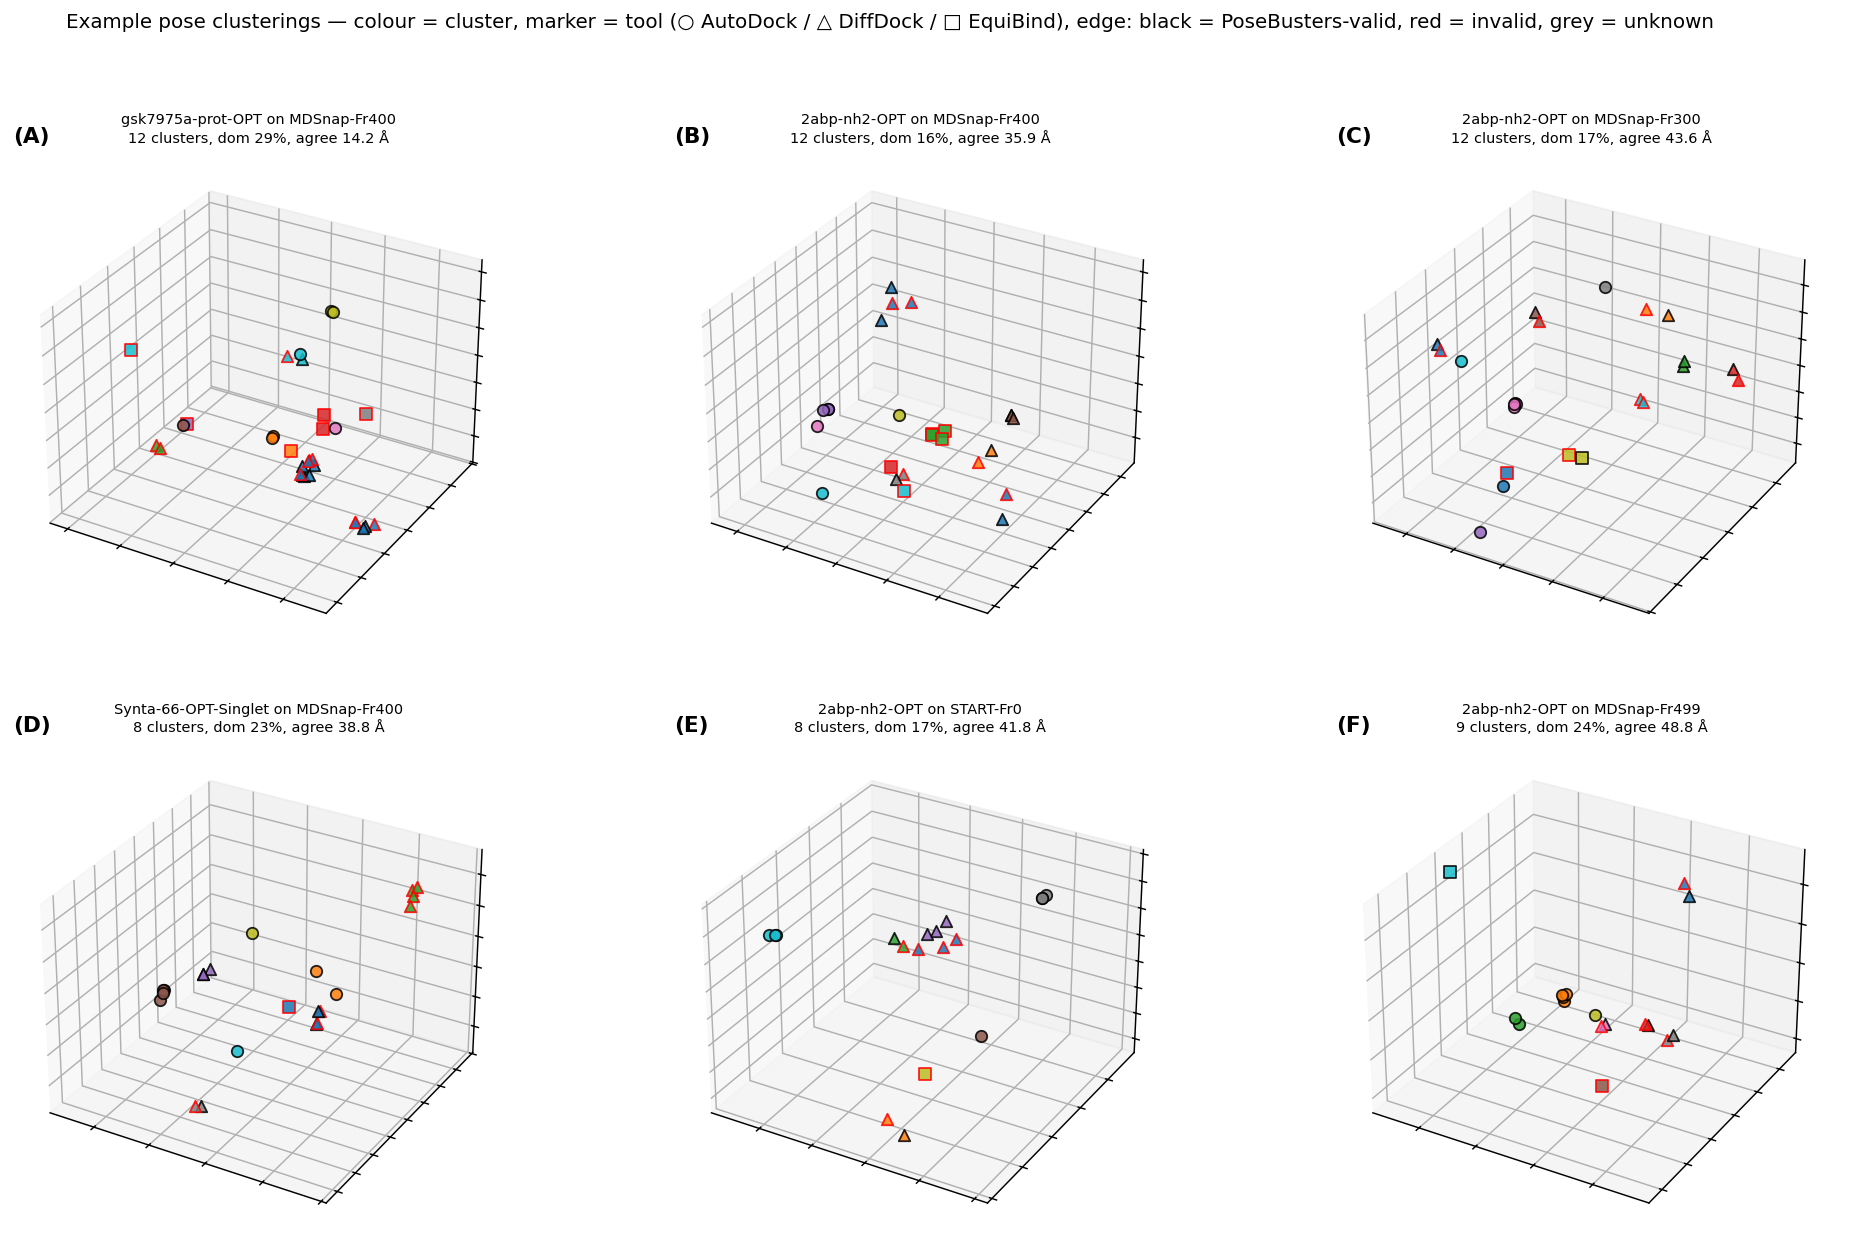

In [ ]:
# NOTE: reads the TRANSMEMBRANE-EXCLUDED pose set (…no_tm.csv) built by the TM-exclusion cell above.
import subprocess
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

VINA_PY = "/home/manndo/anaconda3/envs/vina/bin/python"   # rdkit/sklearn/scipy/matplotlib in the vina env
OUT = "posebusters_results/orai_jku/pose_clusters"

# No crystal: the pair "consensus site" is the GEOMETRIC MEDIAN of the per-tool
# sites (throughput-invariant), not the largest cluster; single-tool pairs fall
# back + are flagged. Clustering is the k=1-capable distance-threshold cut.
cmd = ["Scripts/Analysis/orai_pose_cluster_report.py",
       "--per-pose-csv", "posebusters_results/orai_jku/dock/posebusters_filtered_results.no_tm.csv",
       "--ids-file", "",                       # JKU ligands are not the 308 benchmark set
       "--site-cluster", "threshold", "--pocket-radius", "8.0",
       "--diffdock-variant", "gnina",
       "--out-dir", OUT]
print(f"=== {Path(cmd[0]).name} (Orai \u00d7 JKU) ===")
proc = subprocess.run([VINA_PY, *cmd])
if proc.returncode != 0:
    print(f"WARN {cmd[0]} exited with code {proc.returncode} - continuing notebook.")

out = Path(OUT)
pp = out / "per_pair.csv"
if pp.exists():
    d = pd.read_csv(pp)
    if "consensus_source" in d:
        print("\nConsensus reference per pair:", d["consensus_source"].value_counts().to_dict(),
              "(tool_median = throughput-robust; single_tool = fallback)")
# Individual (split-out) panels: the 8-panel overview is still written whole as
# orai_pose_cluster_overview.png, but every graph is now ALSO its own PNG under
# panels/ (now including the per-tool cluster-contribution graph and the
# tool-agreement matrix). Display them one-by-one, then the 3D examples.
panel_order = [
    "cross_tool_agreement", "pb_validity_per_frame", "cluster_structure",
    "tool_cluster_contribution", "tool_agreement_matrix",
    "valid_vs_consensus", "tool_dispersion", "axis_depth",
]
for name in panel_order:
    p = out / "panels" / f"orai_{name}.png"
    if p.exists():
        display(Image(filename=str(p)))
# Full divergence matrix over every MD-snapshot x ligand x tool-pair: (A) distance
# between each tool's DOMINANT site, (B) closest distance between ANY two poses
# (cloud overlap). All-red (A) + partly-green (B) = tools graze but never prefer
# the same site.
p = out / "orai_tool_divergence_matrix.png"
if p.exists():
    display(Image(filename=str(p)))
p = out / "orai_example_clusters.png"
if p.exists():
    display(Image(filename=str(p)))

In [ ]:
de

NameError: name 'de' is not defined

# Orai x Benchmark Section

## Orai × PoseBuster Benchmark Ligands || AutoDock Vina (batched)

Docks every Orai receptor in `Data/Receptors/*.pdb` against every ligand
(`*_ligand_start_conf.sdf`) in `Data/PoseBuster Benchmark Set/`,
running 50 ligands per Vina invocation per receptor.

Ligands are restricted to the official benchmark ID list
(`posebusters_pdb_ccd_ids.txt`, 308 ids); on-disk complexes not in the list are skipped.

In [ ]:
import yaml, json, shutil
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))

from Scripts.Docking.run_autodock import (
    run_autodock_vina, build_prepared_manifest, generate_summary,
    get_cpu_model, collect_files, get_pdbqt_dir, DockingResult,
)
from Scripts.Utilities.prep_docking import run_workflow

# ── Paths ────────────────────────────────────────────────────────────────────
benchmark_dir = Path("Data/PoseBuster Benchmark Set")
receptors_dir = Path(receptor_folder)                       # Data/Receptors
output_base   = Path("Dockings/Orai_Benchmark")
log_dir       = Path("Dockings/Logs/orai_benchmark_logs")
config_path   = Path("Scripts/Docking/orai_benchmark_autodock_config.yaml")
staging_root  = output_base / "_staging"
lig_staging   = staging_root / "ligands"
rec_staging   = staging_root / "receptors"

# ── Load + freeze the on-disk config (do not overwrite output_dir to disk) ──
with open(config_path) as f:
    cfg = yaml.safe_load(f)

cfg["receptors_dir"] = str(rec_staging)
cfg["ligand_dirs"]   = [str(lig_staging)]
cfg["output_dir"]    = str(output_base)
cfg["log_dir"]       = str(log_dir)
cfg["batch_mode"]    = True
cfg["batch_size"]    = 50

output_base.mkdir(parents=True, exist_ok=True)
log_dir.mkdir(parents=True, exist_ok=True)
lig_staging.mkdir(parents=True, exist_ok=True)
rec_staging.mkdir(parents=True, exist_ok=True)

cpu_model = get_cpu_model()
print(f"CPU: {cpu_model}")

# ── Stage receptors (symlink the 4 Orai PDBs into staging) ──────────────────
receptor_pdbs = sorted(p for p in receptors_dir.glob("*.pdb") if p.is_file())
if not receptor_pdbs:
    raise FileNotFoundError(f"No receptor PDBs found in {receptors_dir}")
for r in receptor_pdbs:
    link = rec_staging / r.name
    if not link.exists():
        link.symlink_to(r.resolve())
print(f"Receptors staged: {len(receptor_pdbs)}")
for r in receptor_pdbs:
    print(f"  • {r.name}")

# ── Stage benchmark ligands (symlink every *_ligand_start_conf.sdf) ─────────
# Restrict to the official PoseBusters benchmark ID list.
benchmark_ids_file = Path("Data/PoseBuster Benchmark Set/posebusters_pdb_ccd_ids.txt")
allowed_ids = {
    ln.strip() for ln in benchmark_ids_file.read_text().splitlines()
    if ln.strip() and not ln.lstrip().startswith("#")
}
print(f"Benchmark ID restriction: {len(allowed_ids)} ids from {benchmark_ids_file.name}")

complex_dirs = sorted(
    d for d in benchmark_dir.iterdir()
    if d.is_dir() and not d.name.startswith(("_", ".")) and d.name in allowed_ids
)
# Exactly the in-list ligand filenames we want staged.
wanted = {f"{d.name}_ligand_start_conf.sdf" for d in complex_dirs
          if (d / f"{d.name}_ligand_start_conf.sdf").exists()}

# Staging is append-only, so PRUNE any stale/off-list symlink first — otherwise a
# previous unrestricted run leaves extra ligands that AutoDock would still re-dock.
n_pruned = 0
for f in lig_staging.glob("*.sdf"):
    if f.name not in wanted:
        f.unlink()                       # removes only the symlink, not the source SDF
        n_pruned += 1

n_staged, n_missing = 0, 0
for cdir in complex_dirs:
    lig = cdir / f"{cdir.name}_ligand_start_conf.sdf"
    if not lig.exists():
        n_missing += 1
        continue
    link = lig_staging / lig.name
    if not link.exists():
        link.symlink_to(lig.resolve())
    n_staged += 1
print(f"\nBenchmark ligands staged: {n_staged}  (pruned stale: {n_pruned}, missing: {n_missing})")
assert n_staged == len(wanted) and not [f for f in lig_staging.glob("*.sdf") if f.name not in wanted], \
    "ligand staging does not mirror the allowed 308 set"

# ── Prepare receptors → PDBQT + auto-generated whole-protein boxes ──────────
print(f"\n{'─' * 60}\nPreparing receptors (PDB → PDBQT + box)\n{'─' * 60}")
protein_pdbqt_dir = get_pdbqt_dir(rec_staging)
protein_outputs = run_workflow(
    input_dir=rec_staging,
    contains="proteins",
    output_dir=protein_pdbqt_dir,
    skip_pdb_validation=cfg.get("skip_pdb_validation", False),
    process_postfixes=cfg.get("process_postfixes", False),
    repair_terminals=cfg.get("repair_terminals", False),
    converter=cfg.get("prep_tool", "meeko"),
    convert_proteins=True,
    verbose=False,
)

# ── Prepare ligands → PDBQT (Meeko) ─────────────────────────────────────────
print(f"\n{'─' * 60}\nPreparing ligands (SDF → PDBQT via Meeko)\n{'─' * 60}")
ligand_pdbqt_dir = get_pdbqt_dir(lig_staging)
ligand_outputs = run_workflow(
    input_dir=lig_staging,
    contains="ligands",
    output_dir=ligand_pdbqt_dir,
    process_postfixes=False,
    convert_ligands_with_meeko=True,
    verbose=False,
)

# ── Build manifest ──────────────────────────────────────────────────────────
manifest = build_prepared_manifest(protein_outputs, ligand_outputs)
n_prot = len(manifest["proteins"])
n_lig  = len(manifest["ligands"])
print(f"\nManifest: {n_prot} prepared protein entries  |  {n_lig} prepared ligand entries")

if n_prot == 0 or n_lig == 0:
    raise RuntimeError("Empty manifest — preparation failed for proteins or ligands.")

# ── Run AutoDock Vina (batched: 50 ligands per Vina call per receptor) ──────
print(f"\n{'═' * 60}")
print(f"Docking {len(receptor_pdbs)} receptors × {n_staged} ligands "
      f"(batch_size={cfg['batch_size']})")
print(f"{'═' * 60}")

results_df, results = run_autodock_vina(
    base_dir=output_base,
    log_dir=log_dir,
    prepared_manifest=manifest,
    cfg=cfg,
    cpu_model=cpu_model,
    protein_workflow_data=protein_outputs,
    ligand_workflow_data=ligand_outputs,
)

# ── Per-receptor summaries ──────────────────────────────────────────────────
summary = generate_summary(results, cfg)
with open(output_base / "docking_summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)

n_ok   = sum(1 for r in results if r.status == "success")
n_fail = sum(1 for r in results if r.status == "failed")
n_skip = sum(1 for r in results if r.status == "skipped")

print(f"\n{'=' * 60}")
print(f"ORAI × BENCHMARK DOCKING COMPLETE")
print(f"  Receptors:    {len(receptor_pdbs)}")
print(f"  Ligands:      {n_staged}")
print(f"  Combinations: {len(results)}")
print(f"  Success:      {n_ok}")
print(f"  Failed:       {n_fail}")
print(f"  Skipped:      {n_skip}")
print(f"  Results dir:  {output_base}")
print(f"  Summary:      {output_base / 'docking_summary.json'}")
print(f"{'=' * 60}")

CPU: Intel(R) Core(TM) i9-14900HX
Receptors staged: 4
  • Orai1WT-MDSnap-Fr300.pdb
  • Orai1WT-MDSnap-Fr400.pdb
  • Orai1WT-MDSnap-Fr499.pdb
  • Orai1WT-START-Fr0.pdb
Benchmark ID restriction: 308 ids from posebusters_pdb_ccd_ids.txt



Benchmark ligands staged: 308  (pruned stale: 0, missing: 0)

────────────────────────────────────────────────────────────
Preparing receptors (PDB → PDBQT + box)
────────────────────────────────────────────────────────────

PROCESSING 4 PROTEIN STRUCTURE(S)

────────────────────────────────────────────────────────────
Preparing ligands (SDF → PDBQT via Meeko)
────────────────────────────────────────────────────────────

Manifest: 12 prepared protein entries  |  616 prepared ligand entries

════════════════════════════════════════════════════════════
Docking 4 receptors × 308 ligands (batch_size=50)
════════════════════════════════════════════════════════════
Docking receptors: 4 | ligands: 308 | scoring: vina
Batch mode: ON (4 receptor(s), 308 ligands per Vina invocation)
Docking log: /home/manndo/master_dev/Dockings/Orai_Benchmark/docking_log_Orai_Benchmark.csv (1232 existing entries)
Total docking jobs: 1232  |  Workers: 1
  Receptor 1/4: Orai1WT-MDSnap-Fr300 — batch docking 308 li

## Orai × PoseBuster Benchmark Ligands || DiffDock

Docks every Orai receptor in `Data/Receptors/*.pdb` (top level only) against
every ligand in `Data/Ligands/PoseBuster_Benchmark_Set/*.sdf` using DiffDock
in CSV-batch mode. Ligands are restricted to the official benchmark ID list
(`posebusters_pdb_ccd_ids.txt`, 308 ids).

In [ ]:
import yaml, json
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))

from Scripts.Docking.run_diffdock import (
    run_diffdock, generate_summary, get_gpu_model, DockingResult,
)

# ── Paths ────────────────────────────────────────────────────────────────────
receptors_dir = Path("Data/Receptors")
ligands_dir   = Path("Data/Ligands/PoseBuster_Benchmark_Set")
output_base   = Path("Dockings/Orai_Benchmark_DiffDock")
log_dir       = Path("Dockings/Logs/orai_benchmark_diffdock_logs")
config_path   = Path("Scripts/Docking/diffdock_docking_config.yaml")

# ── Load DiffDock config and force batch mode ───────────────────────────────
with open(config_path) as f:
    dd_cfg = yaml.safe_load(f)

dd_cfg["output_dir"]         = str(output_base)
dd_cfg["log_dir"]            = str(log_dir)
dd_cfg["batch_mode"]         = True
dd_cfg["batch_size"]         = dd_cfg.get("batch_size", 15)
dd_cfg["overwrite_existing"] = False

# ── Best variant from the Benchmark set: gnina-optimized poses ───────────────
# The benchmark pose-comparison (--best-diffdock-only, ranked by oracle RMSD<=2A)
# picked the gnina-refined variant as DiffDock's best (oracle RMSD<=2A 58.1% vs
# smina 57.1% / raw 50.2%; gnina also leads pose PB-validity). Override the YAML's
# optimization: all so this run post-optimizes each DiffDock pose with gnina only
# (optimized_gnina/), matching that single benchmark-best variant rather than the
# full raw/smina/gnina fan-out.
dd_cfg["optimization"] = "gnina"

output_base.mkdir(parents=True, exist_ok=True)
log_dir.mkdir(parents=True, exist_ok=True)

gpu_model = get_gpu_model()
print(f"GPU: {gpu_model}")

# ── Collect Orai receptors (top-level *.pdb only — no subfolders) ───────────
receptor_pdbs = sorted(p for p in receptors_dir.glob("*.pdb") if p.is_file())
if not receptor_pdbs:
    raise FileNotFoundError(f"No receptor PDBs found in {receptors_dir}")
print(f"\nReceptors ({len(receptor_pdbs)}):")
for r in receptor_pdbs:
    print(f"  • {r.name}")

# ── Collect benchmark ligands ───────────────────────────────────────────────
# Restrict to the official PoseBusters benchmark ID list.
benchmark_ids_file = Path("Data/PoseBuster Benchmark Set/posebusters_pdb_ccd_ids.txt")
allowed_ids = {
    ln.strip() for ln in benchmark_ids_file.read_text().splitlines()
    if ln.strip() and not ln.lstrip().startswith("#")
}
print(f"Benchmark ID restriction: {len(allowed_ids)} ids from {benchmark_ids_file.name}")
# Ligand file "<PDBID>_<LIG>_ligand_start_conf.sdf" -> id "<PDBID>_<LIG>".
ligand_sdfs = sorted(
    p for p in ligands_dir.glob("*.sdf")
    if p.is_file() and p.name.split("_ligand_start_conf")[0] in allowed_ids
)
if not ligand_sdfs:
    raise FileNotFoundError(f"No ligand SDFs found in {ligands_dir}")
print(f"\nLigands: {len(ligand_sdfs)}")

# ── Run DiffDock (one CSV-batch invocation handles all combinations) ────────
print(f"\n{'═' * 60}")
print(f"DiffDock: {len(receptor_pdbs)} receptors × {len(ligand_sdfs)} ligands "
      f"= {len(receptor_pdbs) * len(ligand_sdfs)} combinations")
print(f"  batch_mode=True, batch_size={dd_cfg['batch_size']}")
print(f"{'═' * 60}\n")

results = run_diffdock(
    proteins=receptor_pdbs,
    ligands=ligand_sdfs,
    output_dir=output_base,
    cfg=dd_cfg,
    gpu_model=gpu_model,
)

# ── Save summary ────────────────────────────────────────────────────────────
summary = generate_summary(results, dd_cfg)
with open(output_base / "docking_summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)

n_ok   = sum(1 for r in results if r.status == "success")
n_fail = sum(1 for r in results if r.status == "failed")
n_skip = sum(1 for r in results if r.status == "skipped")

print(f"\n{'=' * 60}")
print(f"ORAI × BENCHMARK DIFFDOCK COMPLETE")
print(f"  Receptors:    {len(receptor_pdbs)}")
print(f"  Ligands:      {len(ligand_sdfs)}")
print(f"  Combinations: {len(results)}")
print(f"  Success:      {n_ok}")
print(f"  Failed:       {n_fail}")
print(f"  Skipped:      {n_skip}")
print(f"  Results dir:  {output_base}")
print(f"  Summary:      {output_base / 'docking_summary.json'}")
print(f"{'=' * 60}")

GPU: NVIDIA GeForce RTX 4070 Laptop GPU

Receptors (4):
  • Orai1WT-MDSnap-Fr300.pdb
  • Orai1WT-MDSnap-Fr400.pdb
  • Orai1WT-MDSnap-Fr499.pdb
  • Orai1WT-START-Fr0.pdb
Benchmark ID restriction: 308 ids from posebusters_pdb_ccd_ids.txt

Ligands: 308

════════════════════════════════════════════════════════════
DiffDock: 4 receptors × 308 ligands = 1232 combinations
  batch_mode=True, batch_size=15
════════════════════════════════════════════════════════════

DiffDock Docking
Mode: CSV batch (group-by-receptor)
Output directory: Dockings/Orai_Benchmark_DiffDock
Proteins: 4  |  Ligands: 308  |  Total: 1232
Previously failed (will skip): 43
Samples: 10  |  Steps: 20  |  Timeout: 600s

Previously failed (from failed_docking.json):
  ✗ 7AN5_RDH_start_conf__Orai1WT-MDSnap-Fr499: No poses from batch. stderr tail: __Orai1WT-MDSnap-Fr499'] Batch 1 Inference Ite
  ✗ 7C6P_SQH_start_conf__Orai1WT-MDSnap-Fr400: No poses from batch. stderr tail: ailed
[2026-Jun-15 23:51:49 CEST] WARNING -Com
  ✗ 7C6

## Orai × PoseBuster Benchmark Ligands || EquiBind (batch)

Docks every benchmark ligand in the official ID list (`posebusters_pdb_ccd_ids.txt`,
308 ids; `*_ligand_start_conf.sdf`) against every Orai
receptor (`Orai*_cleaned.pdb`) using `run_equibind.py` in a single batch
invocation. Uses pre-computed fpocket + p2rank pockets for guided docking.


In [ ]:
import os, sys, json, subprocess, yaml
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))

# ── Config is the SINGLE SOURCE OF TRUTH ─────────────────────────────────────
# run_equibind.py reads ONLY EQ_* env vars (it never reads the YAML), so this
# cell's sole job is to load the YAML and forward every key to its EQ_* var.
# There are NO silent fallbacks: cfg_req() raises on a missing key, so the YAML
# is unambiguously authoritative. Only run-specific orchestration (the ligand
# source + the staging dirs this cell creates) lives here in code.
config_path        = Path("Scripts/Docking/equibind_orai_benchmark_config.yaml")
runner_script      = Path("Scripts/Docking/run_equibind.py")
benchmark_dir      = Path("Data/PoseBuster Benchmark Set")            # ligand source (YAML ligand_dirs is [])
benchmark_ids_file = Path("Data/PoseBuster Benchmark Set/posebusters_pdb_ccd_ids.txt")

with open(config_path) as f:
    eb_cfg = yaml.safe_load(f)

def cfg_req(key):
    """Required YAML key — fail loudly, no in-cell default. The YAML is the source of truth."""
    if key not in eb_cfg:
        raise KeyError(f"'{key}' missing from {config_path} — add it to the YAML (no in-cell defaults).")
    return eb_cfg[key]

# ── Paths / runtime, ALL sourced from the YAML ───────────────────────────────
output_base     = Path(cfg_req("output_dir"))
log_dir         = Path(cfg_req("log_dir"))
fpocket_dir     = Path(cfg_req("fpocket_results_dir"))               # source of *_cleaned.pdb
p2rank_dir      = Path(cfg_req("p2rank_results_dir"))
equibind_dir    = os.path.expanduser(cfg_req("equibind_dir"))
equibind_python = Path(cfg_req("equibind_python"))                  # EquiBind env Python (kernel lacks torch)
device          = cfg_req("device")
gpu_batch_size  = int(cfg_req("gpu_batch_size"))
receptor_filter = cfg_req("receptor_name_filter")                   # e.g. "_cleaned"
clamp_mode      = str(cfg_req("clamp_mode"))
refine_mode     = str(cfg_req("refine_mode"))
uff_vdw         = str(cfg_req("uff_vdw_thresh"))
smina_exe       = str(cfg_req("smina_executable")).strip()
gnina_exe       = str(cfg_req("gnina_executable")).strip()

if not equibind_python.exists():
    raise FileNotFoundError(f"EquiBind python not found: {equibind_python}")

staging_root = output_base / "_staging"
rec_staging  = staging_root / "receptors"
lig_staging  = staging_root / "ligands"
for d in (output_base, log_dir, rec_staging, lig_staging):
    d.mkdir(parents=True, exist_ok=True)

print(f"EquiBind dir:    {equibind_dir}")
print(f"EquiBind python: {equibind_python}")
print(f"Device:          {device}")
print(f"GPU batch size:  {gpu_batch_size}")
print(f"Clamp mode:      {clamp_mode}")
print(f"Refine mode:     {refine_mode}  (tool={cfg_req('refine_tool')}/{cfg_req('smina_search')})")
print(f"UFF vdw thresh:  {uff_vdw}")

# ── Stage receptors ──────────────────────────────────────────────────────────
# Use the Orai *<filter>.pdb files in fpocket_results so the protein name matches
# the pocket filenames (fpocket: <stem>_out/, p2rank: <stem>.pdb_predictions.csv).
receptor_pdbs = sorted(p for p in fpocket_dir.glob(f"Orai*{receptor_filter}.pdb") if p.is_file())
if not receptor_pdbs:
    raise FileNotFoundError(f"No Orai *{receptor_filter}.pdb receptors found in {fpocket_dir}")
for r in receptor_pdbs:
    link = rec_staging / r.name
    if not link.exists():
        link.symlink_to(r.resolve())
print(f"\nReceptors staged: {len(receptor_pdbs)}")
for r in receptor_pdbs:
    print(f"  • {r.name}")

# Sanity-check pockets exist for each receptor
missing_pockets = []
for r in receptor_pdbs:
    stem = r.stem  # e.g. "Orai1WT-MDSnap-Fr300_cleaned"
    fp_ok = (fpocket_dir / f"{stem}_out").is_dir()
    p2_ok = any(p2rank_dir.glob(f"{stem}*_predictions.csv"))
    if not (fp_ok and p2_ok):
        missing_pockets.append((r.name, fp_ok, p2_ok))
if missing_pockets:
    print("\n⚠ Receptors with missing pockets (fpocket, p2rank):")
    for name, fp, p2 in missing_pockets:
        print(f"  • {name}: fpocket={fp} p2rank={p2}")

# ── Stage benchmark ligands (symlink every *_ligand_start_conf.sdf) ─────────
# Restrict to the official PoseBusters benchmark ID list.
allowed_ids = {
    ln.strip() for ln in benchmark_ids_file.read_text().splitlines()
    if ln.strip() and not ln.lstrip().startswith("#")
}
print(f"Benchmark ID restriction: {len(allowed_ids)} ids from {benchmark_ids_file.name}")

complex_dirs = sorted(
    d for d in benchmark_dir.iterdir()
    if d.is_dir() and not d.name.startswith(("_", ".")) and d.name in allowed_ids
)
n_staged, n_missing = 0, 0
for cdir in complex_dirs:
    lig = cdir / f"{cdir.name}_ligand_start_conf.sdf"
    if not lig.exists():
        n_missing += 1
        continue
    link = lig_staging / lig.name
    if not link.exists():
        link.symlink_to(lig.resolve())
    n_staged += 1
print(f"\nBenchmark ligands staged: {n_staged}  (missing: {n_missing})")

n_combos = len(receptor_pdbs) * n_staged
print(f"\n{'═' * 60}")
print(f"EquiBind: {len(receptor_pdbs)} receptors × {n_staged} ligands = {n_combos} combinations")
print(f"  GPU batch size: {gpu_batch_size}")
print(f"{'═' * 60}\n")

# ── Invoke run_equibind.py once (it iterates all receptor×ligand pairs) ─────
# Run-specific paths the cell creates are the only non-YAML values; everything
# else is forwarded verbatim from the YAML via cfg_req() (missing key -> raise).
env = os.environ.copy()
env.update({
    # run-specific (created/owned by this cell, intentionally not in the YAML)
    "EQ_RECEPTORS_DIR":   str(rec_staging.resolve()),
    "EQ_DRUGS_DIR":       str(lig_staging.resolve()),
    "EQ_OUTPUT_DIR":      str(output_base.resolve()),
    # everything below is forwarded from the YAML
    "EQ_RECEPTOR_FILTER": receptor_filter,
    "EQ_EQUIBIND_DIR":    equibind_dir,
    "EQ_DEVICE":          device,
    "EQ_GPU_BATCH_SIZE":  str(gpu_batch_size),
    "EQ_FPOCKET_DIR":     str(fpocket_dir.resolve()),
    "EQ_P2RANK_DIR":      str(p2rank_dir.resolve()),
    "EQ_CLAMP_MODE":         clamp_mode,
    "EQ_REFINE_MODE":        refine_mode,
    "EQ_REFINE_TOOL":        str(cfg_req("refine_tool")),
    "EQ_SMINA_SEARCH":       str(cfg_req("smina_search")),
    "EQ_SMINA_AUTOBOX_ADD":  str(cfg_req("smina_autobox_add")),
    "EQ_SMINA_CPU":          str(cfg_req("smina_cpu")),
    "EQ_SMINA_SEED":         str(cfg_req("smina_seed")),
    "EQ_SMINA_TIMEOUT":      str(cfg_req("smina_timeout_s")),
    "EQ_SMINA_RECEPTOR_EXT": str(cfg_req("smina_receptor_ext")),
    "EQ_GNINA_USE_GPU":     str(cfg_req("gnina_use_gpu")),
    "EQ_UFF_VDW_THRESH":     uff_vdw,
    "EQ_LIGAND_EXTENSIONS":      ",".join(cfg_req("ligand_extensions")),
    "EQ_N_TOP_POCKETS":          str(cfg_req("n_top_pockets")),
    "EQ_POSES_PER_POCKET":       str(cfg_req("poses_per_pocket")),
    "EQ_N_UNGUIDED_POSES":       str(cfg_req("n_unguided_poses")),
    "EQ_POCKET_MATCH_THRESHOLD": str(cfg_req("pocket_match_threshold")),
    "EQ_FORCE_POCKET":           str(cfg_req("force_pocket")),
    "EQ_CLAMP_POSE":             str(cfg_req("clamp_pose_to_pocket")),
    "EQ_USE_CROPPING":           str(cfg_req("use_protein_cropping")),
    "EQ_CROP_RADIUS":            str(cfg_req("pocket_crop_radius")),
    "EQ_CROP_BUFFER":            str(cfg_req("pocket_crop_buffer")),
    "EQ_CONFORMERS_PER_SEED":    str(cfg_req("conformers_per_seed")),
    "EQ_RDKIT_SEEDS":            ",".join(str(s) for s in cfg_req("rdkit_seeds")),
    "EQ_UFF_MINIMIZE":           str(cfg_req("uff_minimize")),
    "EQ_UFF_MAX_ITERS":          str(cfg_req("uff_max_iters")),
    "EQ_UFF_ENERGY_TOL":         str(cfg_req("uff_energy_tol")),
    "EQ_UFF_FORCE_TOL":          str(cfg_req("uff_force_tol")),
    "EQ_UFF_PROXIMITY_RADIUS":   str(cfg_req("uff_proximity_radius")),
    "EQ_UFF_ADD_H":              str(cfg_req("uff_add_hydrogens")),
    "EQ_UFF_STRIP_NONSTANDARD":  str(cfg_req("uff_strip_nonstandard")),
    "EQ_WORKERS":                str(cfg_req("n_parallel_workers") or os.cpu_count() or 8),
    "EQ_PARALLEL_CONFORMER_GEN": str(cfg_req("parallel_conformer_gen")),
    "EQ_SKIP_EXISTING":          str(cfg_req("skip_existing")),
})
if smina_exe:
    env["EQ_SMINA"] = smina_exe
if gnina_exe:
    env["EQ_GNINA"] = gnina_exe

log_file = log_dir / "orai_benchmark_equibind.log"
print(f"Logging to: {log_file}")
print(f"Output to:  {output_base}\n")

with open(log_file, "w") as lf:
    proc = subprocess.run(
        [str(equibind_python), str(runner_script.resolve())],
        env=env,
        cwd=str(Path.cwd()),
        stdout=lf,
        stderr=subprocess.STDOUT,
    )

# ── Report ──────────────────────────────────────────────────────────────────
summary_file = output_base / "pipeline_summary.json"
print(f"\n{'=' * 60}")
print(f"ORAI × BENCHMARK EQUIBIND COMPLETE")
print(f"{'=' * 60}")
print(f"  Return code:  {proc.returncode}")
print(f"  Log file:     {log_file}")
print(f"  Results dir:  {output_base}")

if proc.returncode == 0 and summary_file.exists():
    with open(summary_file) as f:
        s = json.load(f)
    totals = s.get("totals", {})
    timing = s.get("global_timing", {})
    print(f"  Poses ok:     {totals.get('poses_success', '?')}")
    print(f"  Poses failed: {totals.get('poses_failed', '?')}")
    print(f"  Wall time:    {timing.get('pipeline_wall_time_s', 0.0):.1f}s")
    print(f"  Summary:      {summary_file}")
else:
    print(f"  ✗ Failed — see log for details")
print(f"{'=' * 60}")

EquiBind dir:    /home/manndo/tools/EquiBind
EquiBind python: /home/manndo/anaconda3/envs/equibind/bin/python
Device:          cuda
GPU batch size:  8
Clamp mode:      off
Refine mode:     on  (tool=smina/local_only)
UFF vdw thresh:  10.0

Receptors staged: 4
  • Orai1WT-MDSnap-Fr300_cleaned.pdb
  • Orai1WT-MDSnap-Fr400_cleaned.pdb
  • Orai1WT-MDSnap-Fr499_cleaned.pdb
  • Orai1WT-START-Fr0_cleaned.pdb
Benchmark ID restriction: 308 ids from posebusters_pdb_ccd_ids.txt

Benchmark ligands staged: 308  (missing: 0)

════════════════════════════════════════════════════════════
EquiBind: 4 receptors × 308 ligands = 1232 combinations
  GPU batch size: 8
════════════════════════════════════════════════════════════

Logging to: Dockings/Logs/orai_benchmark_equibind_logs/orai_benchmark_equibind.log
Output to:  Dockings/Orai_Benchmark_Equibind



KeyboardInterrupt: 

## Orai × PoseBuster Benchmark Ligands || PoseBusters validation (AutoDock + DiffDock + EquiBind)

Runs PoseBusters (`config="dock"`) on every Orai-vs-benchmark-ligand pose produced by all three docking methods.

**Receptor variants** (from `Data/Receptors/`):
- `Orai1WT-START-Fr0`
- `Orai1WT-MDSnap-Fr300` / `Fr400` / `Fr499`

**Source layouts consumed** (no renaming needed — the existing folder/file names already match the
`<protein>__<ligand>` / `<ligand>__<protein>` conventions used by the registered collectors):

| Method   | Path                                   | Pattern                                                     |
|----------|----------------------------------------|-------------------------------------------------------------|
| AutoDock | `Dockings/Orai_Benchmark/docking/`     | `<receptor>__<ligand>_vina_out.pdbqt`                       |
| DiffDock | `Dockings/Orai_Benchmark_DiffDock/`    | `<ligand>_start_conf__<receptor>/rank*.sdf`                 |
| EquiBind | `Dockings/Orai_Benchmark_Equibind/`    | `<ligand>_ligand_start_conf__<receptor>_cleaned/*.sdf`      |

**Staging done by this cell** (idempotent symlinks):
1. `posebusters_results/_orai_benchmark_staging/receptors/` — the 4 Orai PDBs only (so receptor discovery does not pick up unrelated PDBs in `Data/Receptors/`).
2. `posebusters_results/_orai_benchmark_staging/ligand_templates/` — per-ligand SDFs renamed to match the AutoDock ligand label, used as bond-order templates during PDBQT→SDF conversion.

Outputs go to `posebusters_results/orai_benchmark/dock/` (CSVs, plots, and a `posebuster_proved/dock/` copy of all passing poses).

In [ ]:
import os, sys, shutil, subprocess
from pathlib import Path

# ── Paths ────────────────────────────────────────────────────────────────────
receptors_src    = Path("Data/Receptors")
benchmark_dir    = Path("Data/PoseBuster Benchmark Set")
autodock_dir     = Path("Dockings/Orai_Benchmark/docking")
diffdock_dir     = Path("Dockings/Orai_Benchmark_DiffDock")
equibind_dir     = Path("Dockings/Orai_Benchmark_Equibind")

pb_runner_script = Path("Scripts/Docking/Posebusters/run_posebusters.py")
# PoseBusters must run in the vina env — only its posebusters carries the
# energy_ratio crash-fix; the notebook kernel's package may be unpatched.
VINA_PY = "/home/manndo/anaconda3/envs/vina/bin/python"
pb_config_path   = Path("Scripts/Docking/Posebusters/posebusters_orai_benchmark_config.yaml")

staging_root     = Path("posebusters_results/_orai_benchmark_staging")
rec_staging      = staging_root / "receptors"
tpl_staging      = staging_root / "ligand_templates"
for d in (rec_staging, tpl_staging):
    d.mkdir(parents=True, exist_ok=True)

# Restrict to the four Orai receptor variants (matches receptor names embedded
# in every docking output filename).
ORAI_RECEPTORS = [
    "Orai1WT-START-Fr0",
    "Orai1WT-MDSnap-Fr300",
    "Orai1WT-MDSnap-Fr400",
    "Orai1WT-MDSnap-Fr499",
]


def _link(src: Path, dst: Path) -> bool:
    if not src.exists():
        return False
    if dst.is_symlink() or dst.exists():
        try:
            if dst.resolve() == src.resolve():
                return True
        except OSError:
            pass
        dst.unlink()
    try:
        dst.symlink_to(src.resolve())
    except OSError:
        shutil.copy2(src, dst)
    return True


# ── 1. Stage receptors ──────────────────────────────────────────────────────
n_rec = 0
missing_rec = []
for name in ORAI_RECEPTORS:
    src = receptors_src / f"{name}.pdb"
    if _link(src, rec_staging / f"{name}.pdb"):
        n_rec += 1
    else:
        missing_rec.append(name)


# ── 2. Stage ligand templates (per-ligand SDF aliases) ──────────────────────
# AutoDock ligand label after collector parsing is "<pdb_id>_ligand_start_conf_vina"
# (filename minus "_vina_out", split on "__"). The bond-order template lookup
# in run_posebusters.py uses glob "*<ligand_label>*.sdf", so we expose each
# benchmark SDF under a name that contains that exact substring.
# Restrict to the official PoseBusters benchmark ID list (matches the docking cells).
benchmark_ids_file = Path("Data/PoseBuster Benchmark Set/posebusters_pdb_ccd_ids.txt")
allowed_ids = {
    ln.strip() for ln in benchmark_ids_file.read_text().splitlines()
    if ln.strip() and not ln.lstrip().startswith("#")
}

n_tpl = 0
ligand_labels_seen = set()
if benchmark_dir.is_dir():
    for cdir in sorted(benchmark_dir.iterdir()):
        if not cdir.is_dir() or cdir.name.startswith(("_", ".")):
            continue
        pdb_id = cdir.name
        if pdb_id not in allowed_ids:
            continue
        sdf = cdir / f"{pdb_id}_ligand.sdf"
        if not sdf.exists():
            continue
        # Alias matching the AutoDock ligand label
        ad_label = f"{pdb_id}_ligand_start_conf_vina"
        if _link(sdf, tpl_staging / f"{ad_label}.sdf"):
            n_tpl += 1
            ligand_labels_seen.add(pdb_id)
        # Also expose the bare-id name (covers DiffDock / EquiBind label "<pdb_id>_(ligand_)?start_conf")
        _link(sdf, tpl_staging / f"{pdb_id}.sdf")


# ── 3. Quick sanity counts on the docking source folders ────────────────────
n_ad = sum(1 for _ in autodock_dir.glob("*_vina_out.pdbqt")) if autodock_dir.is_dir() else 0
n_dd = sum(
    1 for d in diffdock_dir.iterdir()
    if d.is_dir() and "__" in d.name and any(d.glob("**/*.sdf"))
) if diffdock_dir.is_dir() else 0
n_eb = sum(
    1 for d in equibind_dir.iterdir()
    if d.is_dir() and "__" in d.name
    and any(f for f in d.glob("**/*.sdf") if "prep" not in f.parts)
) if equibind_dir.is_dir() else 0

print("Staging summary")
print("─" * 60)
print(f"  receptors staged:   {n_rec:>5}  → {rec_staging}")
print(f"  ligand templates:   {n_tpl:>5}  → {tpl_staging}")
print(f"  AutoDock pose files (source): {n_ad:>5}  ({autodock_dir})")
print(f"  DiffDock pose dirs  (source): {n_dd:>5}  ({diffdock_dir})")
print(f"  EquiBind pose dirs  (source): {n_eb:>5}  ({equibind_dir})")
if missing_rec:
    print(f"\n⚠ Missing receptor PDB(s): {missing_rec}")

# ── 4. Sanity-check config + runner exist ───────────────────────────────────
if not pb_config_path.exists():
    raise FileNotFoundError(pb_config_path)
if not pb_runner_script.exists():
    raise FileNotFoundError(pb_runner_script)

# ── 5. Invoke run_posebusters.py with the Orai × Benchmark config ───────────
print(f"\n{'═' * 60}")
print(f"PoseBusters validation — Orai × PoseBuster Benchmark Set")
print(f"  config:  {pb_config_path}")
print(f"  runner:  {pb_runner_script}")
print(f"{'═' * 60}\n")

# ── Runtime knobs → run_posebusters.py CLI flags (each overrides the YAML
#    config; tune here without editing the config file) ──────────────────
PB_QUIET        = True    # silence RDKit/pandas warning flood + per-file listings
PB_MONITOR      = True    # live core/RAM/swap monitor + bottleneck flags
PB_MONITOR_INT  = 30      # seconds between monitor snapshots
PB_WORKERS      = None    # parallel workers; None = all CPUs. Lower (e.g. 12) if the
                          # run OOM-stalls or the monitor prints "SWAP GROWING".
PB_POSE_TIMEOUT = None    # per-pose wall-clock cap (s); None = config default (600)
PB_MAXTASKS     = None    # recycle each worker every N poses; None = config (200)
# stall_timeout / max_restarts (dead-worker auto-restart) live in the YAML config.

pb_cmd = [VINA_PY, str(pb_runner_script.resolve()),
          "--config", str(pb_config_path.resolve())]
if PB_QUIET:                    pb_cmd.append("--quiet")
if PB_MONITOR:                  pb_cmd.append("--monitor")
if PB_MONITOR_INT is not None:  pb_cmd += ["--monitor-interval", str(PB_MONITOR_INT)]
if PB_WORKERS is not None:      pb_cmd += ["--workers", str(PB_WORKERS)]
if PB_POSE_TIMEOUT is not None: pb_cmd += ["--pose-timeout", str(PB_POSE_TIMEOUT)]
if PB_MAXTASKS is not None:     pb_cmd += ["--max-tasks-per-child", str(PB_MAXTASKS)]
print(f"  flags:   {' '.join(pb_cmd[4:]) or '(none — using config defaults)'}")

env = os.environ.copy()
env["PYTHONUNBUFFERED"] = "1"

proc = subprocess.run(pb_cmd, cwd=str(Path.cwd()), env=env)

print(f"\n{'=' * 60}")
print(f"PoseBusters Orai × BENCHMARK COMPLETE  (return code: {proc.returncode})")
print(f"  Results: posebusters_results/orai_benchmark/dock/")
print(f"  Plots:   posebusters_results/orai_benchmark/dock/pb_*.png")
print(f"  Proved:  posebuster_proved/dock/")
print(f"{'=' * 60}")


Staging summary
────────────────────────────────────────────────────────────
  receptors staged:       4  → posebusters_results/_orai_benchmark_staging/receptors
  ligand templates:     308  → posebusters_results/_orai_benchmark_staging/ligand_templates
  AutoDock pose files (source):  1232  (Dockings/Orai_Benchmark/docking)
  DiffDock pose dirs  (source):  1669  (Dockings/Orai_Benchmark_DiffDock)
  EquiBind pose dirs  (source):  1232  (Dockings/Orai_Benchmark_Equibind)

════════════════════════════════════════════════════════════
PoseBusters validation — Orai × PoseBuster Benchmark Set
  config:  Scripts/Docking/Posebusters/posebusters_orai_benchmark_config.yaml
  runner:  Scripts/Docking/Posebusters/run_posebusters.py
════════════════════════════════════════════════════════════

  flags:   --quiet --monitor --monitor-interval 30

Total: 4 PDB files found in /home/manndo/master_dev/posebusters_results/_orai_benchmark_staging/receptors
DOCKING POSES OVERVIEW


  autodock: 1232 protein-

[21:13:01] WARNING: Ambiguous stereo: center(s)



  Processed 1/722  (overall 60004/4985)
  Processed 10/722  (overall 60013/4985)
  Processed 20/722  (overall 60023/4985)
  Processed 30/722  (overall 60033/4985)
  Processed 40/722  (overall 60043/4985)
  Processed 50/722  (overall 60053/4985)
  Processed 60/722  (overall 60063/4985)
  Processed 70/722  (overall 60073/4985)
  [MON t+30s] cores~0.0/32 (sys-CPU 0%)  load 8.3/32  RAM 25% (7.8G/31.2G)  swap 0.0G
             procs 34  threads 67  RSS 8.5G  main-CPU 4%  |  poses 721 (+721, 24.0/s)
             ⚠ UNDER-UTILISED: only ~0.0/32 cores busy — too few workers (num_workers 0/blank = all cores), a hang holding workers, or main-process/I/O serialisation
  [MON t+60s] cores~1.1/32 (sys-CPU 3%)  load 5.4/32  RAM 25% (7.9G/31.2G)  swap 0.0G
             procs 34  threads 67  RSS 8.5G  main-CPU 0%  |  poses 721 (+0, 0.0/s)
             ⚠ UNDER-UTILISED: only ~1.1/32 cores busy — too few workers (num_workers 0/blank = all cores), a hang holding workers, or main-process/I/O serialisation


In [ ]:
import pandas as pd
from pathlib import Path

# ── Inputs ──────────────────────────────────────────────────────────────────
RESULT_SETS = {
    "Benchmark (PDB-vs-PDB)":      Path("posebusters_results/benchmark/dock/posebusters_filtered_results.csv"),
    "Orai × PoseBuster Benchmark": Path("posebusters_results/orai_benchmark/dock/posebusters_filtered_results.csv"),
}

# Columns that are metadata or counters, not pass/fail tests
_METADATA = {
    "file_path", "filepath", "file", "path", "sdf_file", "sdf_path",
    "method", "docking_method", "protein", "ligand", "pose_rank", "rank",
    "molecule", "mol_name", "name", "complex", "protein_path", "ligand_path",
    "mol_pred", "mol_true", "mol_cond", "pose_file", "pose_name", "file_format",
    "protein_file_used", "posebusters_mode", "diffdock_confidence",
}
_EXCLUDE = {
    "mol_true_loaded", "mol_cond_loaded",
    "not_too_far_away_organic_cofactors",
    "not_too_far_away_inorganic_cofactors",
    "not_too_far_away_waters",
}
_BOOL_LIKE = frozenset({True, False, 1, 0, 1.0, 0.0,
                        "True", "False", "true", "false"})
_BOOL_MAP = {"True": True, "true": True, "False": False, "false": False}


def _identify_test_cols(df: pd.DataFrame) -> list[str]:
    """Return PoseBusters boolean test columns."""
    cols = []
    for c in df.columns:
        cl = c.lower().strip()
        if cl in _METADATA or c in _EXCLUDE or cl in _EXCLUDE:
            continue
        if cl.startswith("number_") or cl.startswith("num_"):
            continue
        u = set(df[c].dropna().unique())
        if u and u.issubset(_BOOL_LIKE):
            cols.append(c)
    return cols


def summarize(label: str, csv_path: Path) -> None:
    print("=" * 82)
    print(label)
    print("=" * 82)
    if not csv_path.exists():
        print(f"  ✗ CSV not found: {csv_path}")
        return

    df = pd.read_csv(csv_path, low_memory=False)
    test_cols = _identify_test_cols(df)
    for tc in test_cols:
        if df[tc].dtype == object:
            df[tc] = df[tc].map(_BOOL_MAP)
        df[tc] = df[tc].astype(bool)

    df["_n_failed"] = (~df[test_cols]).sum(axis=1)
    df["_all_pass"] = df["_n_failed"] == 0

    print(f"  source CSV:                 {csv_path}")
    print(f"  total poses analyzed:       {len(df):,}")
    print(f"  unique proteins:            {df['protein'].nunique()}")
    print(f"  unique ligands:             {df['ligand'].nunique()}")
    print(f"  unique protein-ligand pairs:{df.groupby(['protein','ligand']).ngroups:,}")
    print(f"  PoseBusters tests evaluated:{len(test_cols)}")

    # ── Per-method pose-level summary ───────────────────────────────────────
    per_method = df.groupby("docking_method").agg(
        poses=("docking_method", "size"),
        all_pass=("_all_pass", "sum"),
        avg_failed=("_n_failed", "mean"),
    )
    per_method["pass_rate_%"] = (per_method["all_pass"] / per_method["poses"] * 100).round(1)
    per_method["avg_failed"]  = per_method["avg_failed"].round(2)
    print("\n  Per-method pose-level pass rates:")
    print(per_method[["poses", "all_pass", "pass_rate_%", "avg_failed"]].to_string())

    # ── Per-method "at least one valid pose per pair" ───────────────────────
    best = df.loc[df.groupby(["docking_method", "protein", "ligand"])["_n_failed"].idxmin()]
    pair_summary = best.groupby("docking_method").agg(
        pairs=("protein", "size"),
        any_valid=("_all_pass", "sum"),
    )
    pair_summary["valid_pair_rate_%"] = (pair_summary["any_valid"] / pair_summary["pairs"] * 100).round(1)
    print("\n  Per-method 'at least one valid pose per pair':")
    print(pair_summary.to_string())

    # ── Top failing tests ───────────────────────────────────────────────────
    fail_rates = (~df[test_cols]).mean().sort_values(ascending=False) * 100
    print("\n  Top 10 most-failed tests (overall %):")
    for c, v in fail_rates.head(10).items():
        print(f"    {c:50s} {v:5.1f}%")
    print()


for label, path in RESULT_SETS.items():
    summarize(label, path)

Benchmark (PDB-vs-PDB)
  source CSV:                 posebusters_results/benchmark/dock/posebusters_filtered_results.csv
  total poses analyzed:       114,813
  unique proteins:            303
  unique ligands:             303
  unique protein-ligand pairs:303
  PoseBusters tests evaluated:28

  Per-method pose-level pass rates:
                 poses  all_pass  pass_rate_%  avg_failed
docking_method                                           
autodock          7407      6744         91.0        0.16
diffdock         27302     16351         59.9        0.90
equibind_guided  80104     17650         22.0        1.86

  Per-method 'at least one valid pose per pair':
                 pairs  any_valid  valid_pair_rate_%
docking_method                                      
autodock           303        293               96.7
diffdock           303        301               99.3
equibind_guided    303        299               98.7

  Top 10 most-failed tests (overall %):
    minimum_distance_to

## Orai × PoseBuster Benchmark Ligands || Validity report + PandaMap

Deeper PoseBusters validity plots and PandaMap interaction analysis for the
Orai × Benchmark-ligands poses produced above. No crystal reference exists for
Orai, so PandaMap runs without native-interaction recovery and `--best-equibind-only`
does not apply (all EquiBind variants are shown).

In [ ]:
# Orai × Benchmark validity report — keep only the benchmark-best variant per tool.
# Orai receptors have no crystal, so variants can't be ranked by oracle RMSD
# (--best-diffdock-only / --best-equibind-only need one). Instead we name the best
# variant explicitly via the crystal-free selectors: DiffDock = gnina, EquiBind =
# unguided + gnina (the variant these Orai runs now dock with). Set either to None
# to show every variant split out instead.
#
# NOTE: the gnina EquiBind poses exist only after the Orai×Benchmark EquiBind cell
# (now refine_tool: gnina) + PoseBusters are re-run. Until then the CSV holds
# unguided+smina, so "unguided_gnina" warns and falls back to smina; switch
# EQUIBIND_VARIANT to "unguided_smina" to collapse the currently-docked data.
DIFFDOCK_VARIANT = "gnina"           # raw | smina | gnina | None
EQUIBIND_VARIANT = "unguided_gnina"  # unguided_gnina | unguided_smina | None

# COLLAPSE_PLOTS_ONLY: keep EVERY variant in the CSV tables + printed summary while the
# FIGURES show only the pinned variant above (as DiffDock*/EquiBind*) — the
# "all variants in the table, one variant in the graph" mode. False → filter both
# (previous behaviour). Per-tool variant-comparison figs (06/07) and the per-variant
# check_failure_rates_per_variant.csv table are written either way.
COLLAPSE_PLOTS_ONLY = False

_dd = f" --diffdock-variant {DIFFDOCK_VARIANT}" if DIFFDOCK_VARIANT else ""
_eq = f" --equibind-variant {EQUIBIND_VARIANT}" if EQUIBIND_VARIANT else ""
_collapse = " --collapse-plots-only" if COLLAPSE_PLOTS_ONLY else ""

get_ipython().run_line_magic(
    "run",
    "Scripts/Analysis/posebusters_validity_report.py"
    " --csv posebusters_results/orai_benchmark/dock/posebusters_filtered_results.csv"
    " --out-dir posebusters_results/orai_benchmark/dock/validity_report"
    + _collapse
    + _dd
    + _eq)

diffdock-variant: keeping only 'diffdock_gnina' (shown as 'DiffDock*').
equibind-variant: keeping only 'equibind_unguided_gnina' (shown as 'EquiBind*').
  [rmsd≤2] no pose within 2 Å of the crystal — omitting rmsd2_* summary columns.
failure waterfall: top variant per tool = autodock, diffdock_gnina, equibind_unguided_gnina
Total poses scored        : 26,054
Total PB-valid poses      : 20,747 (79.63%)
Receptor-ligand pairs     : 1202
Methods / variants found  : 3 (autodock, diffdock_gnina, equibind_unguided_gnina)

── Per-method summary (all variants) ─────────────
                         total_poses  valid_poses  valid_fraction
docking_method                                                   
autodock                       12020        10827           0.901
diffdock_gnina                 11546         9899           0.857
equibind_unguided_gnina         2488           21           0.008

── PB check failure rate (%) per variant (n_poses, survival %, then worst checks) ──
            

In [ ]:
import subprocess

VINA_PY = "/home/manndo/anaconda3/envs/vina/bin/python"  # pandamap lives only in the vina env
CFG = "Scripts/Analysis/pandamap_orai_benchmark_config.yaml"

for script in ("run_pandamap.py", "pandamap_interaction_report.py"):
    print(f"\n▶ {script}")
    proc = subprocess.run([VINA_PY, f"Scripts/Analysis/{script}", "--config", CFG, "--diffdock-variant", "gnina"])
    if proc.returncode != 0:
        print(f"⚠ {script} exited with code {proc.returncode} — continuing notebook.")


▶ run_pandamap.py
PandaMap interaction generator
  input   : PB CSV /home/manndo/master_dev/posebusters_results/orai_benchmark/dock/posebusters_filtered_results.csv
  output  : /home/manndo/master_dev/pandamap_results/orai_benchmark
  top-N   : 3 per method×pair   pb_valid_only=True
  crystal : (none)
Collected 36292 poses; methods: ['autodock', 'diffdock', 'diffdock_gnina', 'diffdock_smina', 'equibind_guided', 'equibind_unguided', 'equibind_unguided_smina']
Selected 14228 poses across 1202 pairs (7 methods)
Resume: 13303 already done, 925 to do

Docked poses: 925 poses on 31 workers (render=True)
  [50/925] done  (ok=6 err=44)
  [100/925] done  (ok=56 err=44)
  [150/925] done  (ok=105 err=45)
  [200/925] done  (ok=155 err=45)
  [250/925] done  (ok=205 err=45)
  [300/925] done  (ok=255 err=45)
  [350/925] done  (ok=305 err=45)
  [400/925] done  (ok=355 err=45)
  [450/925] done  (ok=405 err=45)
  [500/925] done  (ok=455 err=45)
  [550/925] done  (ok=505 err=45)
  [600/925] done  (ok=55

[21:36:52] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[21:36:52] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[21:36:52] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[21:36:52] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[21:36:52] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[21:36:52] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[21:36:52] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[21:36:52] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[21:36:52] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol


Report written to: /home/manndo/master_dev/pandamap_results/orai_benchmark/report
  01_interaction_profile.png
  02_type_heatmap.png
  02b_total_boxplot.png
  03_residue_hotspots.png
  06_interaction_vs_chemotype.png
  06b_descriptor_corr.png
  07_residue_class.png
  08_ligand_element.png


## Orai × PoseBuster Benchmark Ligands || Pose-cluster & cross-tool analysis

Clusters the Orai cross-docked poses (AutoDock + DiffDock + EquiBind) per
(Orai MD frame × benchmark ligand) and dissects them with
`Scripts/Analysis/orai_pose_cluster_report.py` — **no crystal reference exists for
Orai**, so the axes are: candidate-site clustering, **cross-tool agreement**
(do the tools converge on the same site?), **PoseBusters survivors vs failures**,
**distribution across the four MD snapshots**, outliers, binding position along the
pore axis, and (via the shared `ligand_descriptors.py`) **which ligand types dock
consistently** — relating Lipinski Ro5 / descriptors / PCA to validity & agreement.

Reads the Orai×Benchmark PoseBusters per-pose CSV; method-agnostic, so it includes
every tool present (EquiBind appears once its PoseBusters run is in the CSV).
Restricted to the official 308 benchmark ligands.

**Consensus (updated).** The pair consensus site is the **geometric median of the
per-tool sites** (one point per tool), not the largest cluster — so a high-throughput
tool cannot pull the reference toward wherever it sampled most; single-tool pairs fall
back and are flagged, and the “valid poses nearer consensus” comparison is gated to
multi-tool pairs. Clustering is the k=1-capable distance-threshold cut. Outputs →
`posebusters_results/orai_benchmark/pose_clusters/`. Runs in the `vina` env.

In [ ]:
import subprocess
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

VINA_PY  = "/home/manndo/anaconda3/envs/vina/bin/python"   # rdkit/sklearn/scipy/matplotlib in the vina env
IDS_FILE = "Data/PoseBuster Benchmark Set/posebusters_pdb_ccd_ids.txt"
OUT = "posebusters_results/orai_benchmark/pose_clusters"

# Consensus site = geometric median of the per-tool sites (throughput-invariant),
# not the largest cluster; single-tool pairs fall back + are flagged, and the
# "valid poses nearer consensus" comparison is gated to multi-tool pairs.
cmd = ["Scripts/Analysis/orai_pose_cluster_report.py",
       "--per-pose-csv", "posebusters_results/orai_benchmark/dock/posebusters_filtered_results.csv",
       "--ids-file", IDS_FILE,
       "--site-cluster", "threshold", "--pocket-radius", "8.0",
       "--diffdock-variant", "gnina",
       "--out-dir", OUT]
print(f"=== {Path(cmd[0]).name} (Orai \u00d7 Benchmark) ===")
proc = subprocess.run([VINA_PY, *cmd])
if proc.returncode != 0:
    print(f"WARN {cmd[0]} exited with code {proc.returncode} - continuing notebook.")

out = Path(OUT)
pp = out / "per_pair.csv"
if pp.exists():
    d = pd.read_csv(pp)
    if "consensus_source" in d:
        print("\nConsensus reference per pair:", d["consensus_source"].value_counts().to_dict(),
              "(tool_median = throughput-robust; single_tool = fallback)")
for png in ("orai_pose_cluster_overview.png", "orai_example_clusters.png", "orai_descriptor_quality.png"):
    p = out / png
    if p.exists():
        display(Image(filename=str(p)))

=== orai_pose_cluster_report.py (Orai × Benchmark) ===
Loading poses from posebusters_results/orai_benchmark/dock/posebusters_filtered_results.csv ...
  60,078 poses | tools: ['autodock', 'diffdock', 'equibind'] | frames: 4 | ligands: 308
Computing pose centroids ...


## PyMOL pose & cluster scenes on the Orai receptor

Builds ready-to-open **PyMOL scenes** (`Scripts/Analysis/pymol_pose_cluster_scene.py`)
from the clustered `per_pose.csv` written by the two pose-cluster cells above — so the
docked poses and their clusters can be inspected in 3D on the Orai channel.

For each Orai MD frame the script writes into `.../pymol_scene/`:

* **`<frame>__poses.pdb`** — one residue per docked pose, with the producing
  **tool chain** in the chain ID (A = AutoDock Vina, D = DiffDock, E = EquiBind),
  the **ligand** in the segID, the **cluster id** in the B-factor, and PoseBusters
  validity in the occupancy. Bonds come straight from each SDF, so sticks render
  exactly. Loadable on its own next to any Orai receptor PDB.
* **`<frame>__scene.pml`** — loads the matching receptor (grey cartoon) + the poses
  and pre-builds selection groups for every **Tool**, **Ligand** and **Cluster**
  (plus labelled pseudo-atoms at each cluster centre). Three one-word commands
  recolour the whole scene: `by_tool`, `by_ligand`, and `by_cluster` (which gives
  every *(ligand, cluster)* group its own colour).
* **`<frame>__legend.csv`** — the pose→(tool, ligand, cluster) map, including any
  poses dropped from the scene (corrupt / runaway coordinates, or catastrophically
  distorted EquiBind geometry) with the reason — nothing is dropped silently.
* **`<frame>__preview.png`** — a ray-traced (by-tool) preview, written only with
  `--render` and shown inline below.

Because clusters are defined per *(frame, ligand)* and a full benchmark frame holds
~15 000 poses, each scene is one frame; the small JKU set draws all three ligands,
while for the benchmark we showcase one frame + a couple of ligands (pass `--ligands`
/ `--frames` to pick others). Runs in the `vina` env (uses its PyMOL for the previews).

=== PyMOL scenes: Orai × JKU ===
Loaded 296 pose rows from posebusters_results/orai_jku/pose_clusters/per_pose.csv
Dataset label: orai_jku | frames: ['Orai1WT-MDSnap-Fr300', 'Orai1WT-MDSnap-Fr400', 'Orai1WT-MDSnap-Fr499', 'Orai1WT-START-Fr0']
  [Orai1WT-MDSnap-Fr300] 84 poses, 3 ligand(s), 3 tool(s), 35 (ligand,cluster) groups -> orai_jku__Orai1WT-MDSnap-Fr300__scene.pml
  [Orai1WT-MDSnap-Fr400] 74 poses, 3 ligand(s), 3 tool(s), 28 (ligand,cluster) groups -> orai_jku__Orai1WT-MDSnap-Fr400__scene.pml
        skipped 4 poses (parse=0, offset>150A=0, distorted>30A=4, coord_overflow=0, capacity=0) — see orai_jku__Orai1WT-MDSnap-Fr400__legend.csv
  [Orai1WT-MDSnap-Fr499] 68 poses, 3 ligand(s), 3 tool(s), 28 (ligand,cluster) groups -> orai_jku__Orai1WT-MDSnap-Fr499__scene.pml
  [Orai1WT-START-Fr0] 64 poses, 3 ligand(s), 3 tool(s), 25 (ligand,cluster) groups -> orai_jku__Orai1WT-START-Fr0__scene.pml
        skipped 2 poses (parse=0, offset>150A=0, distorted>30A=2, coord_overflow=0, capacity=0

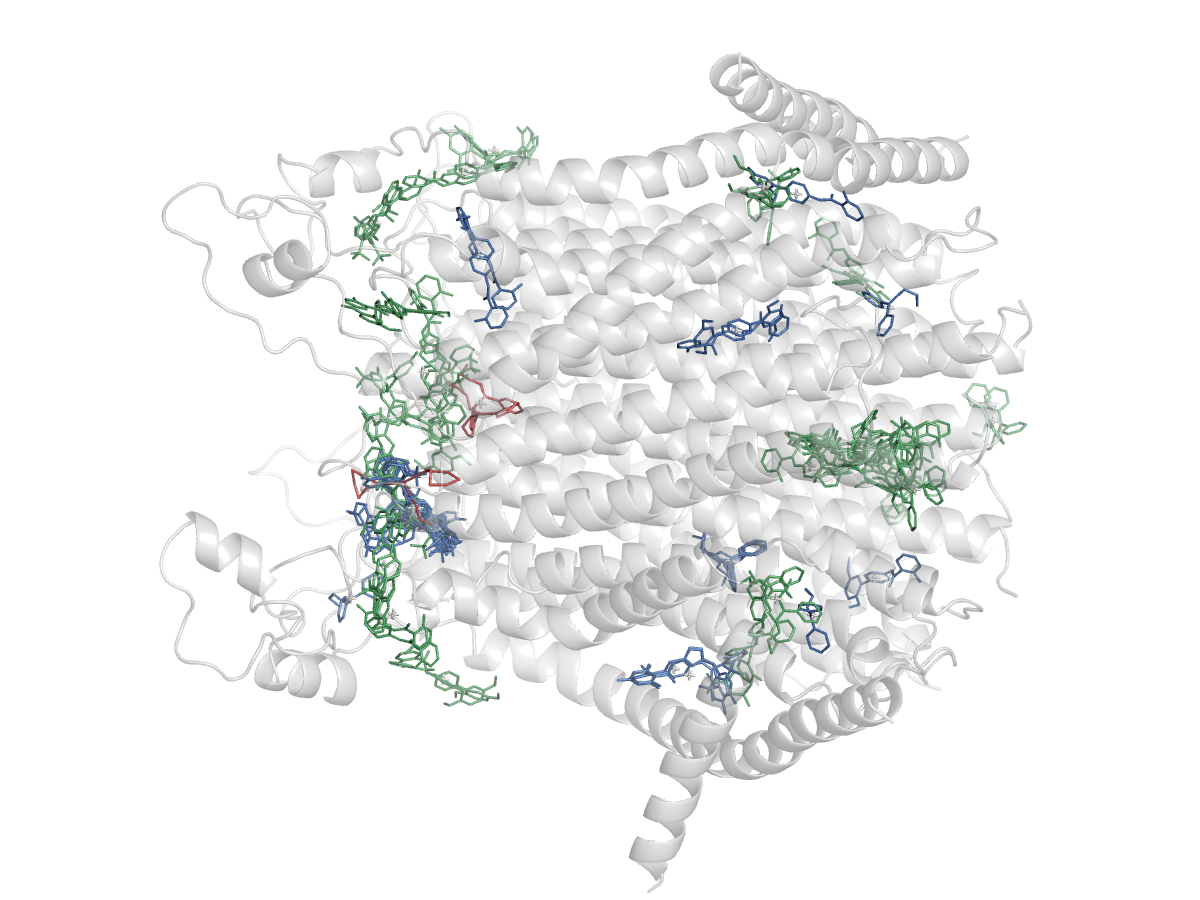

orai_jku__Orai1WT-MDSnap-Fr400__preview.png


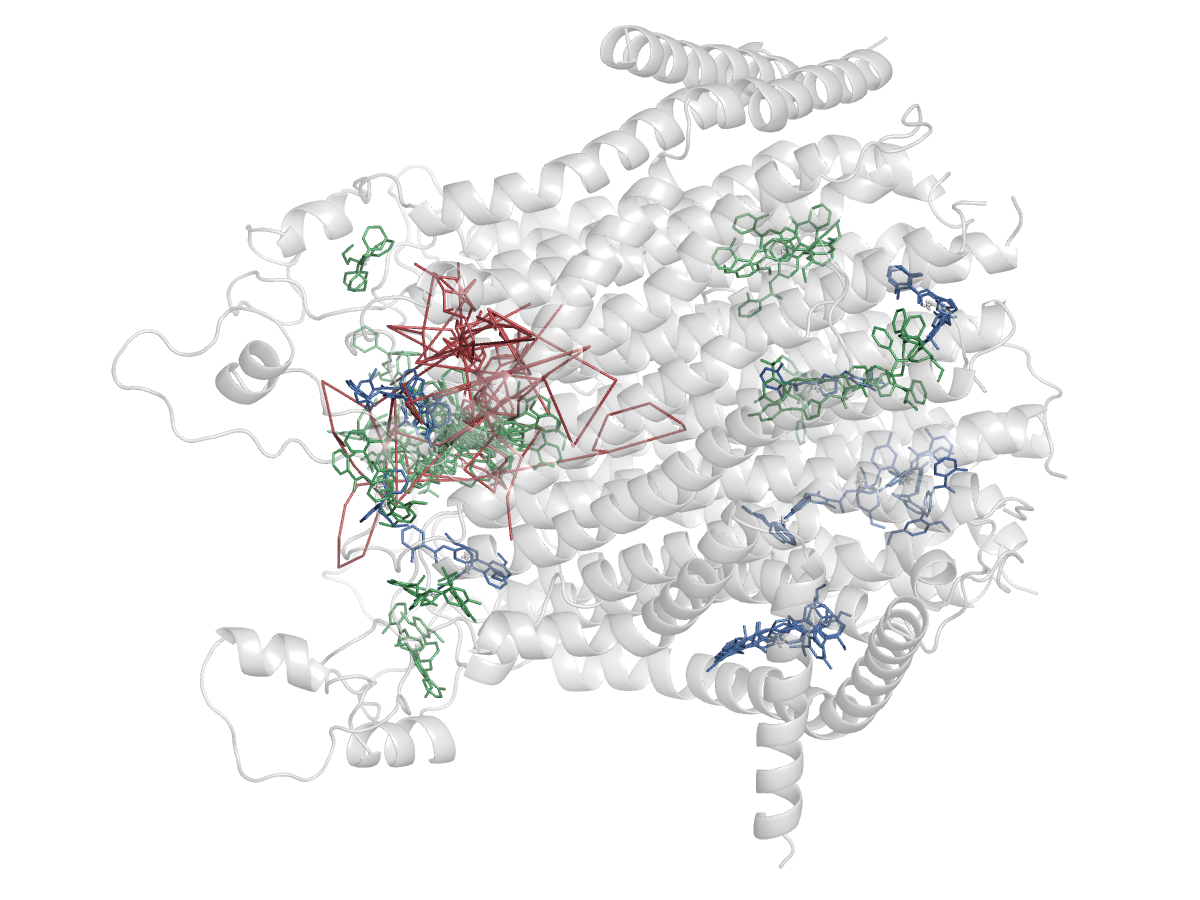

orai_jku__Orai1WT-MDSnap-Fr499__preview.png


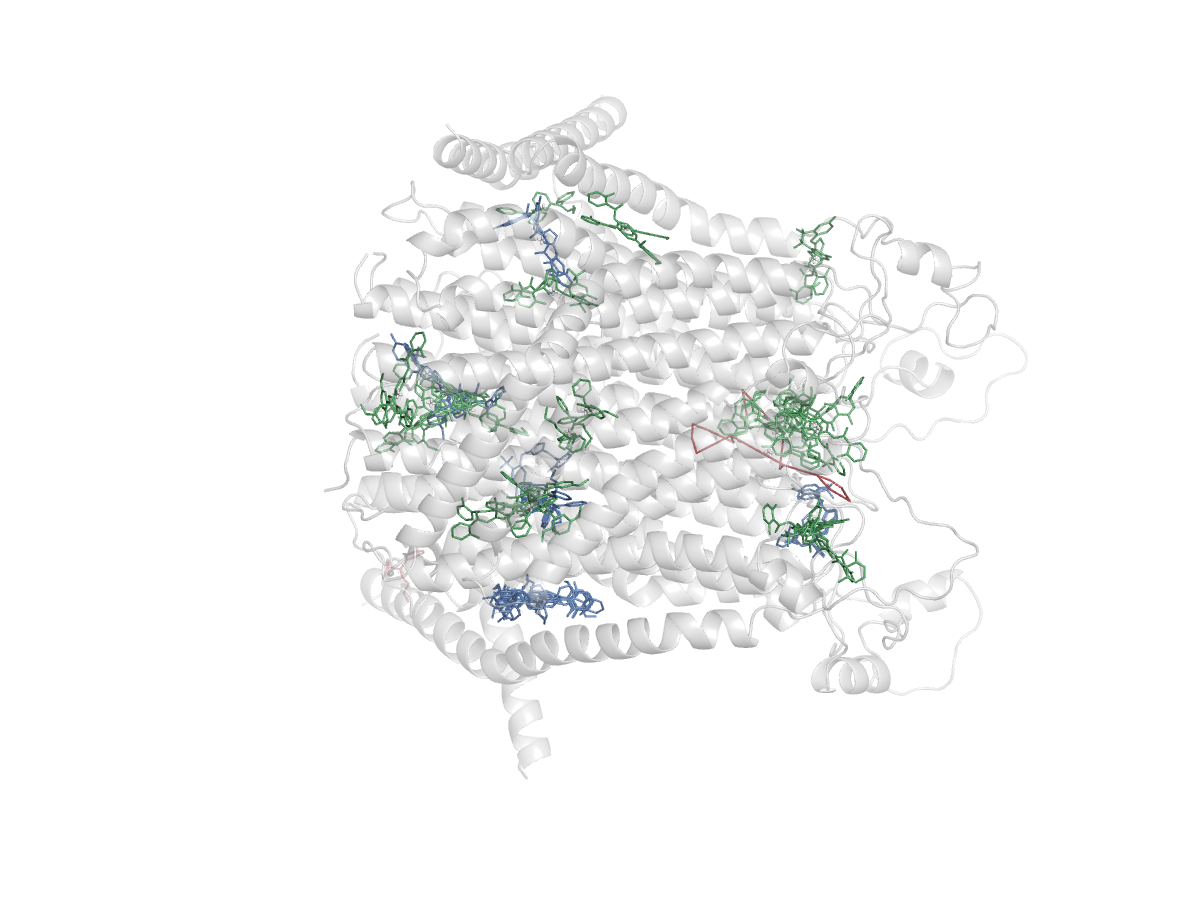

orai_jku__Orai1WT-START-Fr0__preview.png


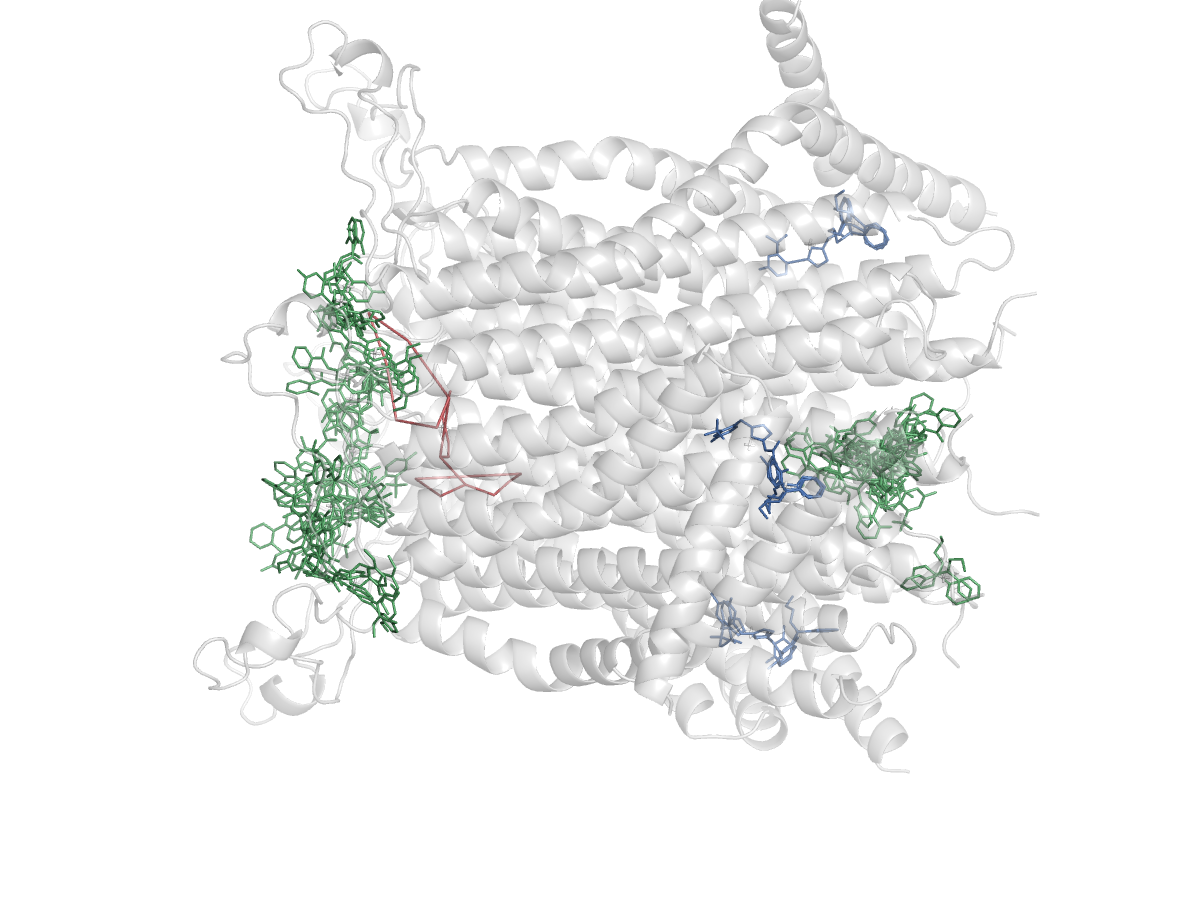

orai_benchmark__Orai1WT-START-Fr0__preview.png


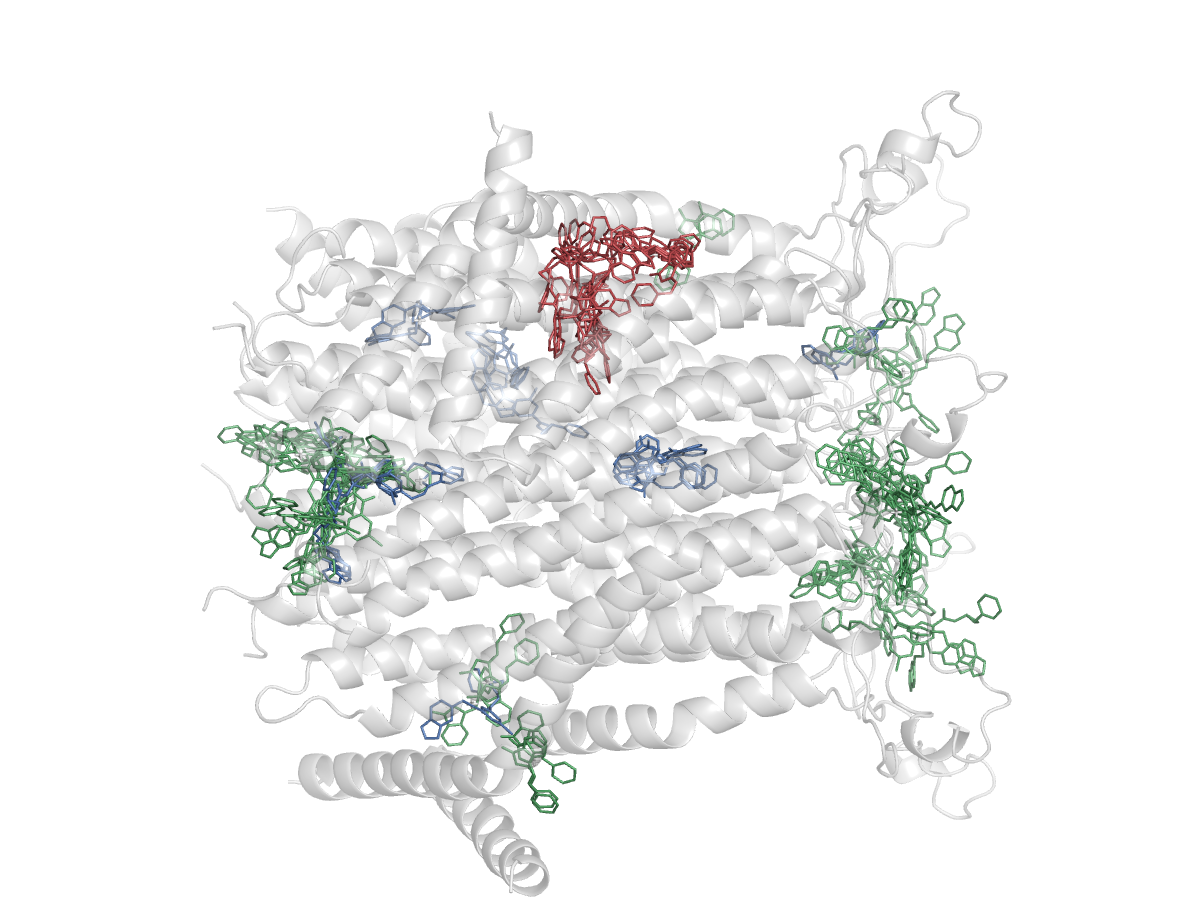


Open any scene interactively with, e.g.:
    pymol posebusters_results/orai_jku/pymol_scene/orai_jku__Orai1WT-START-Fr0__scene.pml
then type  by_tool / by_ligand / by_cluster  to recolour.


In [ ]:
import subprocess
from pathlib import Path
from IPython.display import Image, display

VINA_PY = "/home/manndo/anaconda3/envs/vina/bin/python"   # has PyMOL, for the preview render
SCENE   = "Scripts/Analysis/pymol_pose_cluster_scene.py"

# (per_pose.csv, receptor dir, out dir, extra args) for each dataset.
# JKU: all 3 ligands, every frame. Benchmark: one showcase frame + 2 ligands
# (change --frames / --ligands, or drop them to auto-pick the busiest ligands).
jobs = [
    ("Orai × JKU",
     ["--per-pose-csv", "posebusters_results/orai_jku/pose_clusters/per_pose.csv",
      "--out-dir", "posebusters_results/orai_jku/pymol_scene"]),
    ("Orai × Benchmark (showcase)",
     ["--per-pose-csv", "posebusters_results/orai_benchmark/pose_clusters/per_pose.csv",
      "--out-dir", "posebusters_results/orai_benchmark/pymol_scene",
      "--frames", "Orai1WT-START-Fr0", "--ligands", "5SAK_ZRY,5SB2_1K2"]),
]

for label, extra in jobs:
    print(f"=== PyMOL scenes: {label} ===")
    proc = subprocess.run([VINA_PY, SCENE, "--receptor-dir", "Data/Receptors",
                           "--render", *extra])
    if proc.returncode != 0:
        print(f"WARN {SCENE} exited with code {proc.returncode} - continuing notebook.")

# Show the by-tool preview PNGs the script ray-traced (one per scene).
for out in ("posebusters_results/orai_jku/pymol_scene",
            "posebusters_results/orai_benchmark/pymol_scene"):
    for png in sorted(Path(out).glob("*__preview.png")):
        print(png.name)
        display(Image(filename=str(png)))

print("\nOpen any scene interactively with, e.g.:")
print("    pymol posebusters_results/orai_jku/pymol_scene/"
      "orai_jku__Orai1WT-START-Fr0__scene.pml")
print("then type  by_tool / by_ligand / by_cluster  to recolour.")


## Orai × PoseBuster Benchmark Ligands || Consensus binding-region analysis

Pools the **PB-valid** Orai cross-docked poses (AutoDock + DiffDock + EquiBind)
across **all** benchmark ligands and asks **where on the channel they cluster**, via
`Scripts/Analysis/orai_ligand_region_consensus.py`. The four Orai MD frames are
different conformations in **different coordinate systems**, so a binding *region*
is defined not by a 3D centroid but by the **set of contacted receptor residues**
(any ligand heavy atom ≤ 4 Å) — identical residue numbering across the frames makes
this comparable across frames, methods and ligands with no alignment (the 6
symmetric subunits are folded onto residue number).

It answers two questions:
- **(a) across all ligands** — which residue-defined regions recur for *most*
  ligands regardless of method or frame (consensus hotspots; e.g. the pore region);
- **(b) across ligand types** — clustering the ligands by the physicochemical
  descriptors / PCA from `PoseBusters_DataSet_Analysis.ipynb` (via the shared
  `ligand_descriptors.py`), does a given **chemo-type** dock in a consistent region
  across **all methods and all frames**?

Outputs → `posebusters_results/orai_benchmark/region_consensus/` (per-pose region
assignments, region summary, ligand-cluster × region matrix, per-ligand
consistency, 4 figures). Contact fingerprints are cached — re-runs are fast; pass
`--force` to recompute. Runs in the `vina` env.

In [ ]:
import subprocess
from pathlib import Path
from IPython.display import Image, display

VINA_PY = "/home/manndo/anaconda3/envs/vina/bin/python"   # rdkit/sklearn/scipy/matplotlib in the vina env

cmd = ["Scripts/Analysis/orai_ligand_region_consensus.py",
       "--pb-csv", "posebusters_results/orai_benchmark/dock/posebusters_filtered_results.csv",
       "--out-dir", "posebusters_results/orai_benchmark/region_consensus"]
print(f"=== {Path(cmd[0]).name} (Orai \u00d7 Benchmark) ===")
proc = subprocess.run([VINA_PY, *cmd])
if proc.returncode != 0:
    print(f"WARN {cmd[0]} exited with code {proc.returncode} - continuing notebook.")

out = Path("posebusters_results/orai_benchmark/region_consensus")
for png in ("01_region_overview.png", "02_ligand_chemo_clusters.png",
            "03_ligandcluster_region_consensus.png", "04_ligand_consistency.png"):
    p = out / png
    if p.exists():
        display(Image(filename=str(p)))

## 3D View

In [ ]:
import py3Dmol
from pathlib import Path

D = Path("posebusters_results/orai_benchmark/region_consensus")
frame = "Orai1WT-START-Fr0"                       # pick any snapshot
receptor = Path("Data/Receptors") / f"{frame}.pdb"
TOOL_HEX = {"A": "0x1f77b4", "D": "0xff7f0e", "E": "0x2ca02c"}  # chain -> tool

v = py3Dmol.view(width=900, height=650)
v.addModel(receptor.read_text(), "pdb")                                   # model 0
v.setStyle({"model": 0}, {"cartoon": {"color": "yellow", "opacity": 0.7}})
v.addModel((D / f"poses_{frame}.pdb").read_text(), "pdb")                 # model 1
for ch, hx in TOOL_HEX.items():                       # colour poses BY TOOL (chain)
    v.setStyle({"model": 1, "chain": ch}, {"sphere": {"radius": 0.4, "color": hx}})
v.zoomTo({"model": 1})
v.show()


In [ ]:
import pandas as pd, plotly.graph_objects as go
from plotly.subplots import make_subplots

D = "posebusters_results/orai_benchmark/region_consensus"
frame = "Orai1WT-MDSnap-Fr300"
df = (pd.read_csv(f"{D}/pose_region_assignments.csv")
        .merge(pd.read_csv(f"{D}/pose_centroids.csv"), on="pose_file", how="left"))
df = df[(df.frame == frame) & (df.region >= 0) & df.cx.notna()]

TOOL_LABEL  = {"autodock": "AutoDock Vina", "diffdock": "DiffDock", "equibind_guided": "EquiBind"}
TOOL_COLOR  = {"autodock": "#1f77b4", "diffdock": "#ff7f0e", "equibind_guided": "#2ca02c"}
TOOL_SYMBOL = {"autodock": "circle", "diffdock": "diamond", "equibind_guided": "square"}
TAB10 = ["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd","#8c564b","#e377c2","#7f7f7f","#bcbd22","#17becf"]
regs = sorted(df.region.unique()); REG_COLOR = {r: TAB10[i % 10] for i, r in enumerate(regs)}

fig = make_subplots(rows=1, cols=2, column_widths=[0.62, 0.38],
                    specs=[[{"type": "scatter3d"}, {"type": "xy"}]],
                    subplot_titles=("pose centroids (colour=region, symbol=tool)",
                                    "per-cluster tool composition"))
for r in regs:
    for m, sym in TOOL_SYMBOL.items():
        s = df[(df.region == r) & (df.method == m)]
        if s.empty: continue
        fig.add_trace(go.Scatter3d(
            x=s.cx, y=s.cy, z=s.cz, mode="markers", name=f"R{r+1} · {TOOL_LABEL[m]}",
            marker=dict(size=4, color=REG_COLOR[r], symbol=sym, line=dict(width=0.5, color="black")),
            customdata=s[["ligand"]].assign(tool=TOOL_LABEL[m], region=f"R{r+1}"),
            hovertemplate="%{customdata[0]}<br>%{customdata[1]}<br>%{customdata[2]}<extra></extra>"),
            row=1, col=1)
ct = pd.crosstab(df.region, df.method).reindex(index=regs, fill_value=0)
for m in [c for c in TOOL_LABEL if c in ct.columns]:
    fig.add_trace(go.Bar(x=[f"R{r+1}" for r in regs], y=ct[m].values,
                         name=TOOL_LABEL[m], marker_color=TOOL_COLOR[m], showlegend=False),
                  row=1, col=2)
fig.update_layout(barmode="stack", height=620, width=1200,
                  title=f"Orai snapshot {frame}: clustered PB-valid poses by tool")
fig

## Docking difficulty — ligand vs receptor drivers, and pose ranking

Explains *which complexes* each tool docks well or badly, from the ligand side, the receptor/pocket side, and by pose rank. Success = the tool's oracle (best) RMSD-to-crystal per complex; best-60 vs worst-60 compared with Cliff's δ. Outputs land in `PoseBusters_Benchmark_Analysis/{ligand_difficulty,receptor_difficulty,rank_success}/`.

In [ ]:
# Ligand side: which LIGAND properties separate best- vs worst-docked complexes,
# per tool. Writes CSV + Cliff's-delta heatmap to
# PoseBusters_Benchmark_Analysis/ligand_difficulty/ . Use --n to resize the groups.
%run Scripts/Analysis/ligand_docking_difficulty.py --diffdock-variant gnina

In [ ]:
# Receptor side: which RECEPTOR / POCKET properties separate best- vs worst-docked
# complexes, per tool (protein size, # candidate pockets, volume, druggability). This
# is the receptor explanation of the rankings, e.g. why DiffDock's difficulty is
# protein/pocket-driven rather than ligand-driven. Writes to
# PoseBusters_Benchmark_Analysis/receptor_difficulty/ .
%run Scripts/Analysis/receptor_docking_difficulty.py --diffdock-variant gnina

In [ ]:
# Pose ranking: oracle vs top-n success, how the per-pose hit rate falls with rank,
# and how both depend on ligand attributes (AutoDock & DiffDock; EquiBind poses are
# unranked). Writes CSVs + two figures to PoseBusters_Benchmark_Analysis/rank_success/ .
%run Scripts/Analysis/rank_success_analysis.py